In [1]:
from dask.distributed import Client

client = Client("tcp://127.0.0.1:39995")
client

<Client: 'tcp://127.0.0.1:39995' processes=8 threads=32, memory=503.70 GiB>

In [2]:
import numpy as np
import xarray as xr
import pandas as pd
from xhistogram.xarray import histogram as xhist
from xgcm.grid import Grid
import gsw

import rioxarray
import seaborn as sns
import xrft

import glob

import gcm_filters

import os.path as op

from scipy.interpolate import griddata, interpn

import warnings
warnings.filterwarnings("ignore")

# from xeofs.models import EOF
from pydmd import DMD, BOPDMD, MrDMD
from pydmd.mrcosts import mrCOSTS
from pydmd.preprocessing import hankel_preprocessing
from pydmd.plotter import plot_eigs, plot_summary

from matplotlib import ticker
import matplotlib.colors as clr
import matplotlib.pyplot as plt
plt.rcParams['pcolor.shading'] = 'auto'
%matplotlib inline

In [3]:
grav = 9.807
fscale = np.ceil(14/np.sqrt(12)/2)
meth = "linear"
ddir = "/storage/tartar/takaya/swot/"

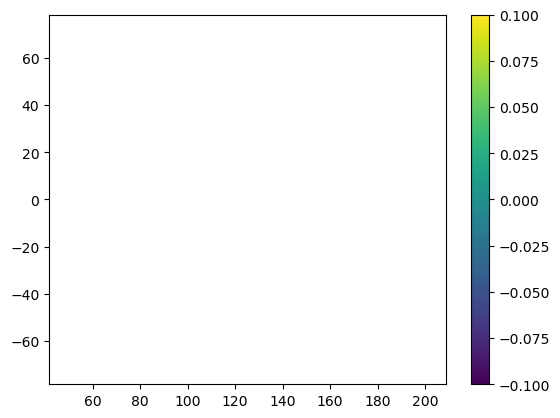

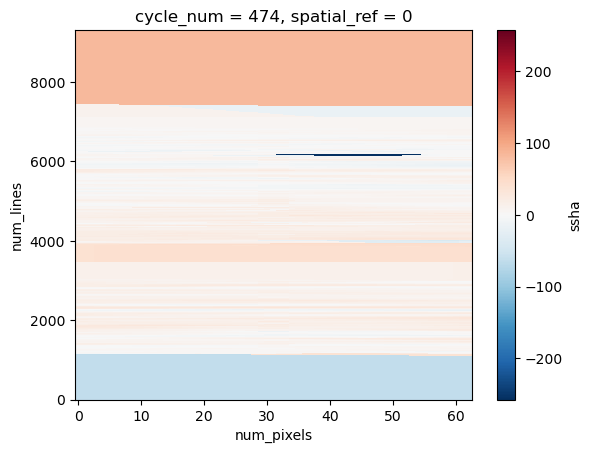

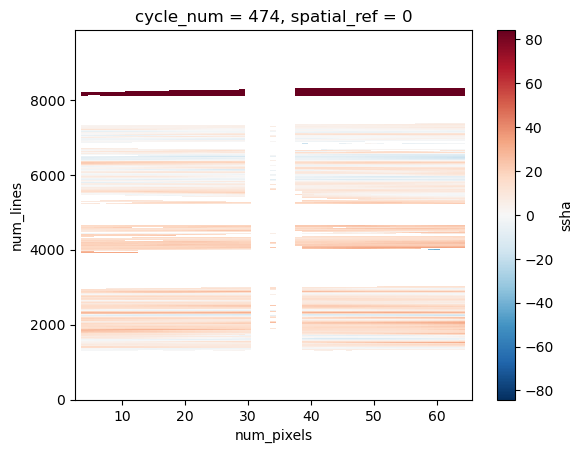

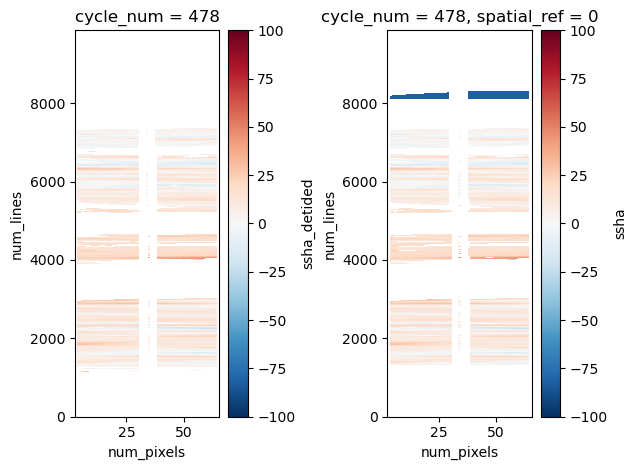

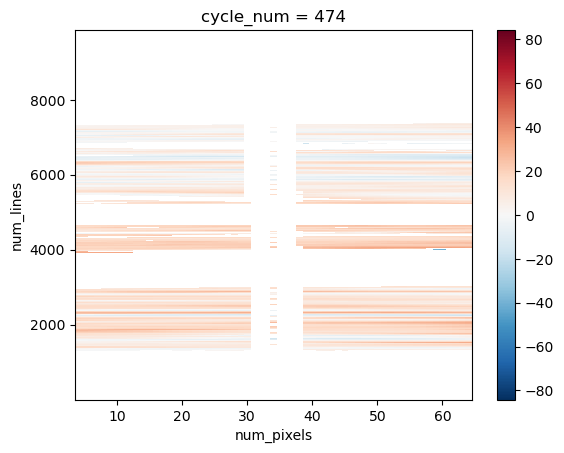

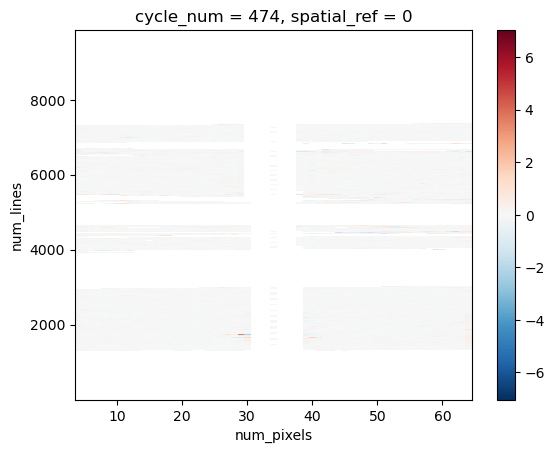

iiiiiiiiiiii
iiPass 021!!
!!!!!!!!!!!!


In [16]:
for ipass in range(21,22):
    ds = xr.open_zarr(op.join(ddir,"SWOT_no_IT/HYCOM/CalVal_pass%03d_v2.0.1.zarr"
                              % ipass))
    ds.coords["num_lines"] = ("num_lines",range(len(ds.num_lines)))
    ds.coords["num_pixels"] = ("num_pixels",range(len(ds.num_pixels)))

    fig, ax = plt.subplots()
    im = ax.pcolor(ds.longitude, ds.latitude,
              ds.ssha_detided.isel(cycle_num=1), 
              rasterized=True
             )
    fig.colorbar(im)
    plt.show()

    inp = 3
    maskn = xr.DataArray(ds.latitude.where(ds.latitude>5.).to_masked_array().mask,
                         dims=ds.latitude.dims,
                         coords=ds.latitude.coords
                        )
    masks = xr.DataArray(ds.latitude.where(ds.latitude<-5.).to_masked_array().mask,
                         dims=ds.latitude.dims,
                         coords=ds.latitude.coords
                        )
    dsns = ds.where(~maskn,drop=True)
    dsns = xr.concat([dsns, ds.where(~masks,drop=True)
                     ], "num_lines"
                    ).sortby("num_lines")

    maskns = xr.DataArray(dsns.ssha_detided.to_masked_array().mask.mean(axis=0), 
                          dims=dsns.ssha_detided.isel(cycle_num=0).dims, 
                          coords=dsns.ssha_detided.isel(cycle_num=0).coords
                         )
    mm = xr.DataArray(maskns.where(maskns<.5
                                  ).to_masked_array().mask,
                      dims=dsns.ssha_detided.isel(cycle_num=0).dims, 
                      coords=dsns.ssha_detided.isel(cycle_num=0).coords
                     ).isel(num_pixels=slice(inp,-inp))

    r_ref = (~mm).sum() / np.prod(mm.shape)

    ic = 0
    for cc in dsns.cycle_num:
        
        ssha = dsns.ssha_detided.sel(cycle_num=cc
                                    ).isel(num_pixels=slice(inp,-inp))
        
        array = ssha.to_masked_array()
        mask = ~array.mask
        ratio = mask.sum() / np.prod(mask.shape)
        if ic == 0:
            R = xr.DataArray(np.array([ratio]), 
                             dims='cycle_num', 
                             coords={'cycle_num':np.array([cc.values,])}
                            )
        else:
            R = xr.concat([R, xr.DataArray(np.array([ratio]), 
                                   dims='cycle_num', 
                                   coords={'cycle_num':np.array([cc.values,])}
                                          )
                          ], 'cycle_num')
        if ratio > .7*r_ref:
            if ic == 0:
                H = ssha
            else:
                if "H" in locals():
                    H = xr.concat([H, ssha], 'cycle_num')
                else:
                    print("Creating H.")
                    H = ssha
            ic += 1
        # else:
            # ssha.plot(rasterized=True)
            # plt.show()
        del ssha, mask, array
    
    H.coords["cycle_num"] = ("cycle_num",
                             R.where(R>0.7*r_ref, drop=True).cycle_num.data
                            )

    dsH = H.to_dataset(name="ssha").swap_dims({'num_pixels':'x', 
                                               'num_lines':'y'}
                                             ).reset_coords(drop=True)
    dsH.coords["y"] = ("y",range(len(dsH.y)))
    dsH.coords["x"] = ("x",range(len(dsH.x)))
    if not dsH.rio.crs:
        dsH = dsH.rio.write_crs("EPSG:4326")
    if dsH.ssha.rio.nodata is None:
        dsH["ssha"] = dsH.ssha.rio.write_nodata(np.nan)
    _H_exterp = dsH.rio.interpolate_na().swap_dims({'x':'num_pixels', 
                                                    'y':'num_lines'}
                                                  ).ssha
    _H_exterp.isel(cycle_num=0).plot(rasterized=True)
    plt.show()

    del H
    dsH.close()

    H_exterp = _H_exterp.where(mm!=1)
    H_exterp.isel(cycle_num=0).plot(rasterized=True)

    fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2)
    fig.set_tight_layout(True)
    dsns.ssha_detided.sel(cycle_num=478
                         ).isel(num_pixels=slice(inp,-inp)
                               ).plot(ax=ax1, rasterized=True, vmax=1e2)
    H_exterp.sel(cycle_num=478).plot(ax=ax2, rasterized=True, vmax=1e2)
    plt.show()

    wet_mask = xr.DataArray(mm.where(mm!=0).to_masked_array().mask.astype(np.float64),
                            dims=mm.dims, coords=mm.coords
                           ).reset_coords(drop=True)
    
    regular_filter = gcm_filters.Filter(
        filter_scale=fscale,
        dx_min=1,
        filter_shape=gcm_filters.FilterShape.GAUSSIAN,
        grid_type=gcm_filters.GridType.REGULAR_WITH_LAND,
        grid_vars={'wet_mask': wet_mask,
        }
    )
    
    _sshm = regular_filter.apply(_H_exterp.chunk({'num_lines':-1,'num_pixels':-1}), 
                             dims=['num_lines','num_pixels']
                            ).reset_coords(drop=True).where(mm!=1).chunk({"cycle_num":1,
                                                             "num_lines":-1,"num_pixels":-1}
                                                           ).isel(num_pixels=slice(1,-1),
                                                                  num_lines=slice(1,-1)
                                                                 )
    if ipass == 21:
        _sshm[dict(num_lines=range(7499,len(_sshm.num_lines)))] = np.nan
        
    _sshm.isel(cycle_num=0).plot()
    plt.show()
    (_H_exterp.isel(num_pixels=slice(1,-1),num_lines=slice(1,-1))
     - _sshm).isel(cycle_num=0).plot()
    plt.show()
    
    dsave = _sshm.to_dataset(name="ssha"
                            ).to_zarr(op.join(ddir,
                          'CalVal/Pass%03d/ssha_rawgrid_%02dpoints.zarr' 
                          % (ipass,int(fscale))
                                             ), mode='w'
                                     )
    print("iiiiiiiiiiii")
    print("iiPass %03d!!" % ipass)
    print("!!!!!!!!!!!!")

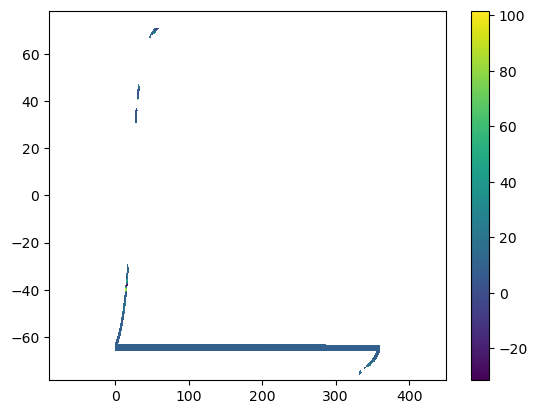

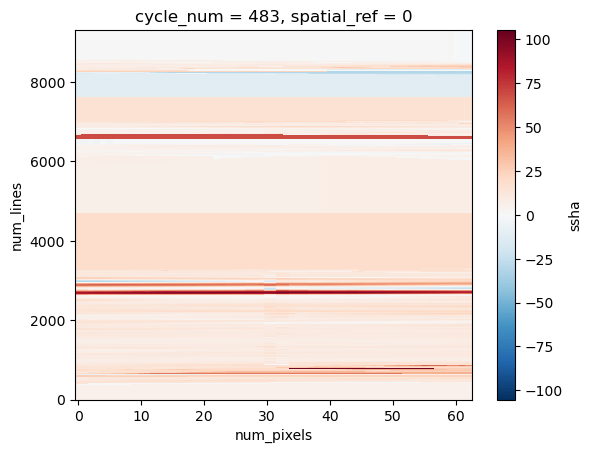

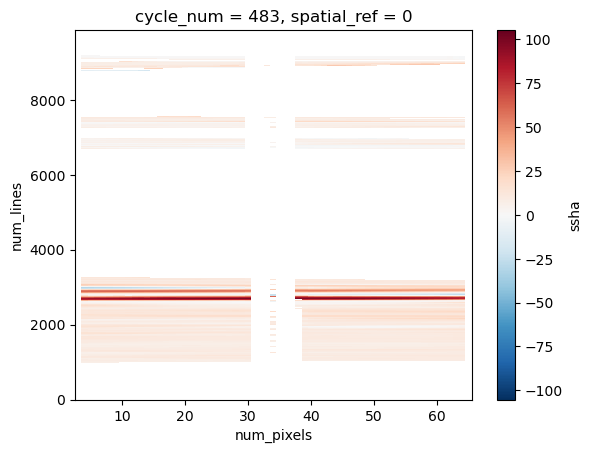

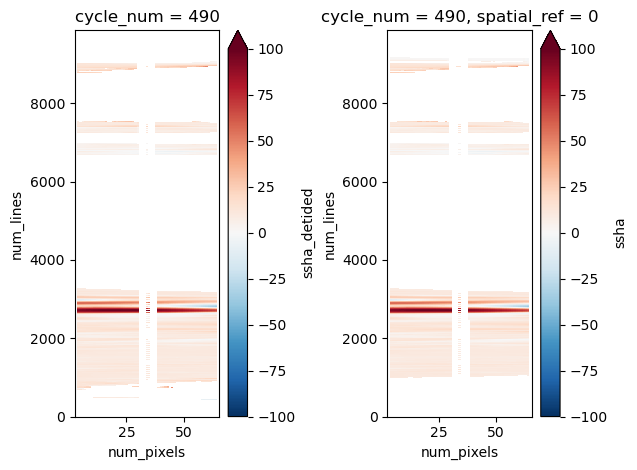

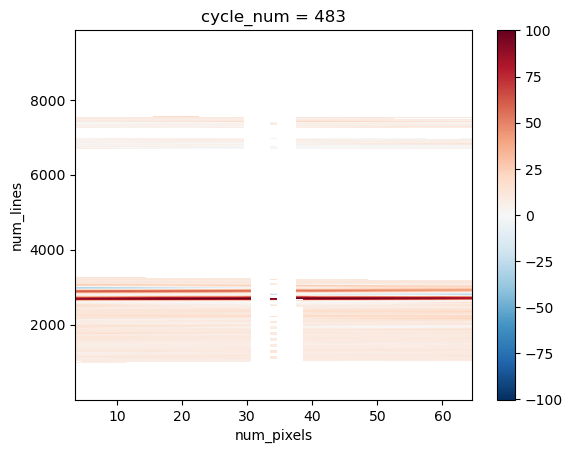

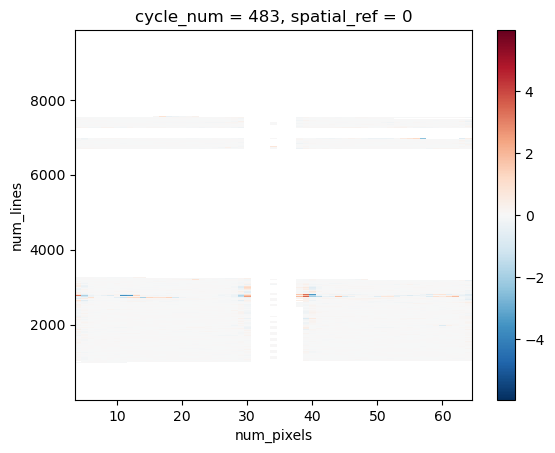

iiiiiiiiiiii
iiPass 001!!
!!!!!!!!!!!!


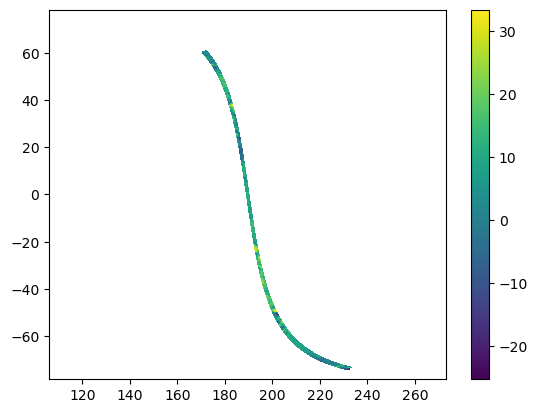

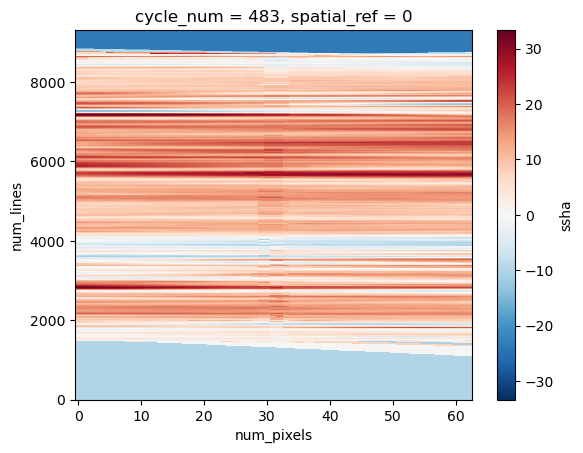

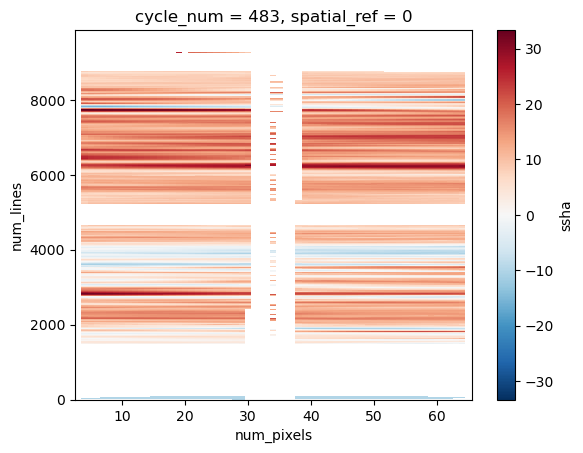

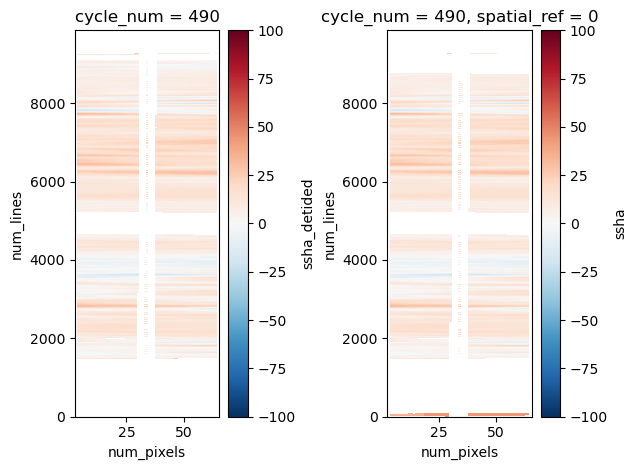

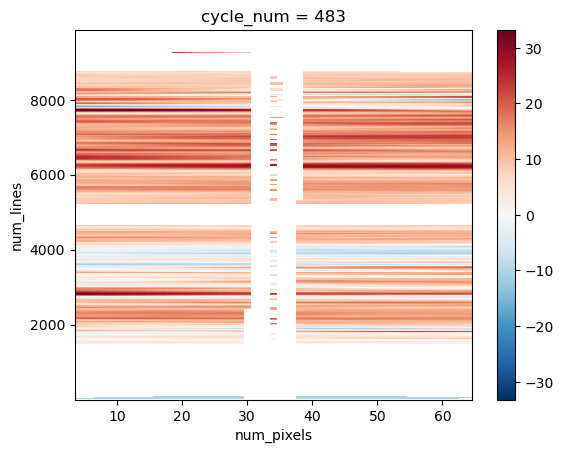

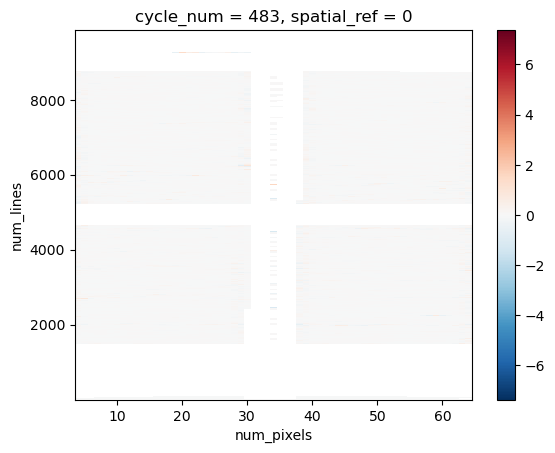

iiiiiiiiiiii
iiPass 002!!
!!!!!!!!!!!!


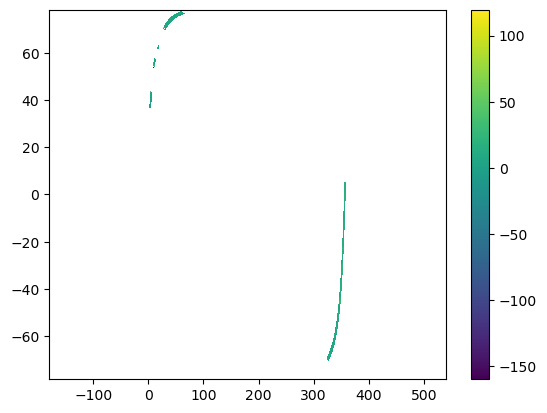

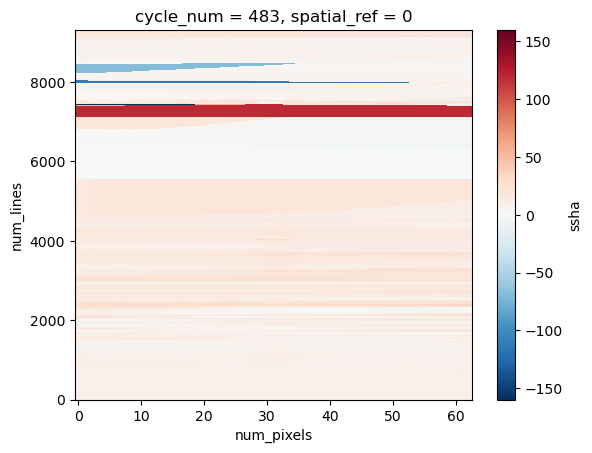

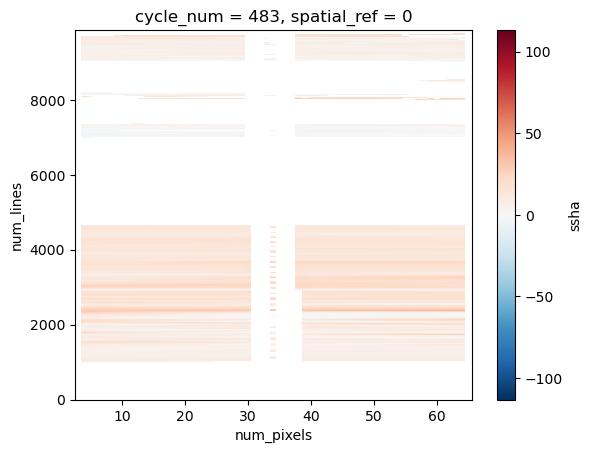

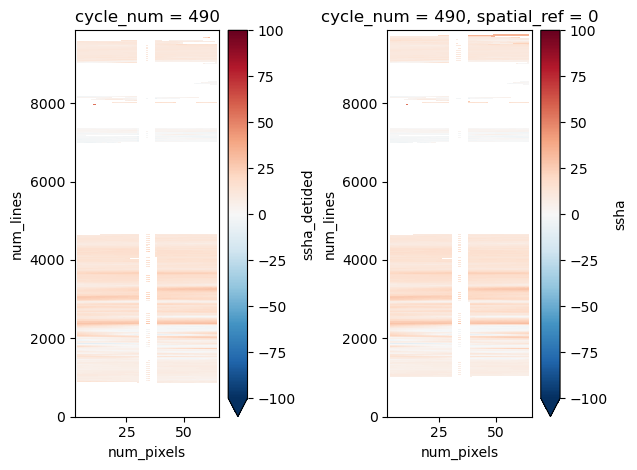

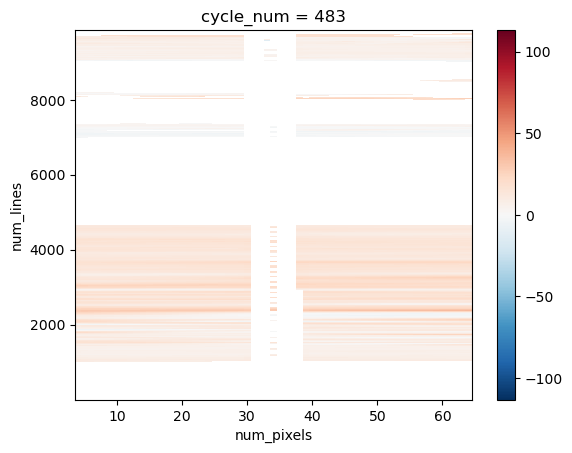

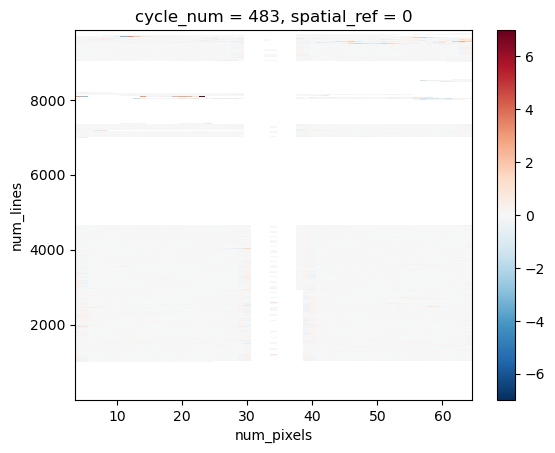

iiiiiiiiiiii
iiPass 003!!
!!!!!!!!!!!!


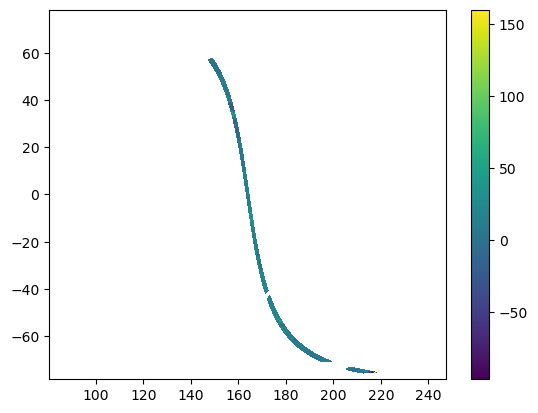

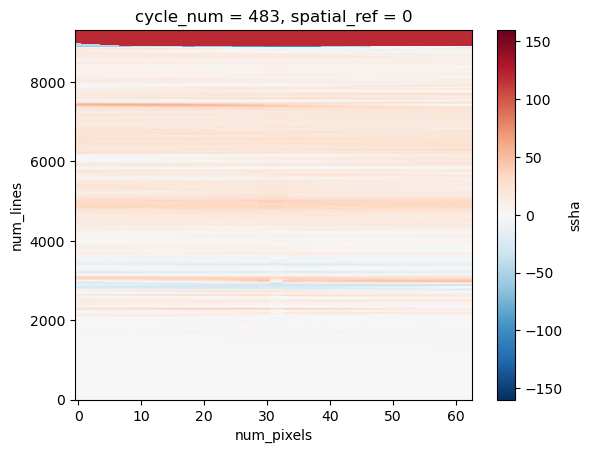

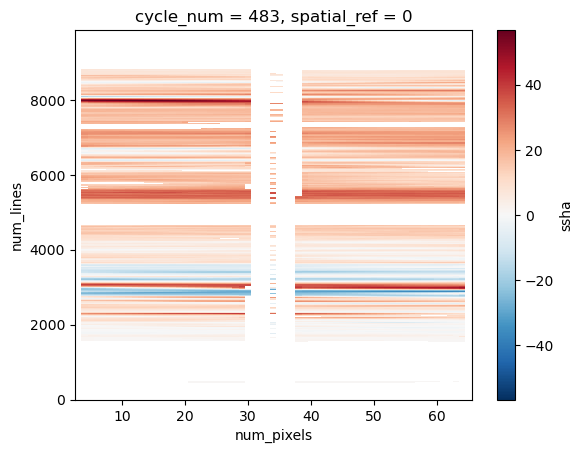

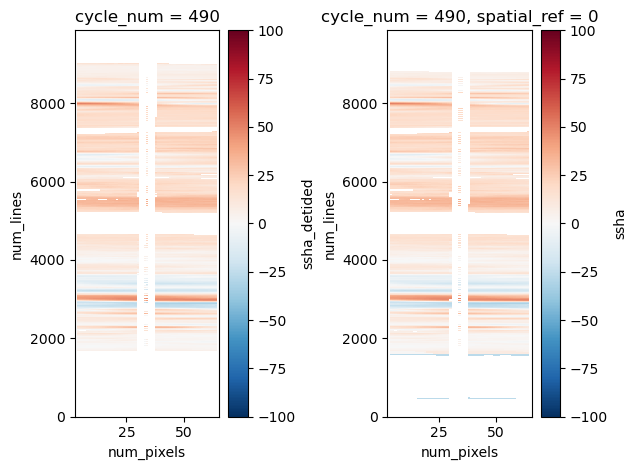

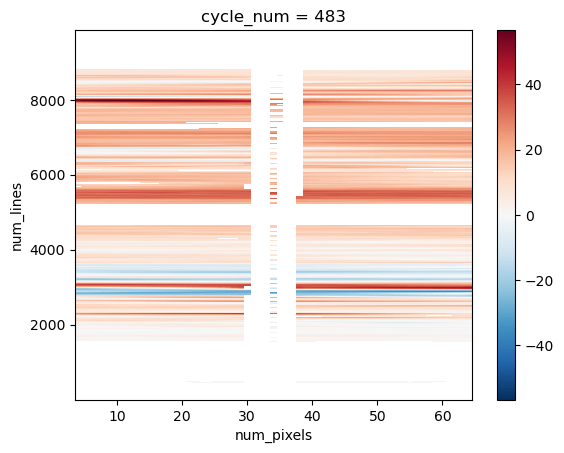

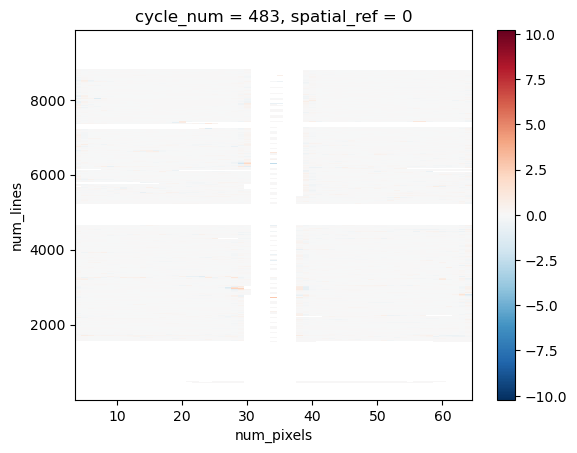

iiiiiiiiiiii
iiPass 004!!
!!!!!!!!!!!!


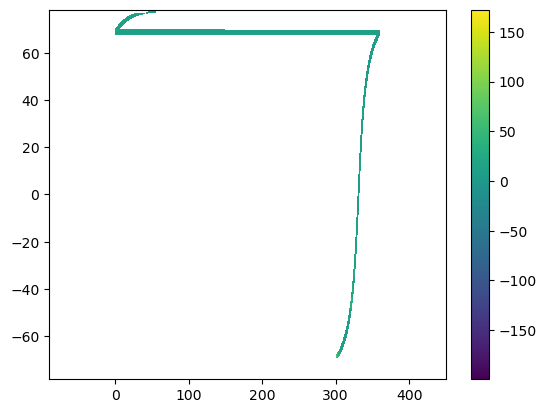

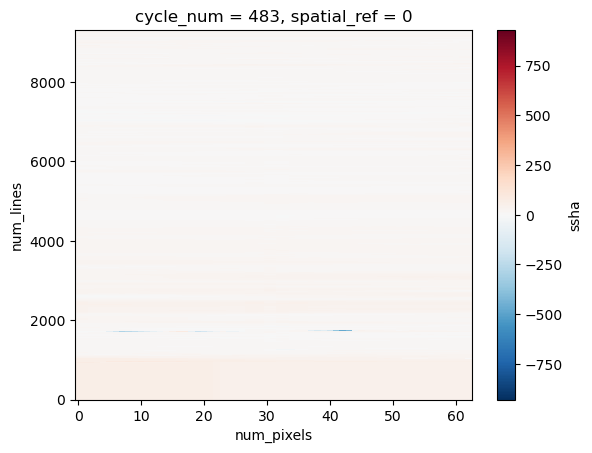

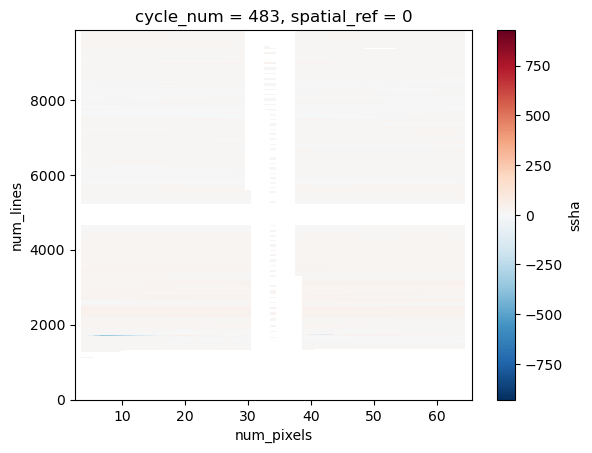

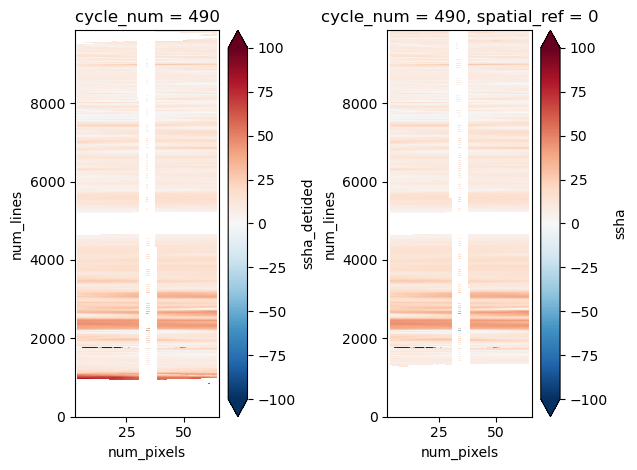

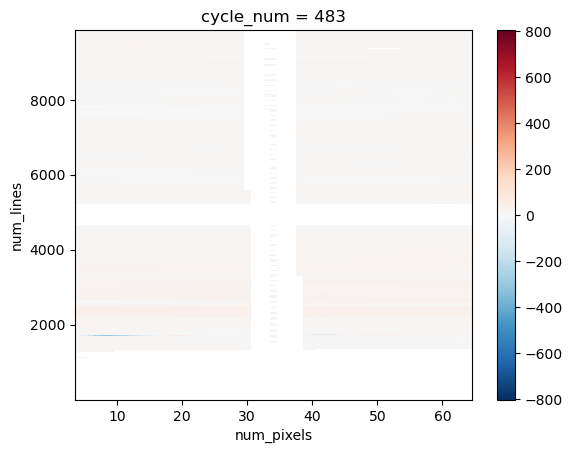

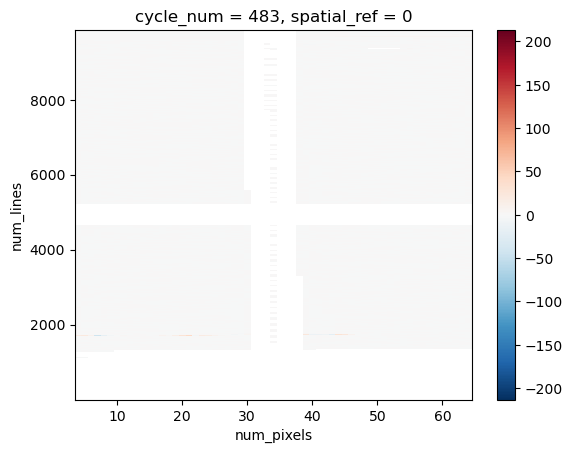

iiiiiiiiiiii
iiPass 005!!
!!!!!!!!!!!!


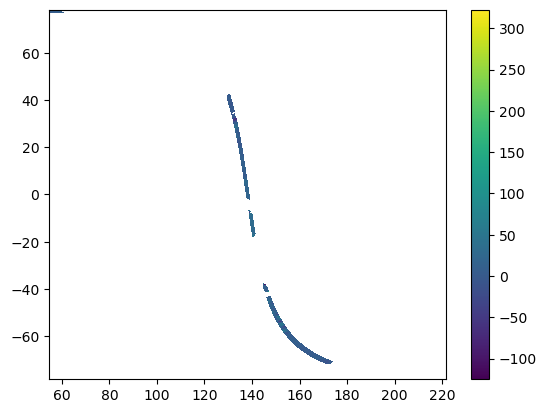

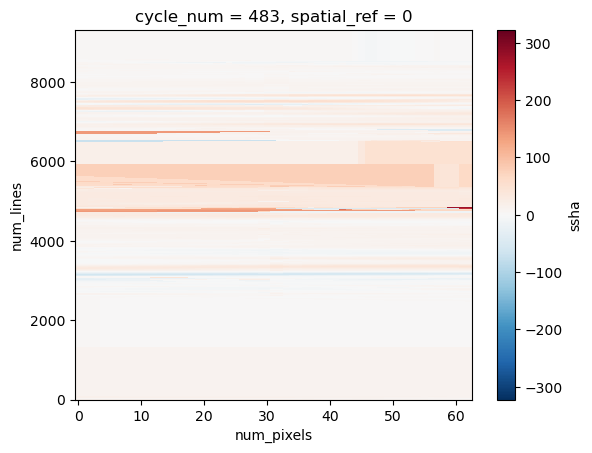

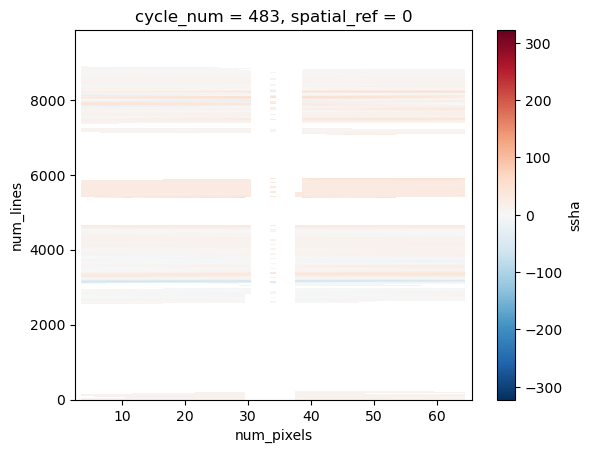

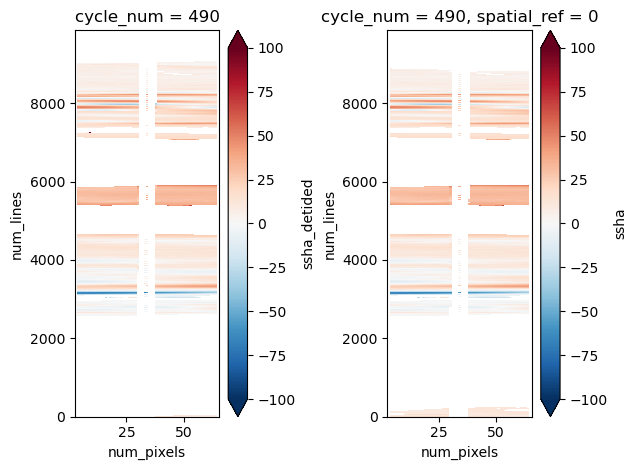

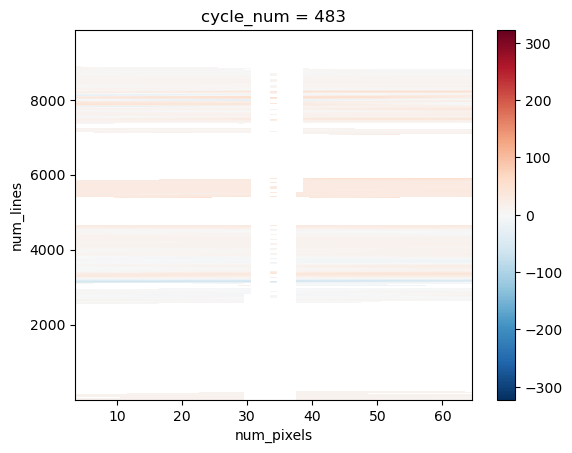

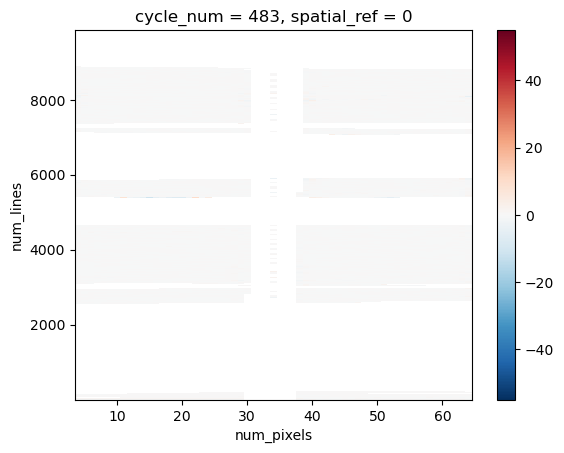

iiiiiiiiiiii
iiPass 006!!
!!!!!!!!!!!!


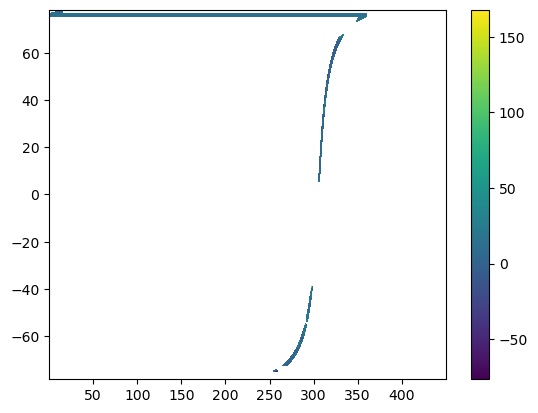

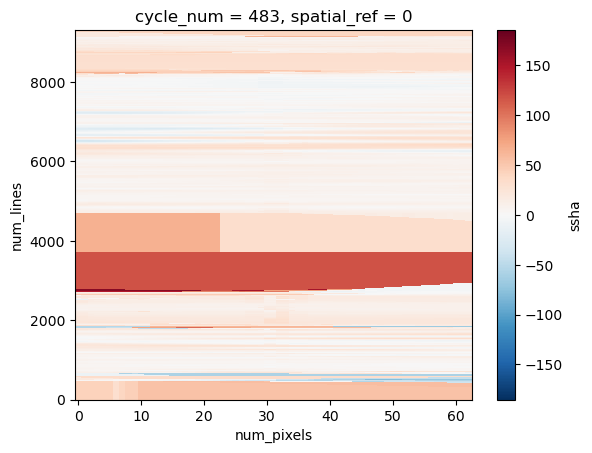

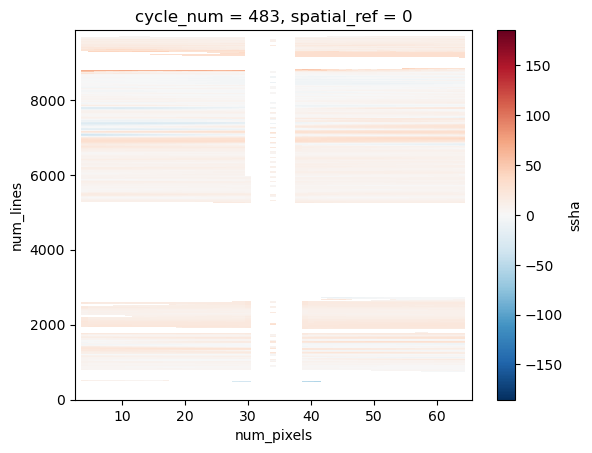

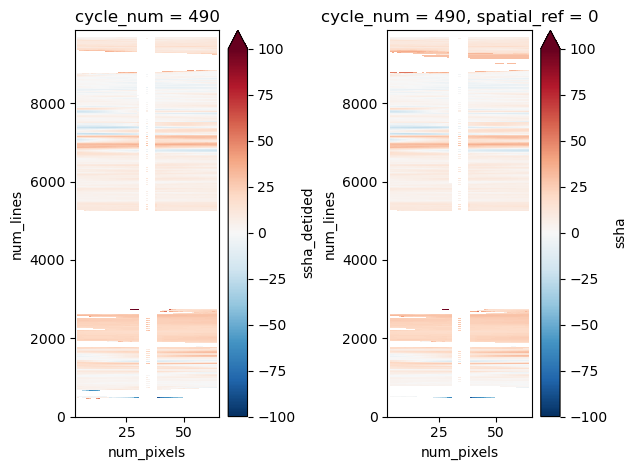

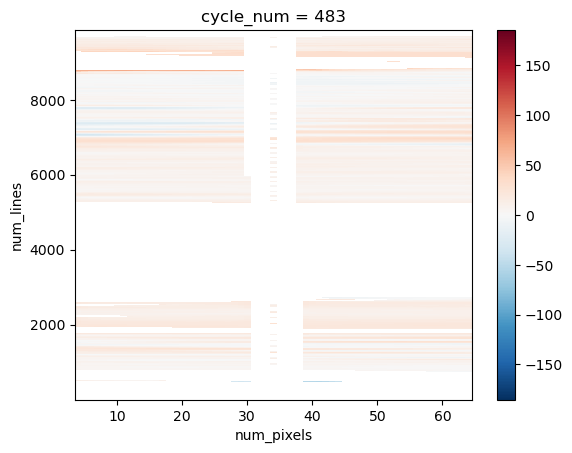

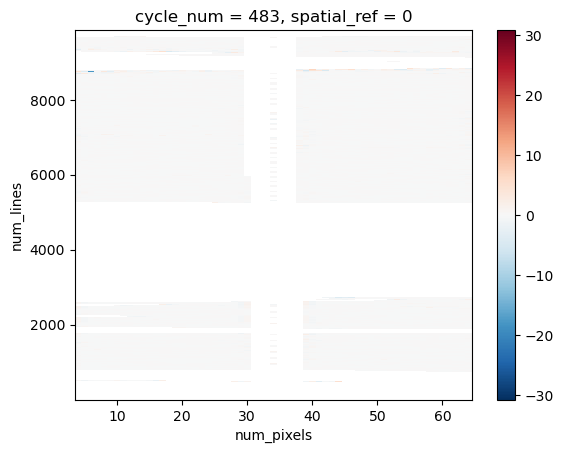

iiiiiiiiiiii
iiPass 007!!
!!!!!!!!!!!!


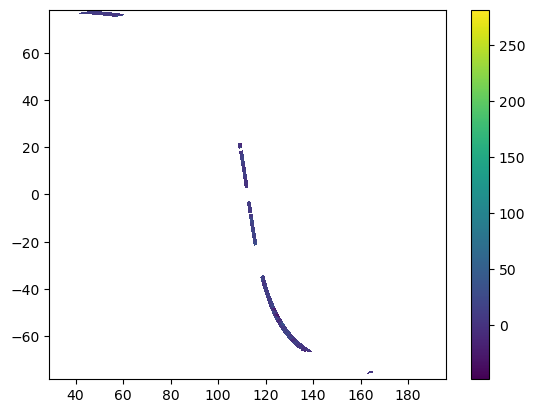

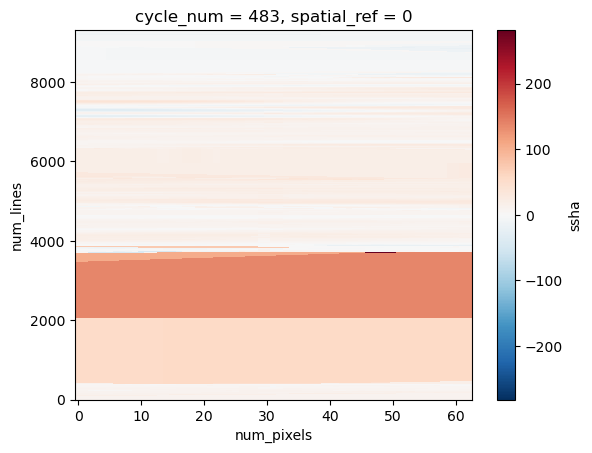

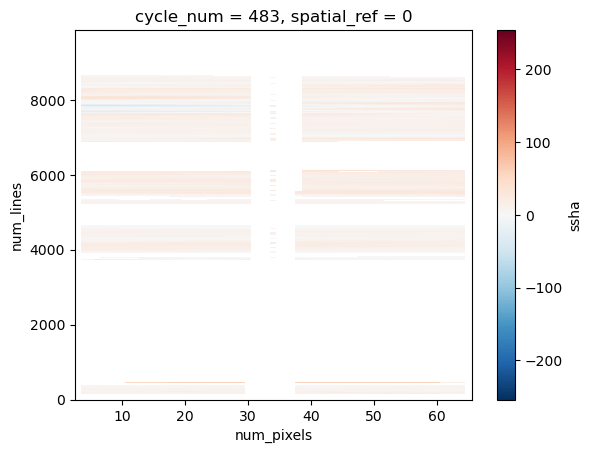

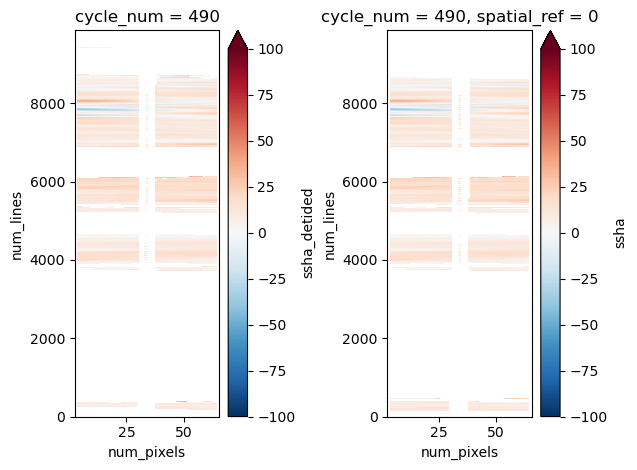

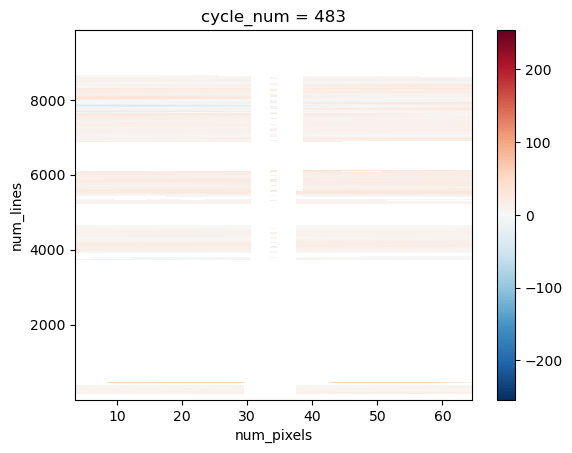

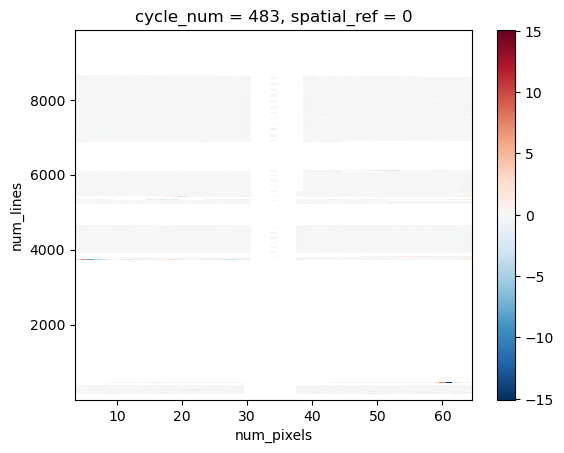

iiiiiiiiiiii
iiPass 008!!
!!!!!!!!!!!!


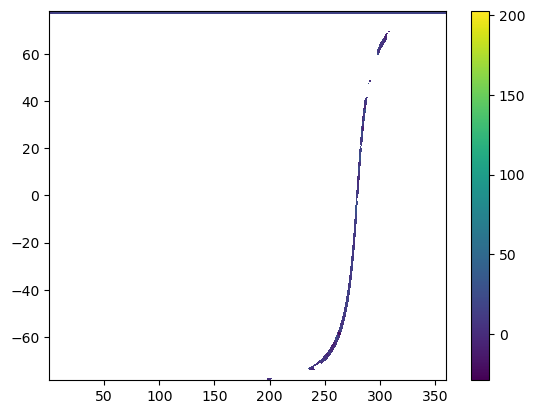

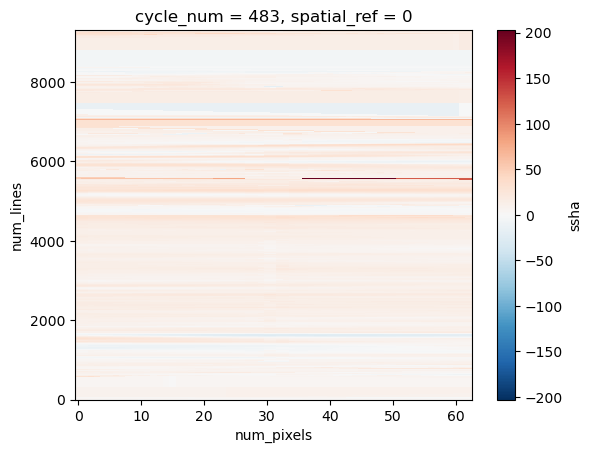

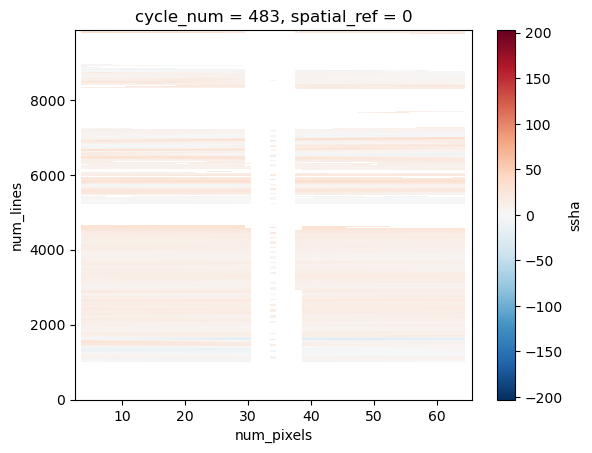

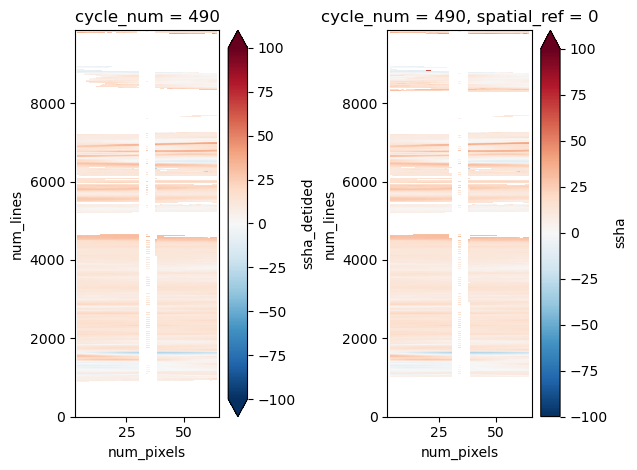

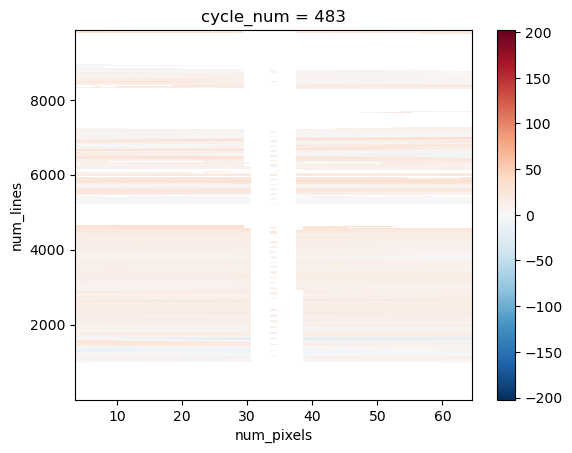

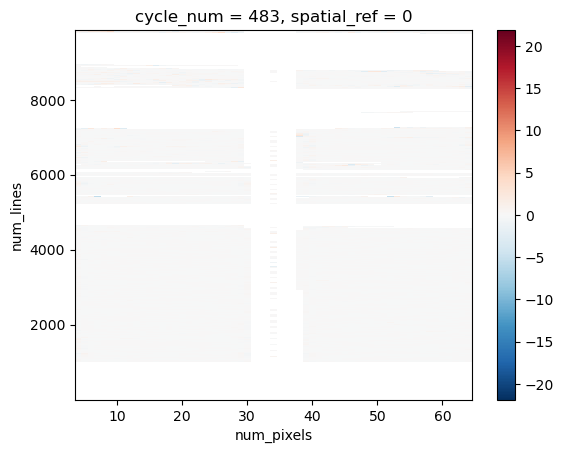

iiiiiiiiiiii
iiPass 009!!
!!!!!!!!!!!!


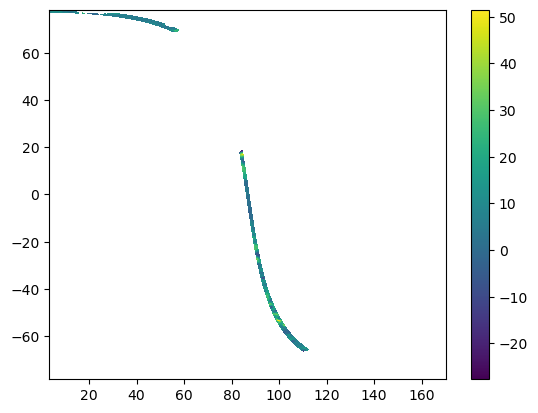

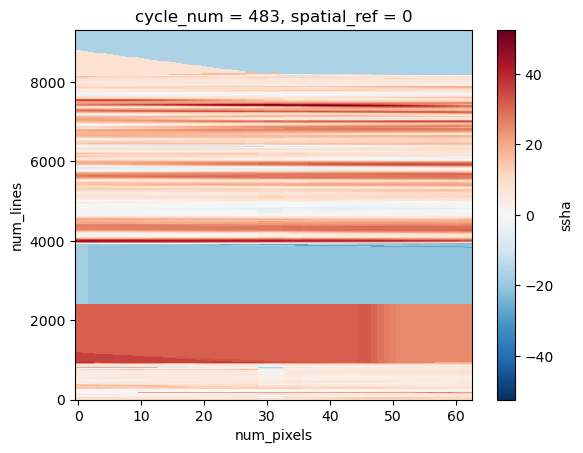

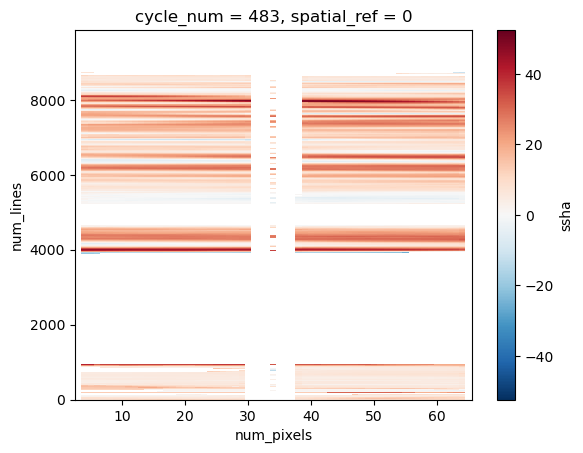

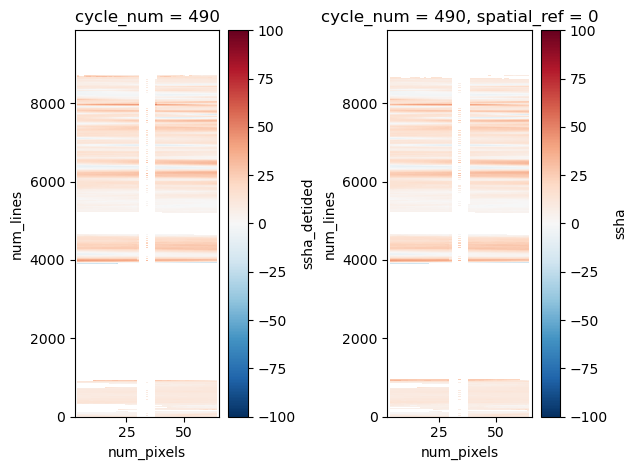

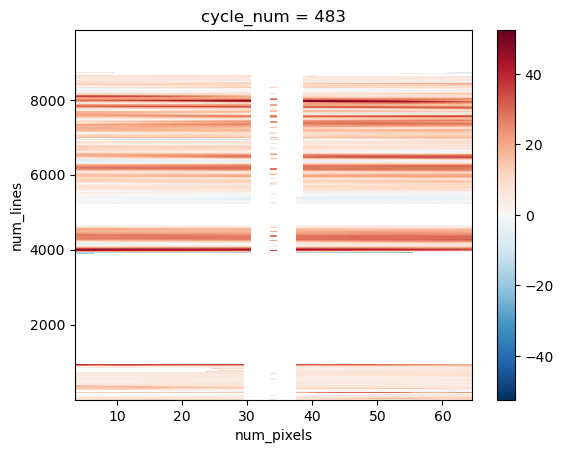

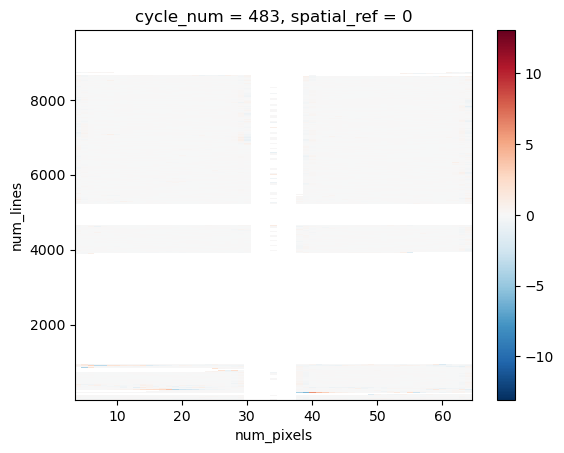

iiiiiiiiiiii
iiPass 010!!
!!!!!!!!!!!!


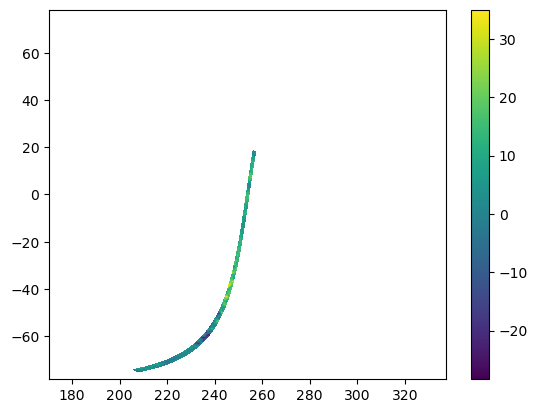

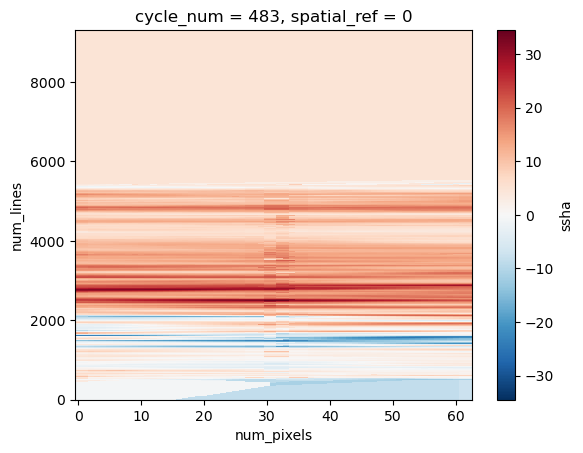

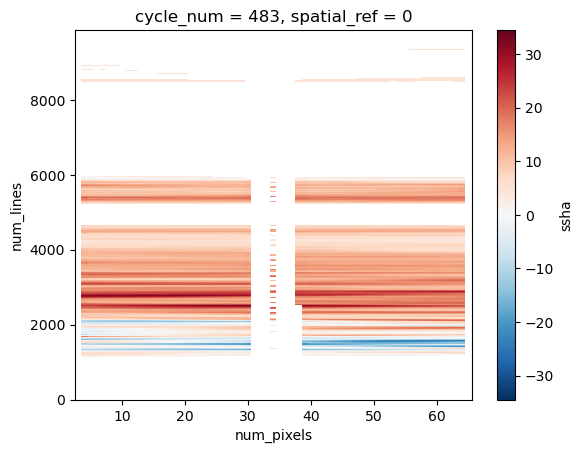

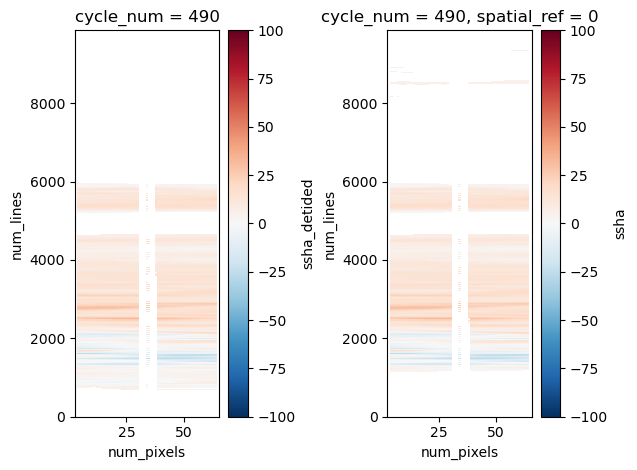

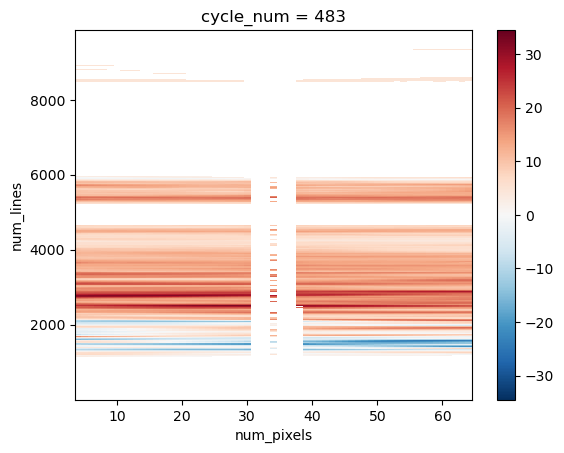

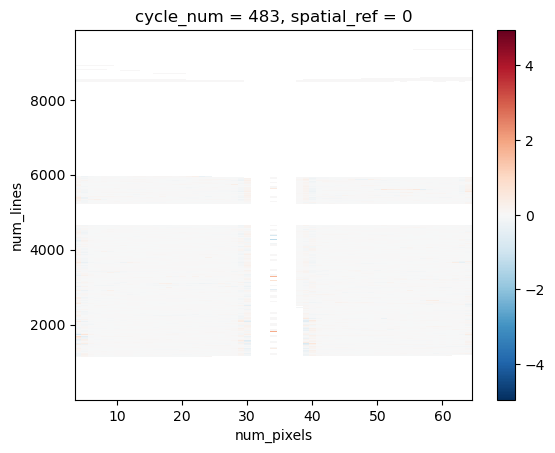

iiiiiiiiiiii
iiPass 011!!
!!!!!!!!!!!!


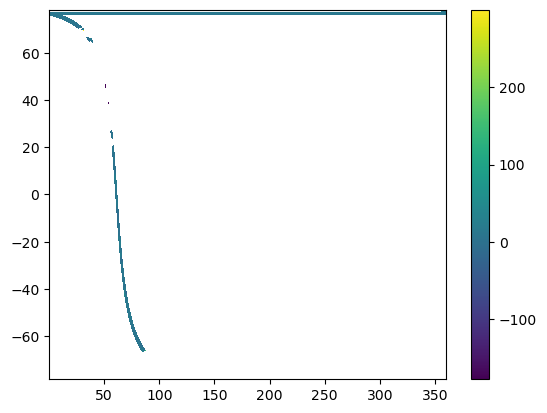

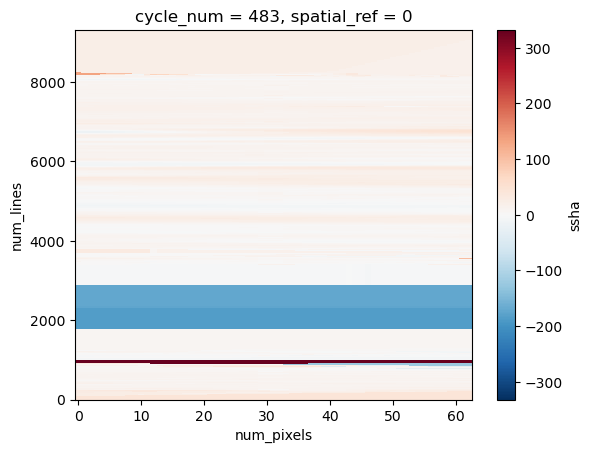

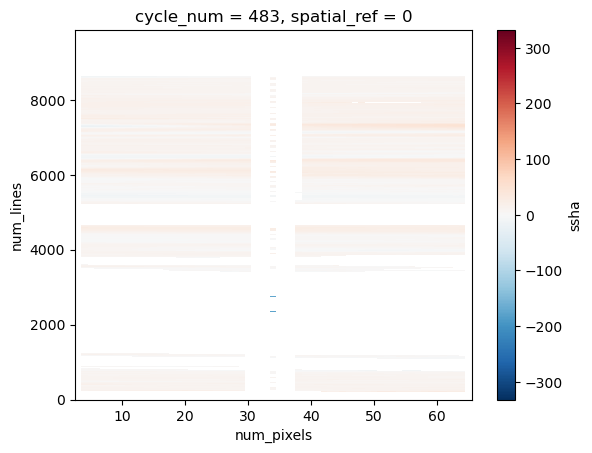

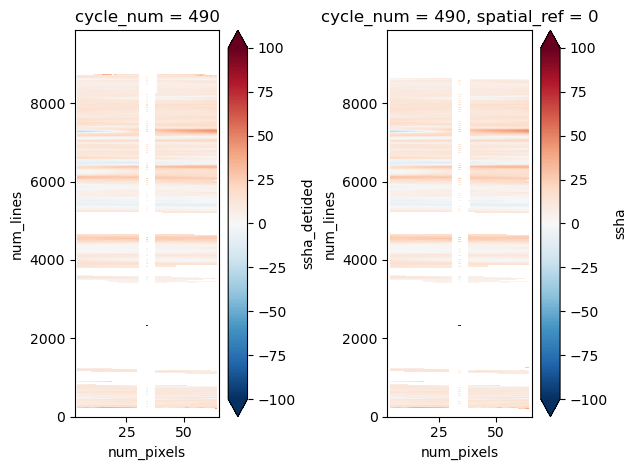

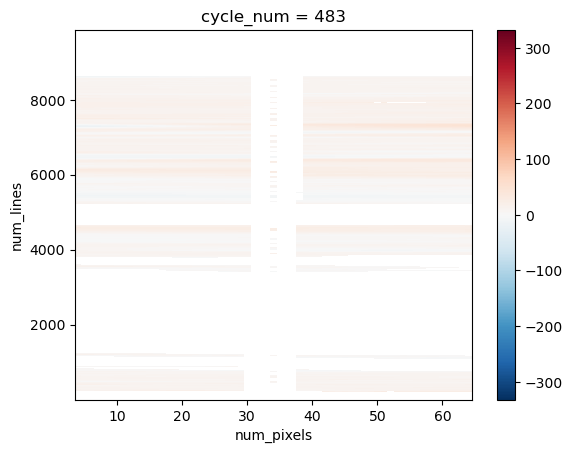

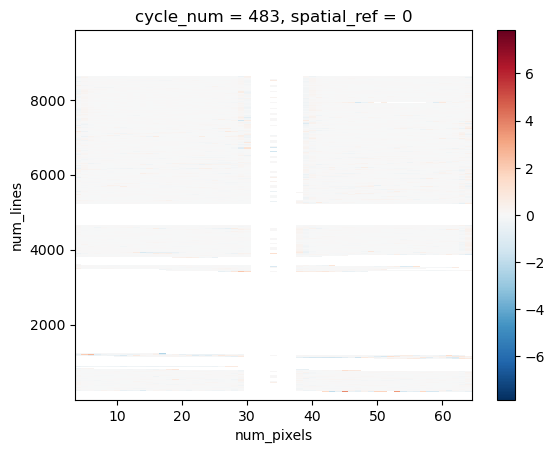

iiiiiiiiiiii
iiPass 012!!
!!!!!!!!!!!!


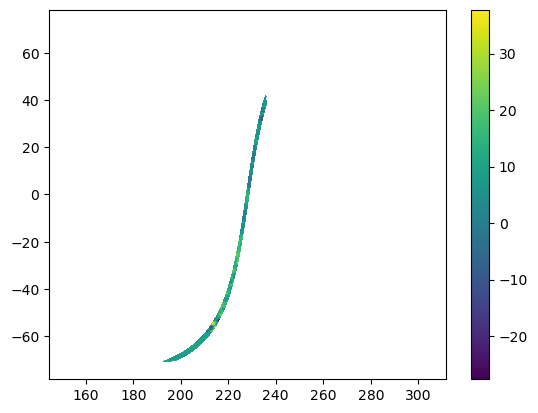

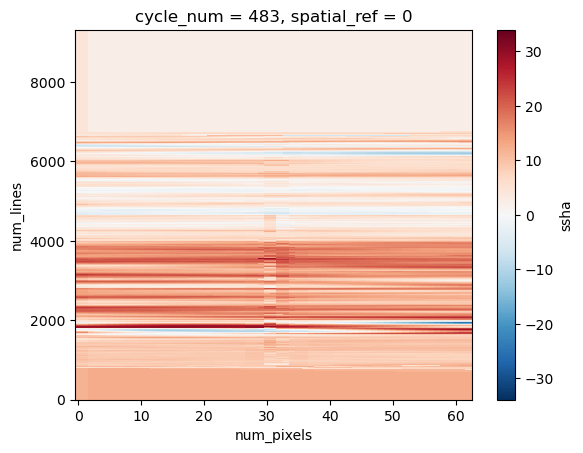

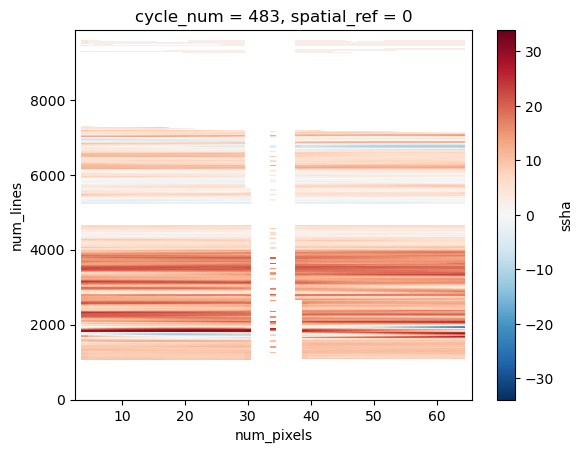

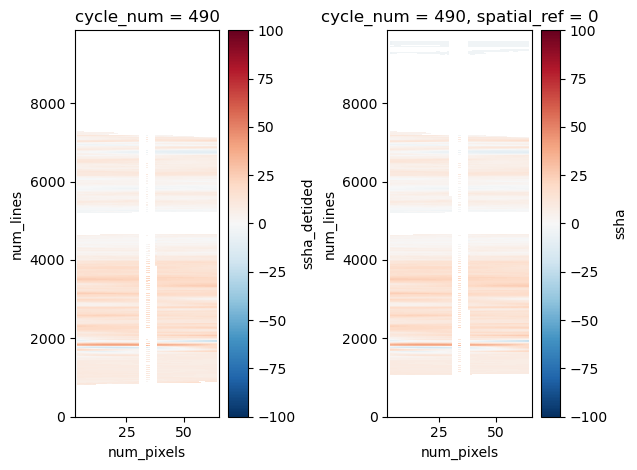

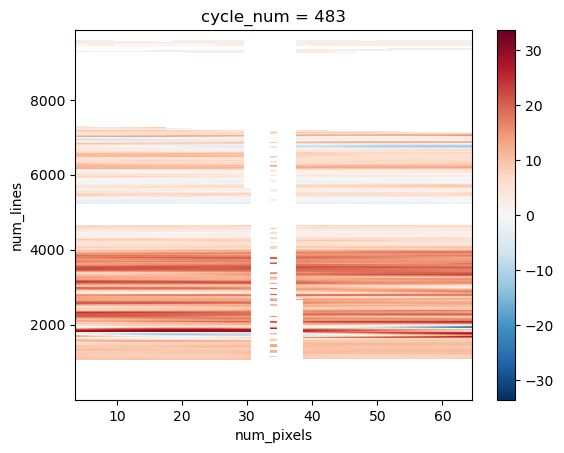

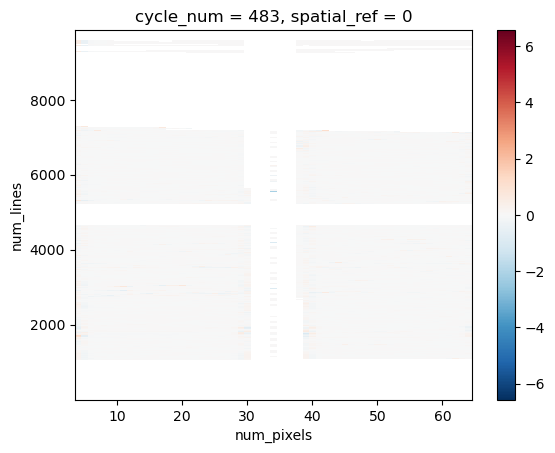

iiiiiiiiiiii
iiPass 013!!
!!!!!!!!!!!!


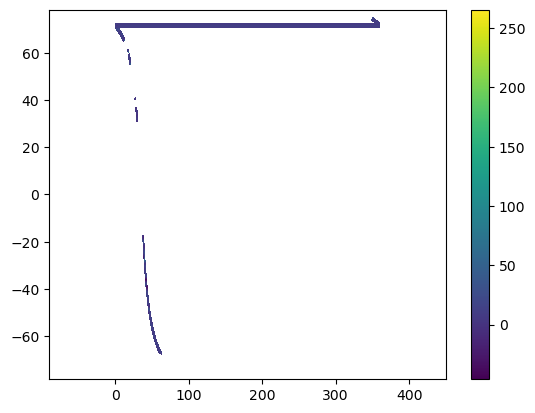

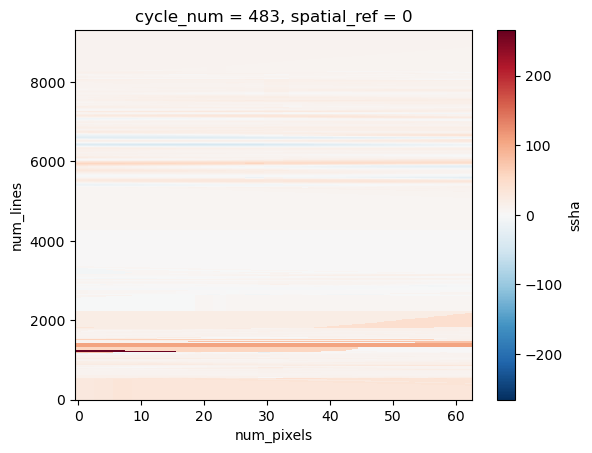

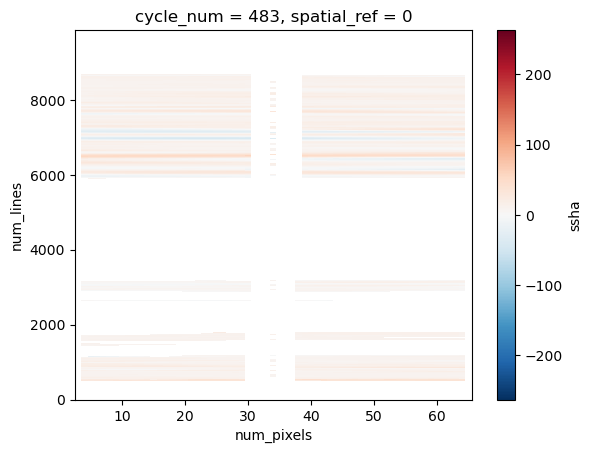

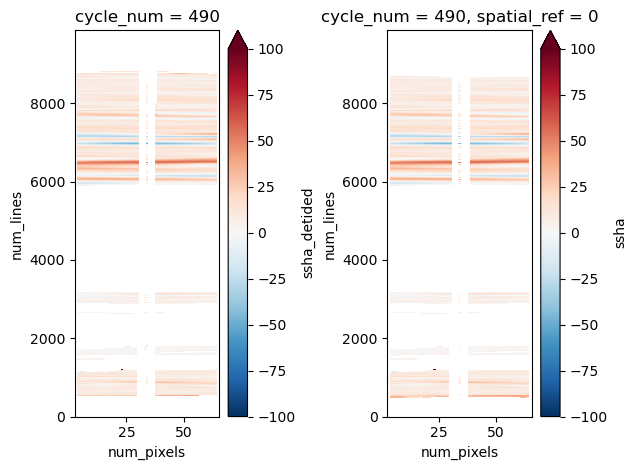

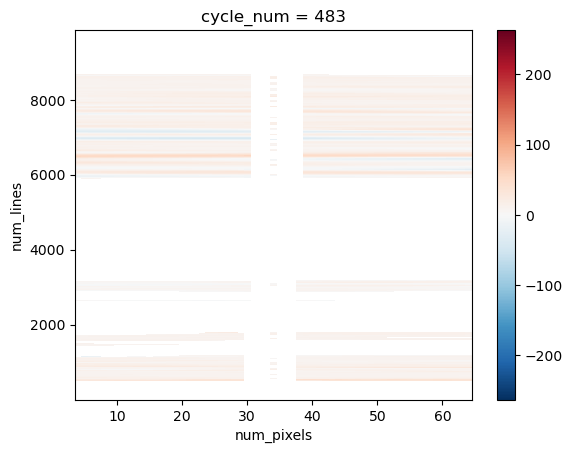

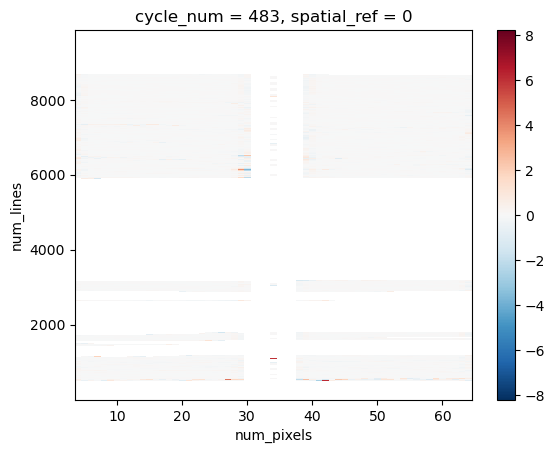

iiiiiiiiiiii
iiPass 014!!
!!!!!!!!!!!!


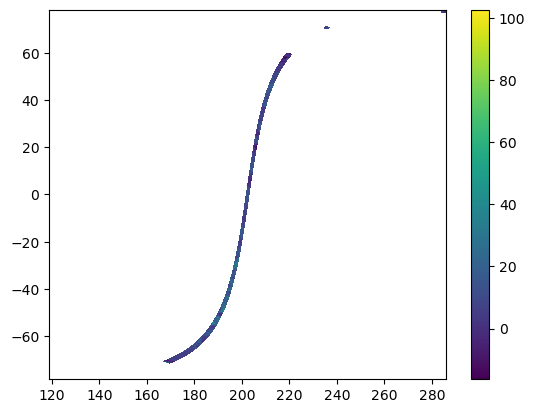

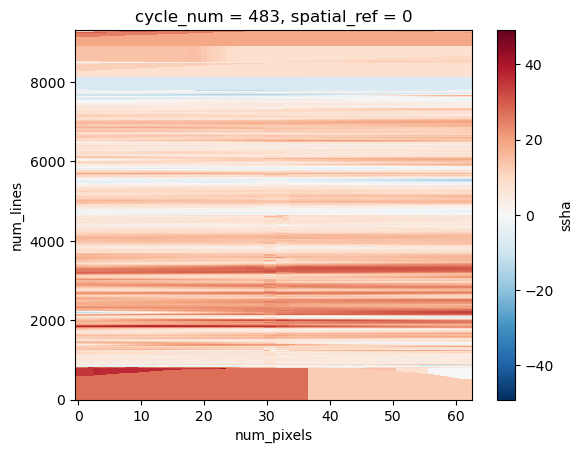

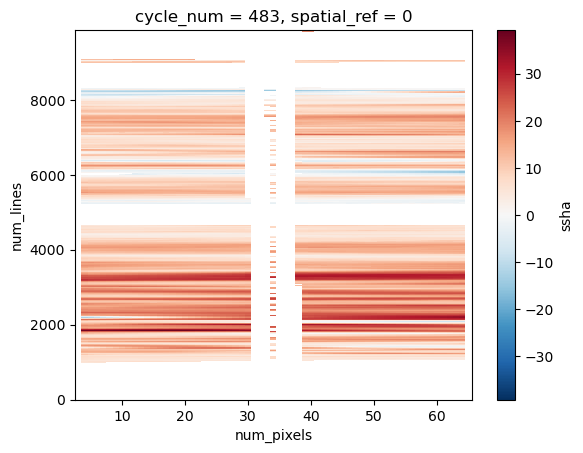

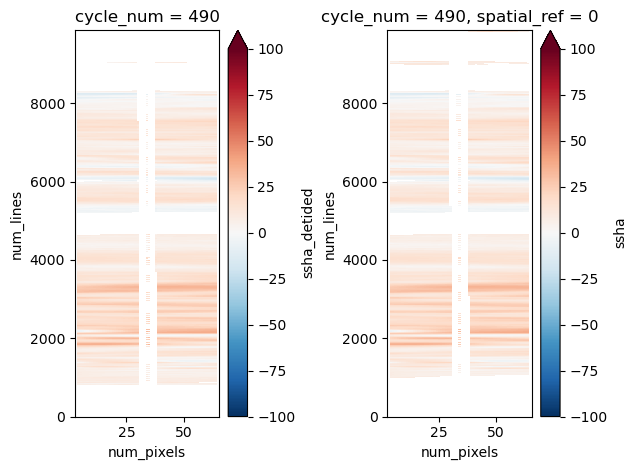

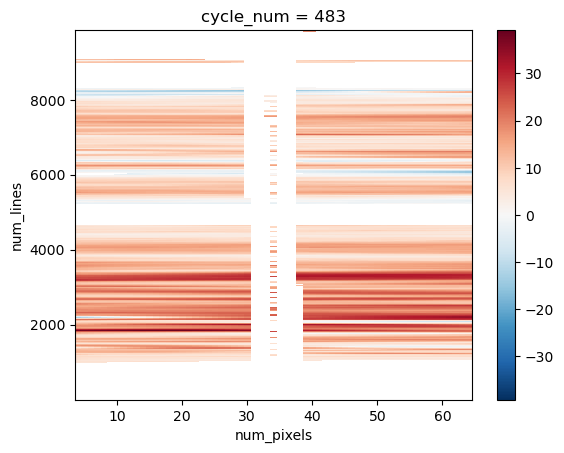

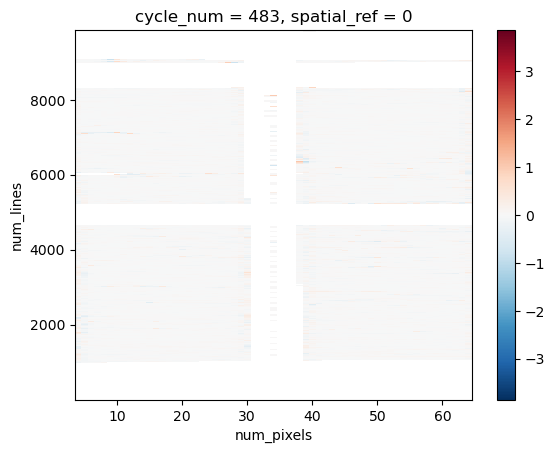

iiiiiiiiiiii
iiPass 015!!
!!!!!!!!!!!!


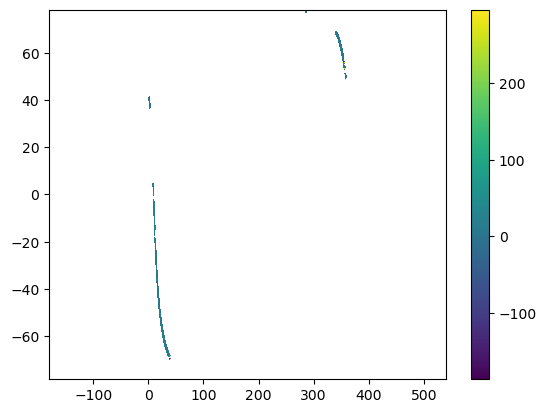

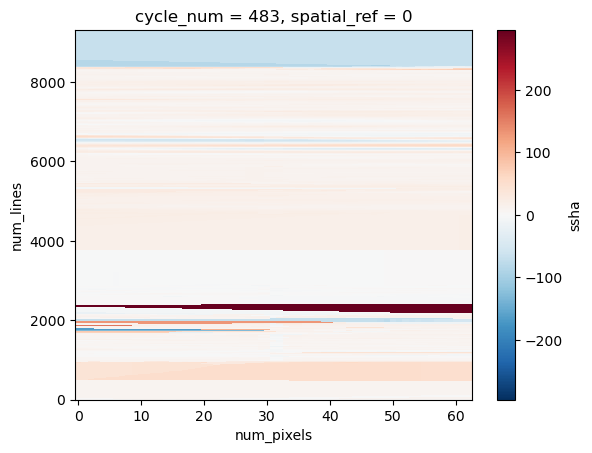

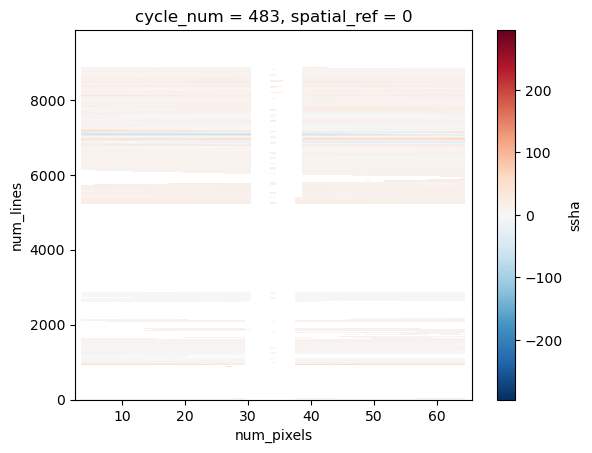

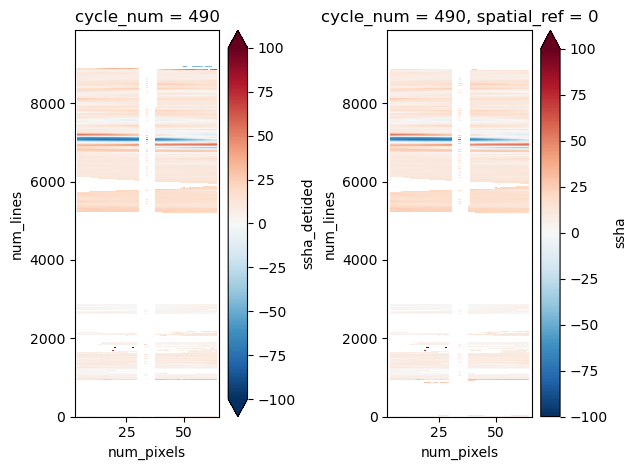

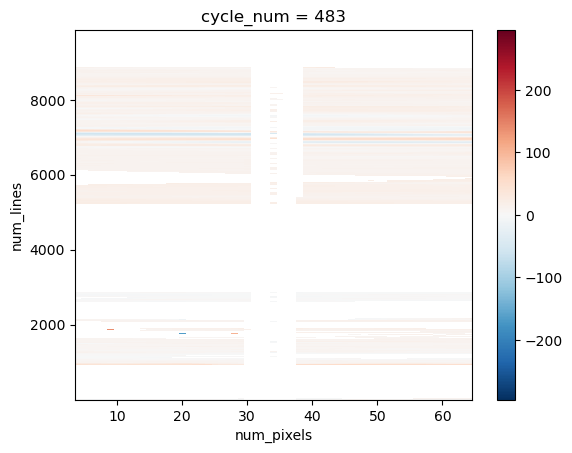

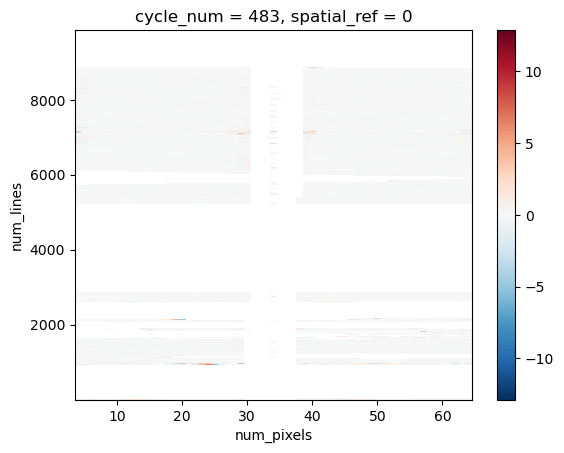

iiiiiiiiiiii
iiPass 016!!
!!!!!!!!!!!!


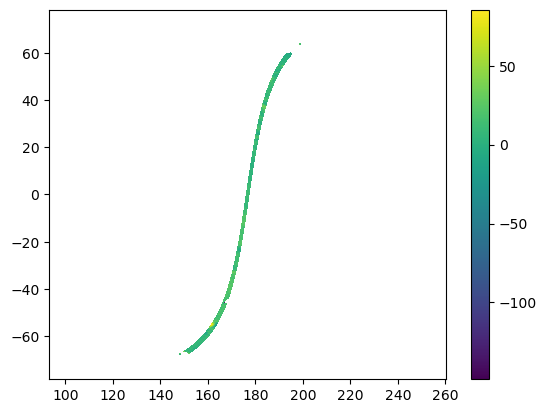

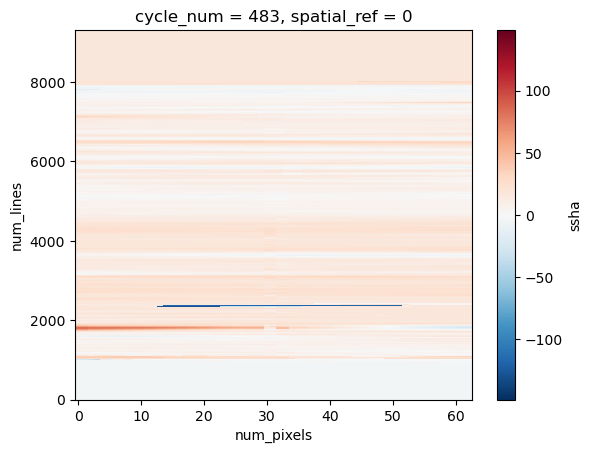

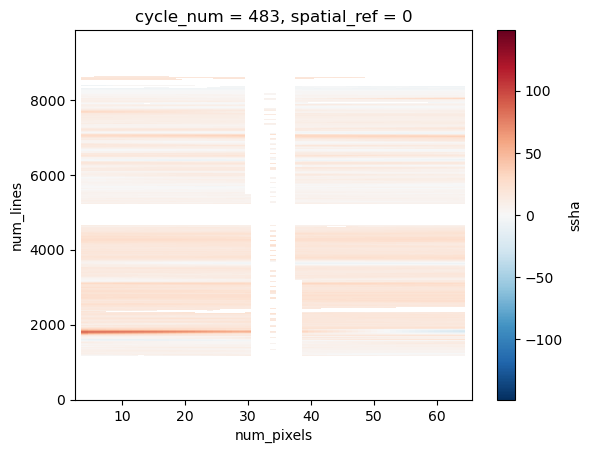

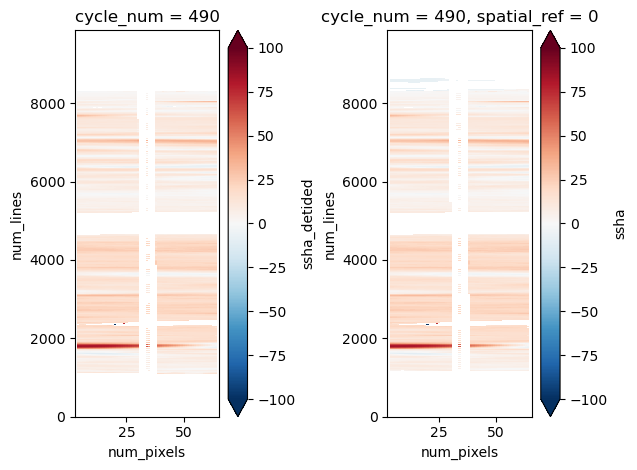

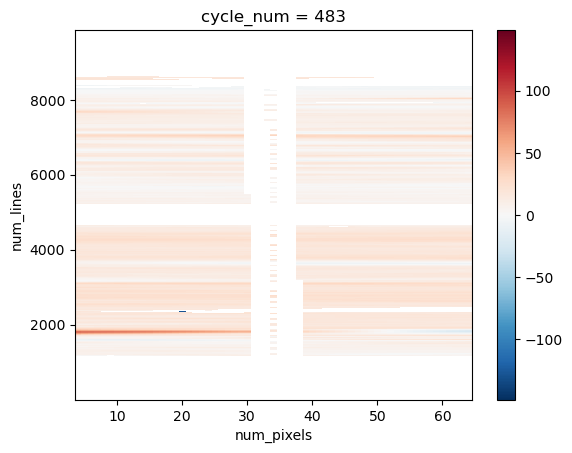

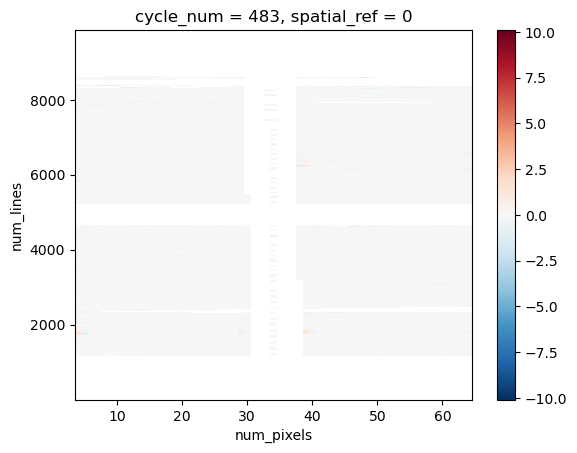

iiiiiiiiiiii
iiPass 017!!
!!!!!!!!!!!!


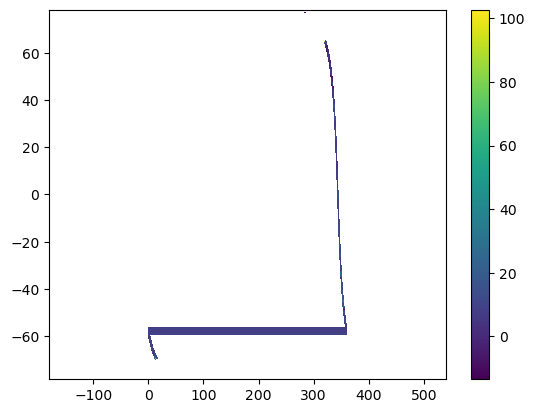

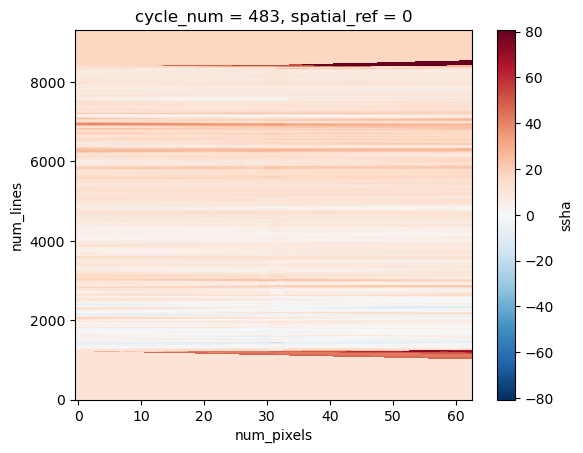

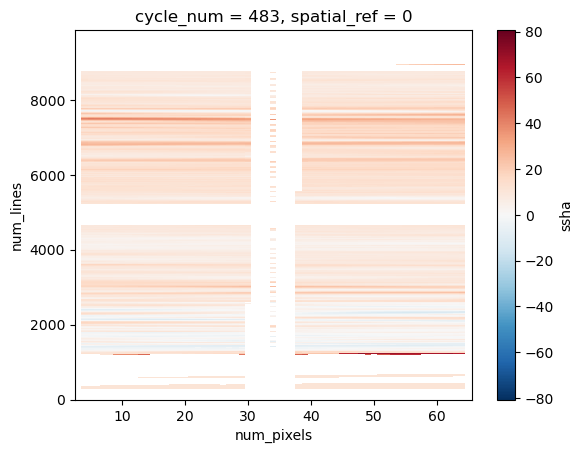

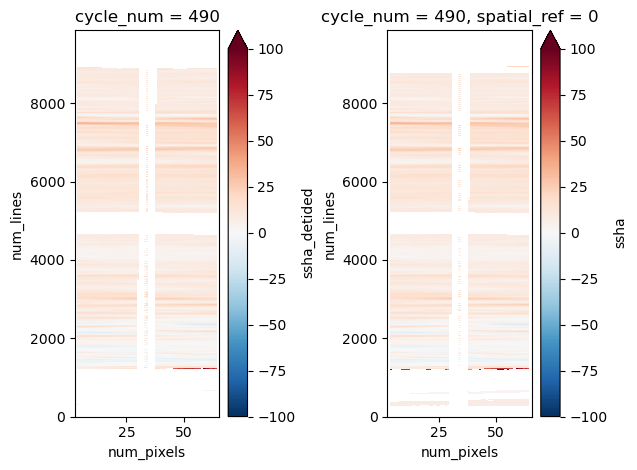

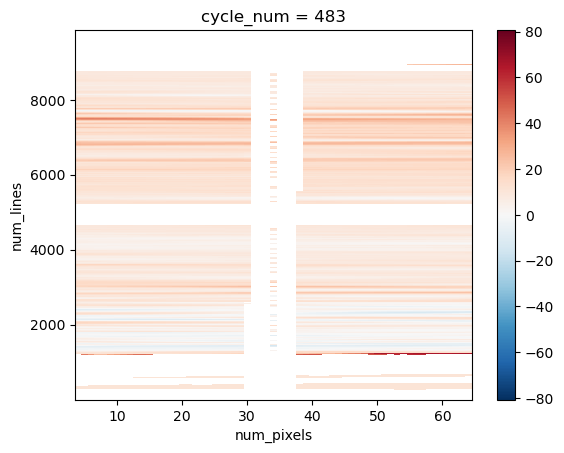

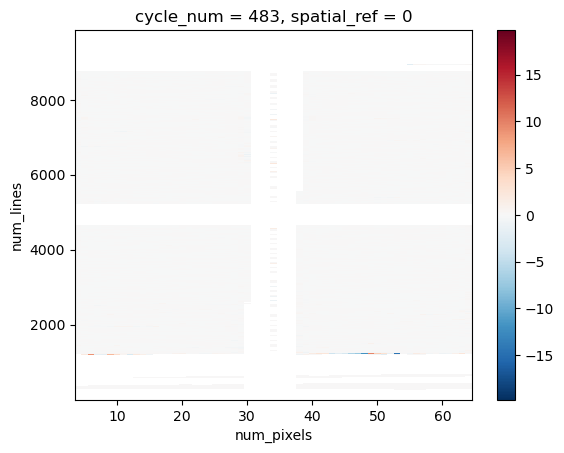

iiiiiiiiiiii
iiPass 018!!
!!!!!!!!!!!!


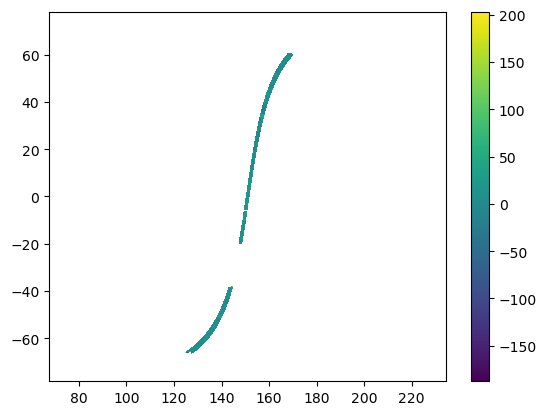

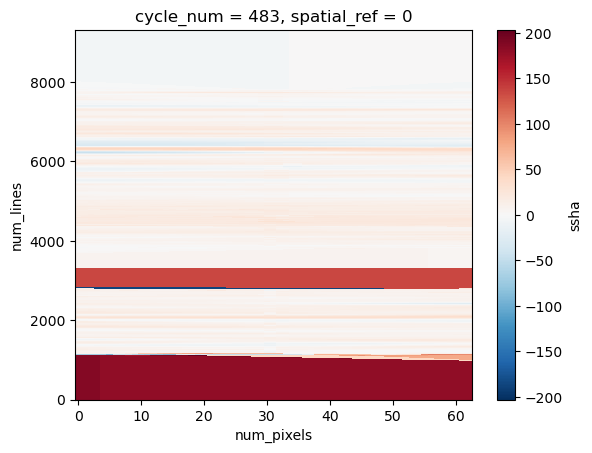

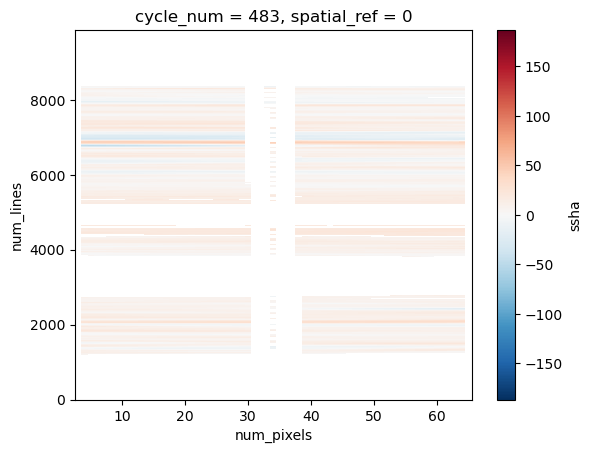

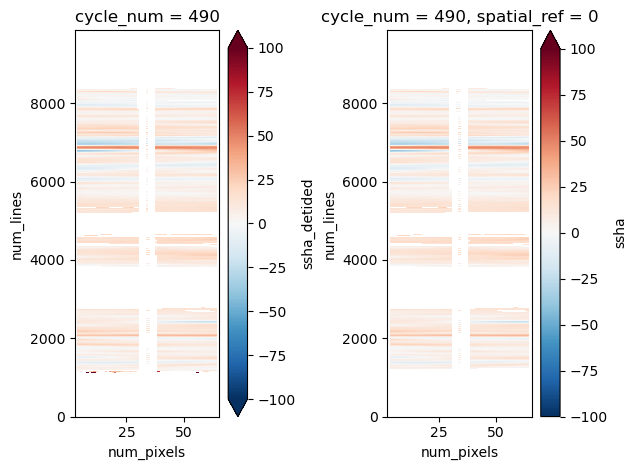

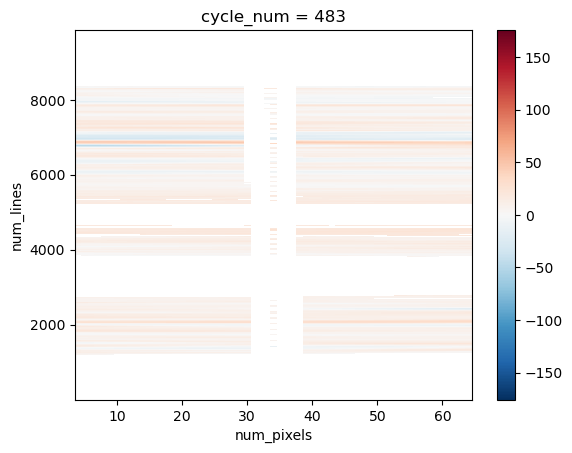

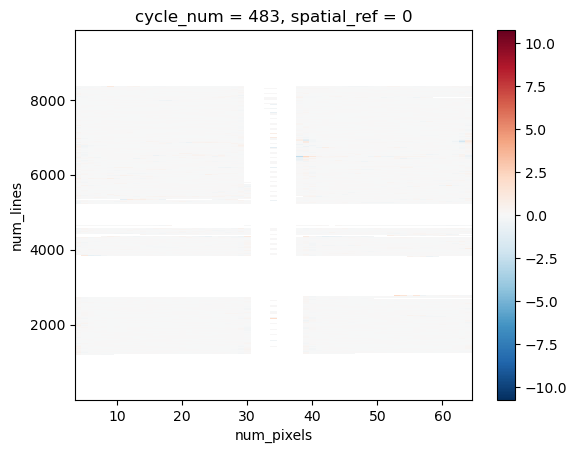

iiiiiiiiiiii
iiPass 019!!
!!!!!!!!!!!!


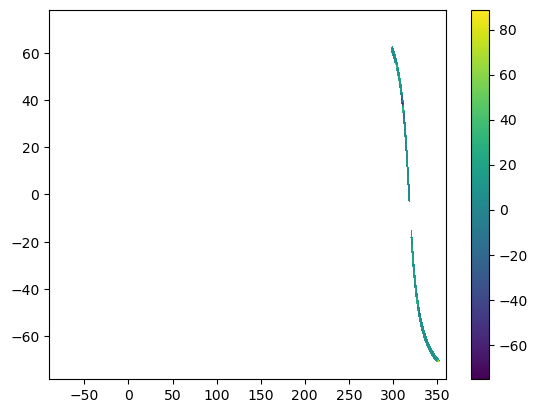

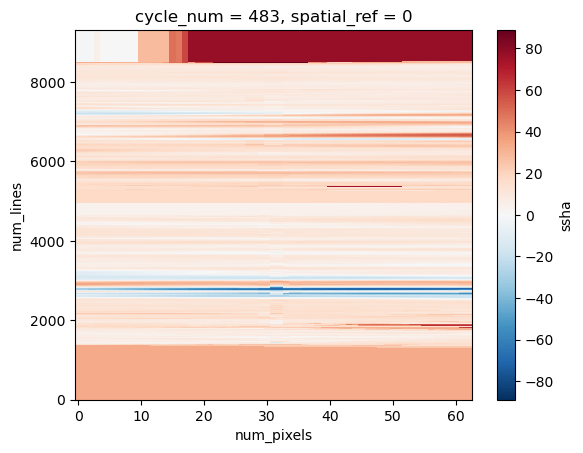

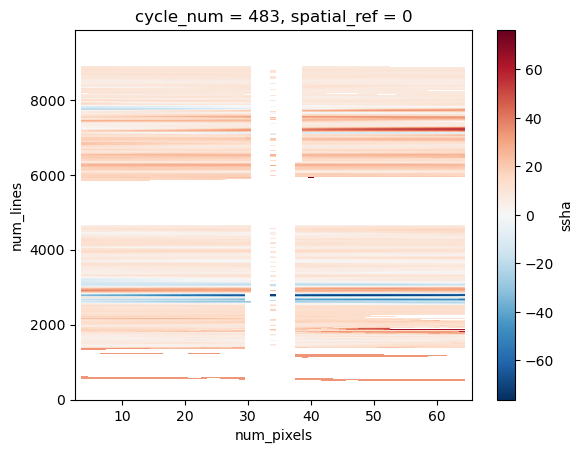

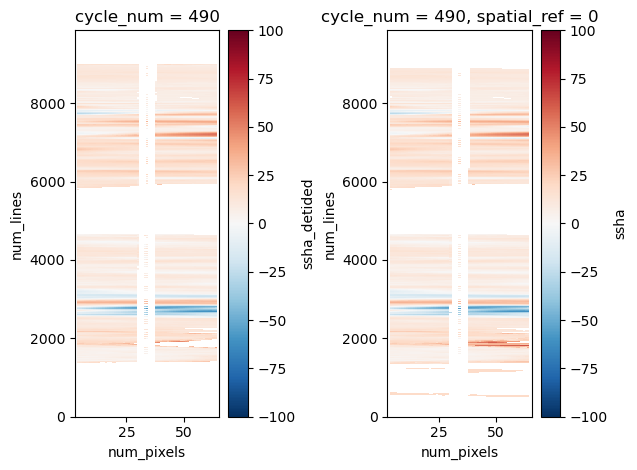

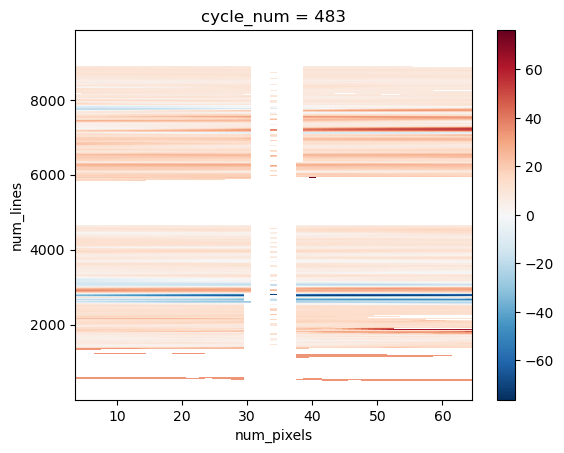

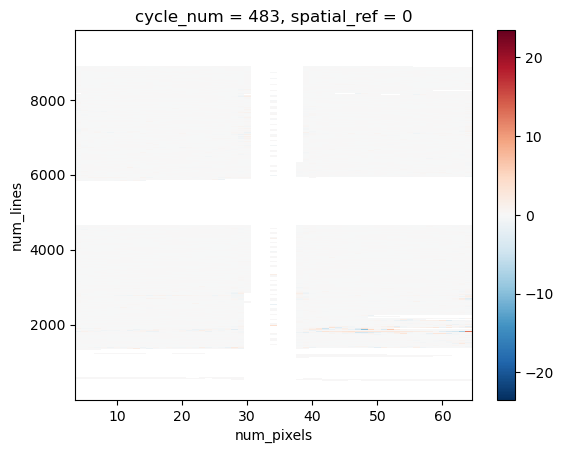

iiiiiiiiiiii
iiPass 020!!
!!!!!!!!!!!!


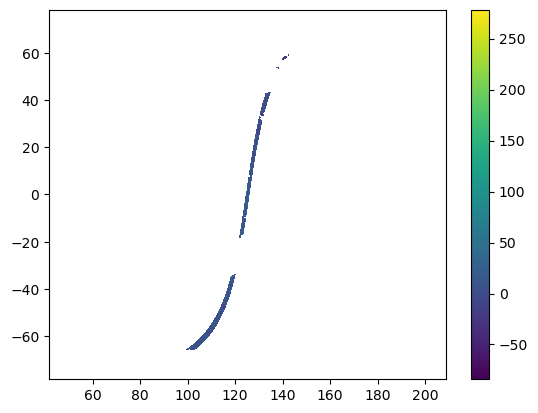

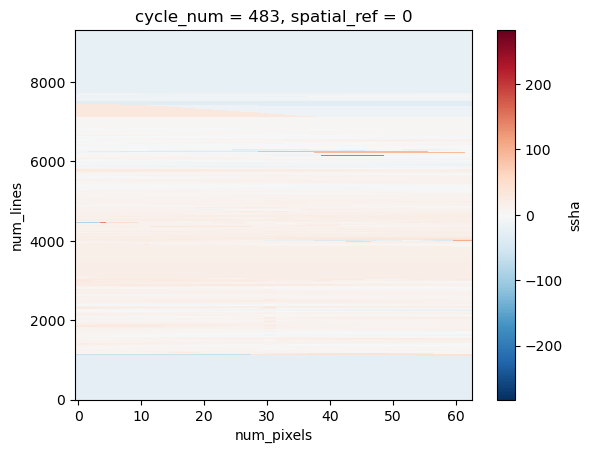

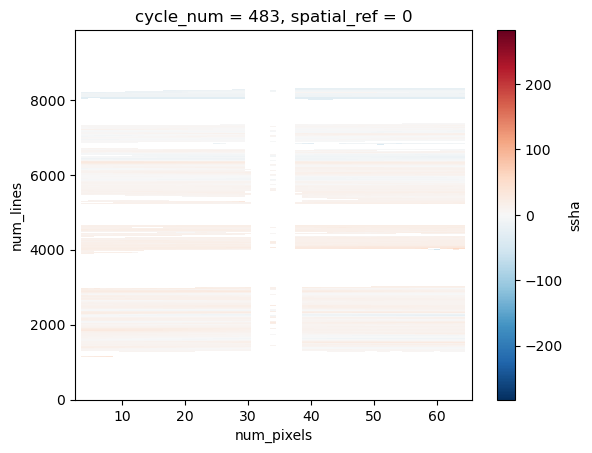

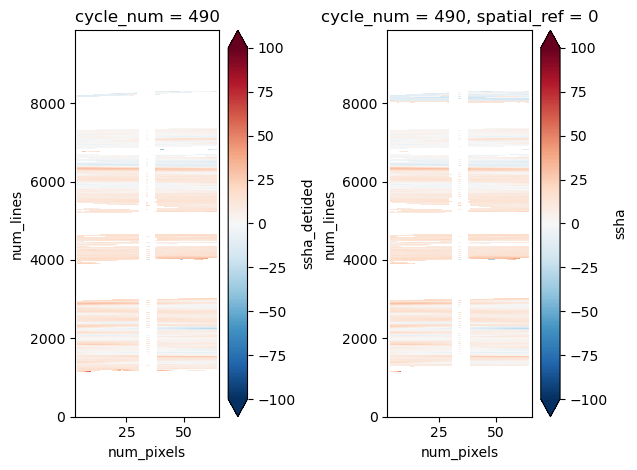

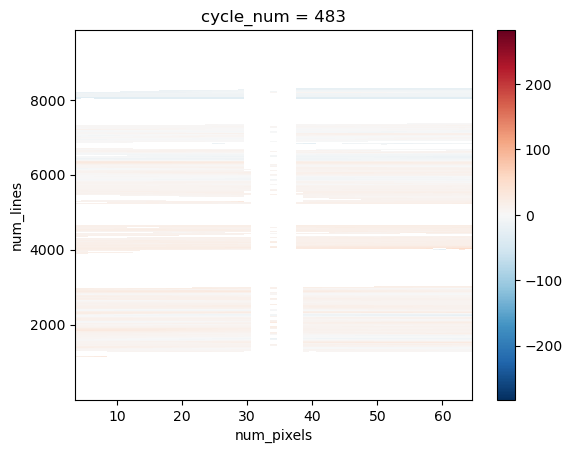

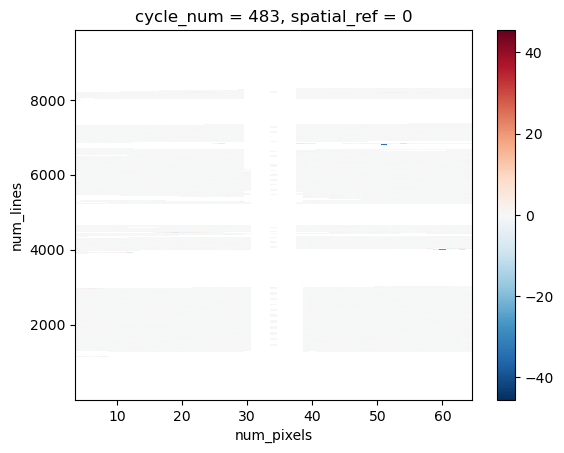

iiiiiiiiiiii
iiPass 021!!
!!!!!!!!!!!!


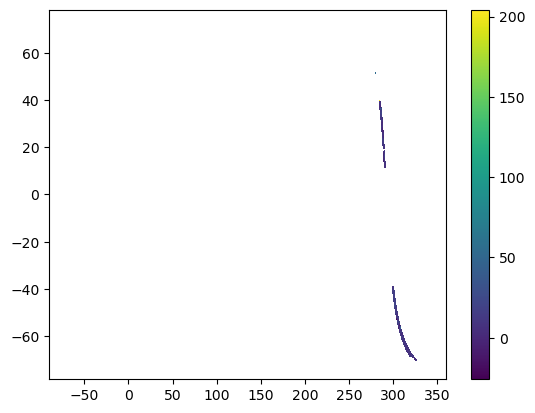

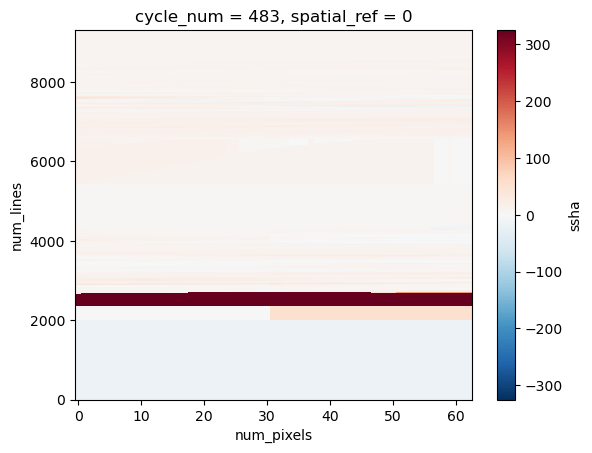

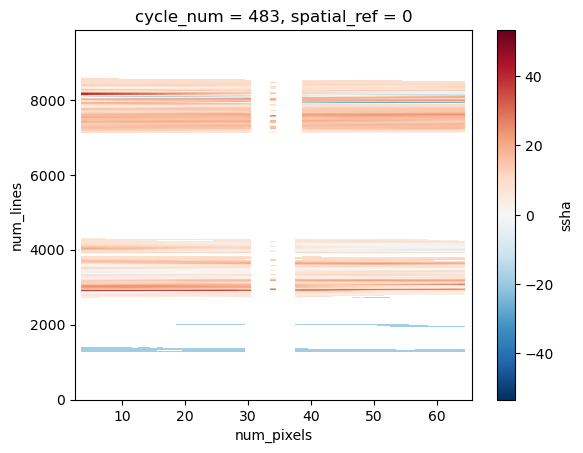

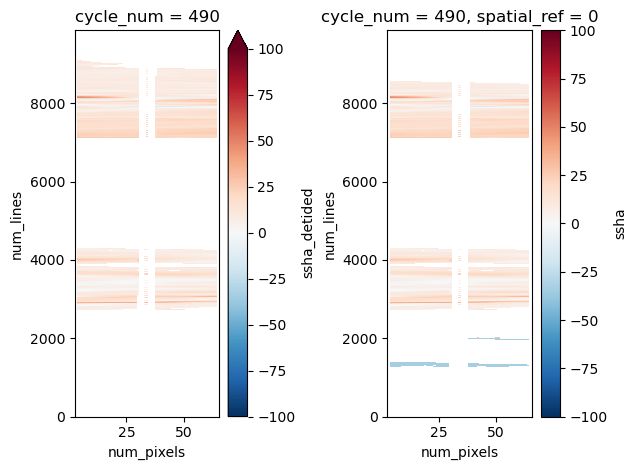

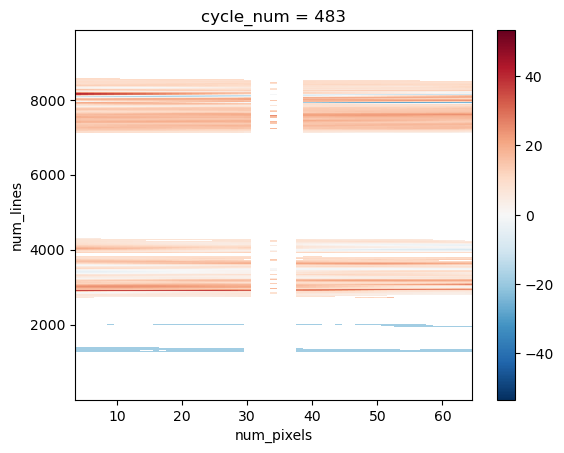

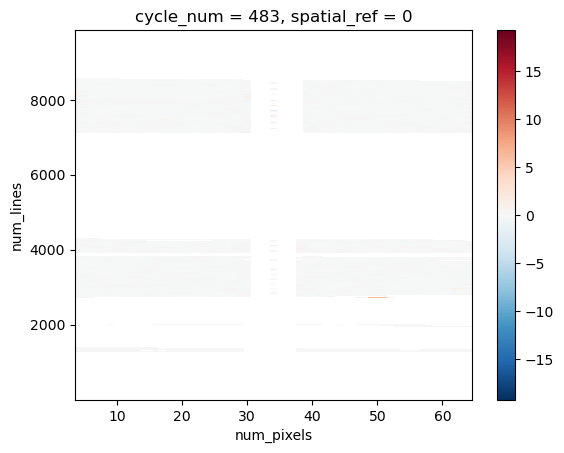

iiiiiiiiiiii
iiPass 022!!
!!!!!!!!!!!!


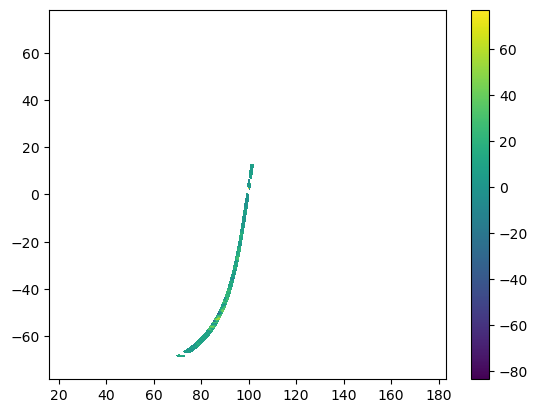

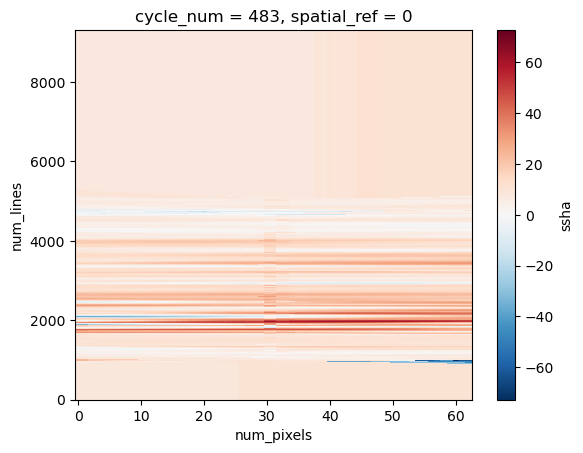

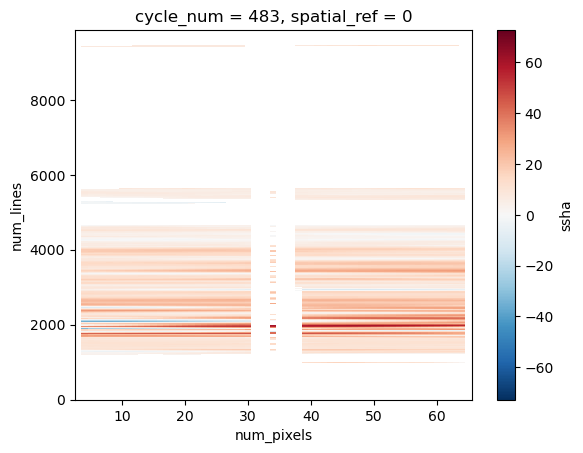

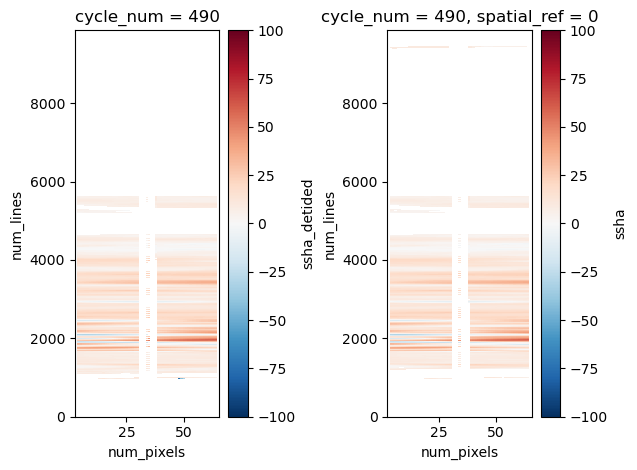

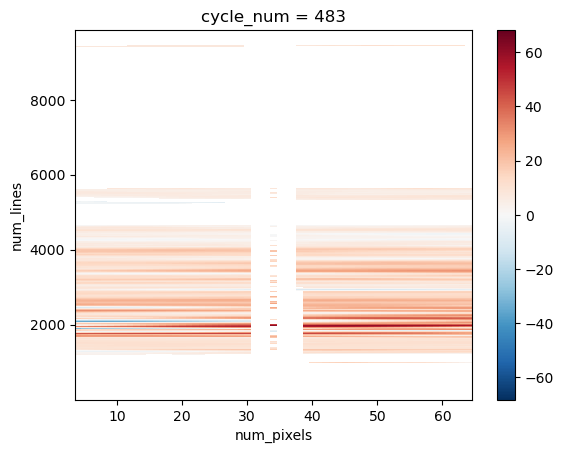

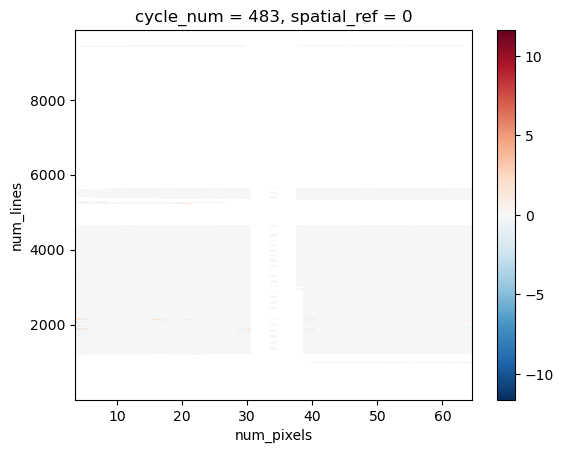

iiiiiiiiiiii
iiPass 023!!
!!!!!!!!!!!!


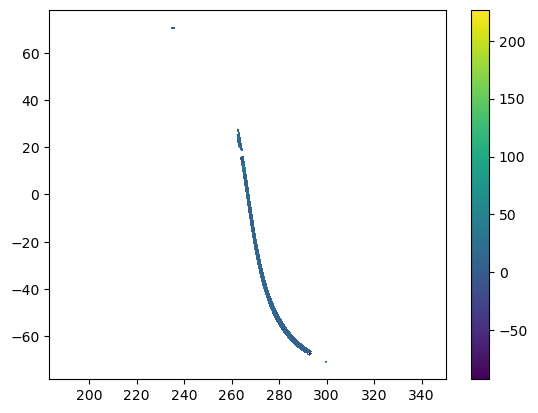

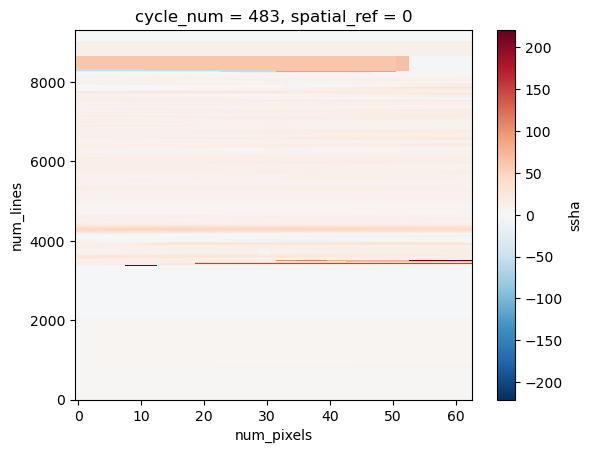

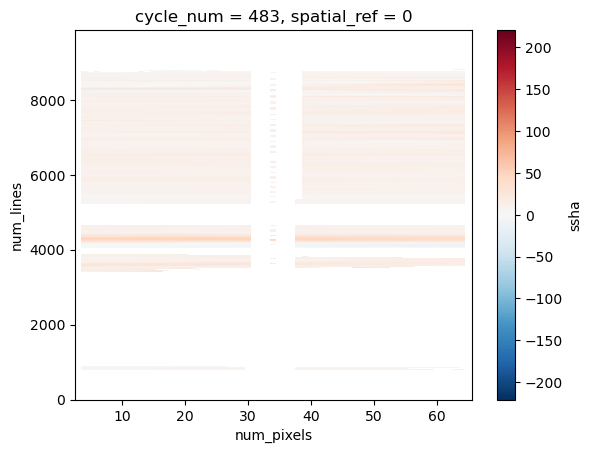

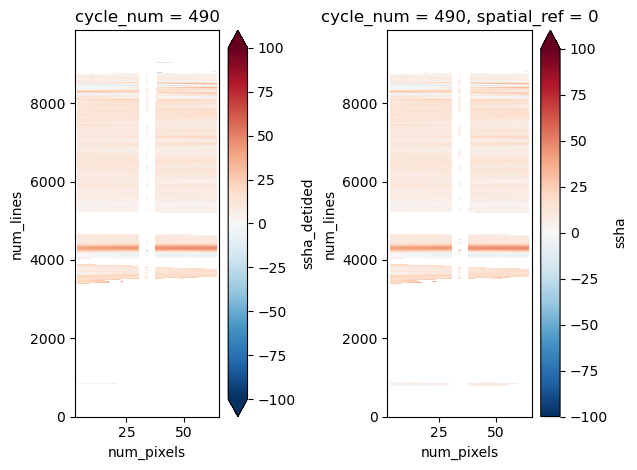

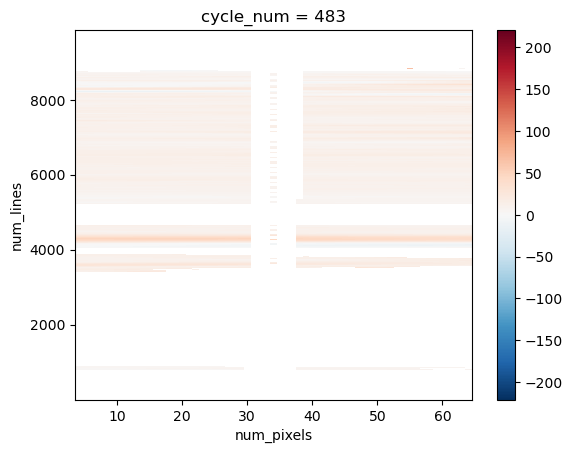

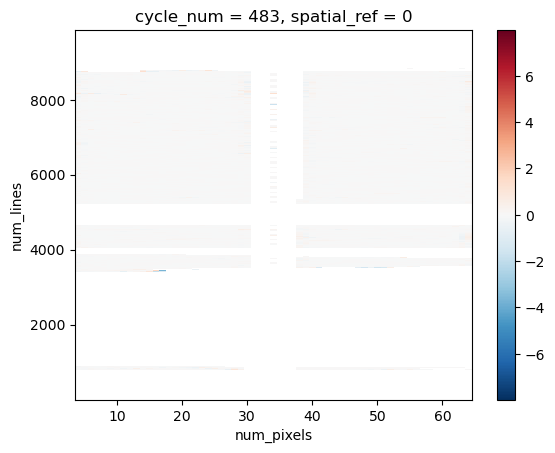

iiiiiiiiiiii
iiPass 024!!
!!!!!!!!!!!!


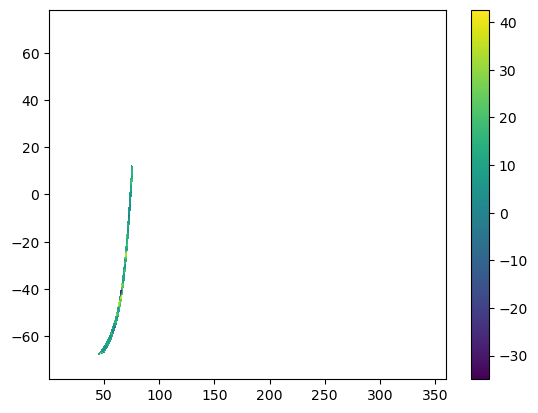

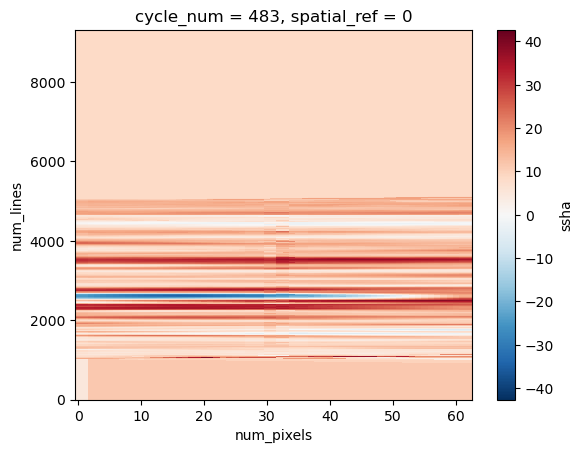

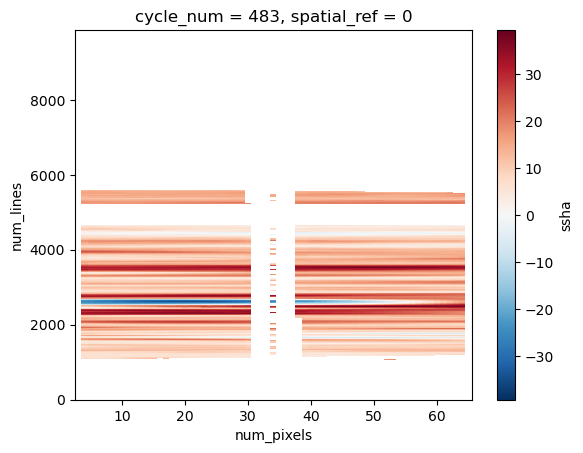

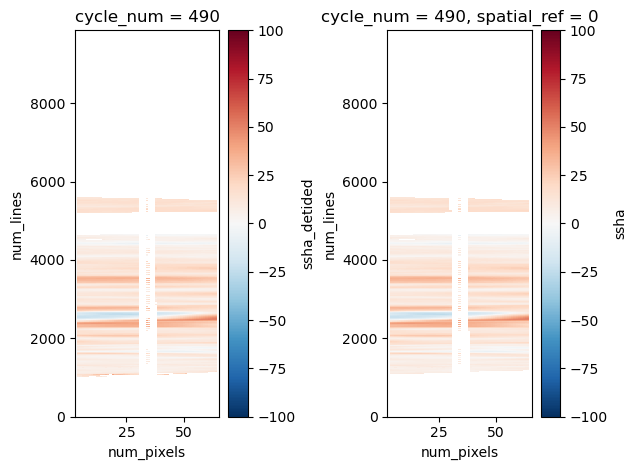

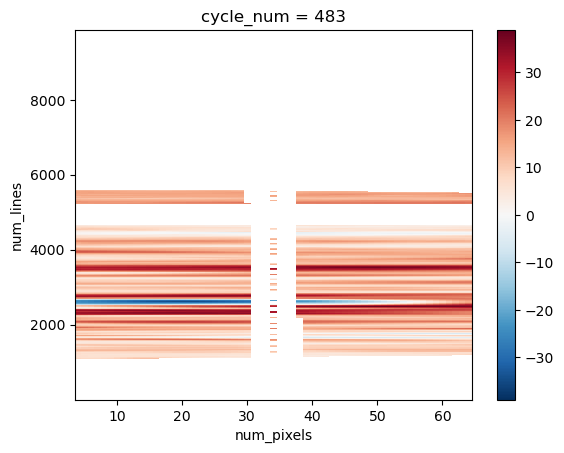

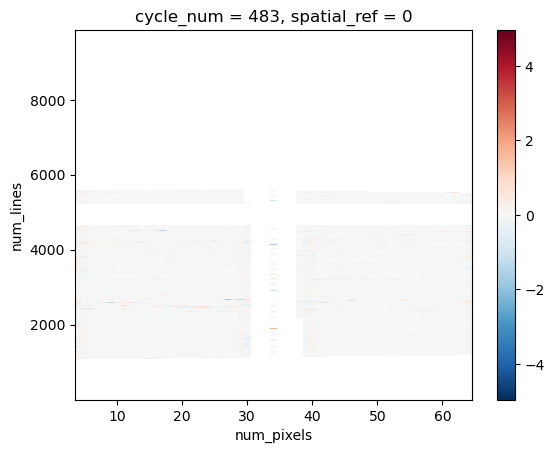

iiiiiiiiiiii
iiPass 025!!
!!!!!!!!!!!!


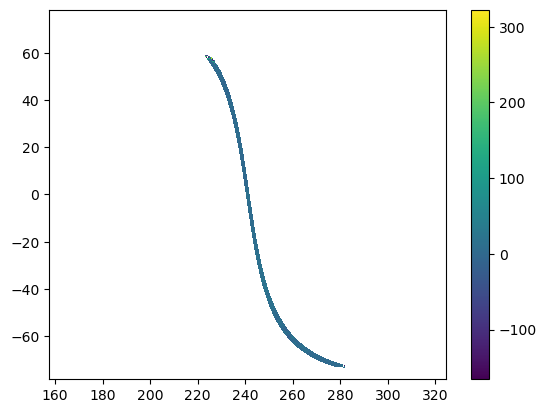

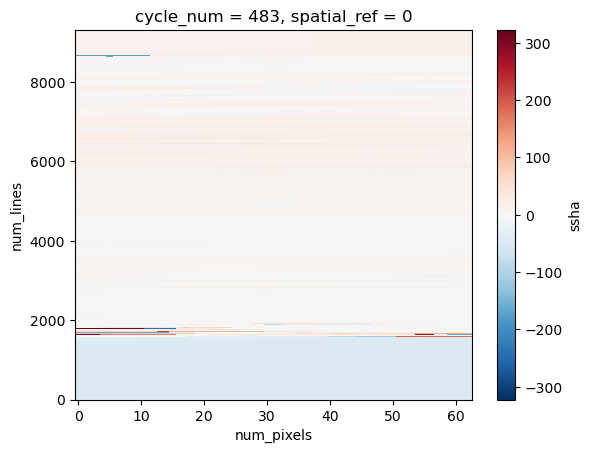

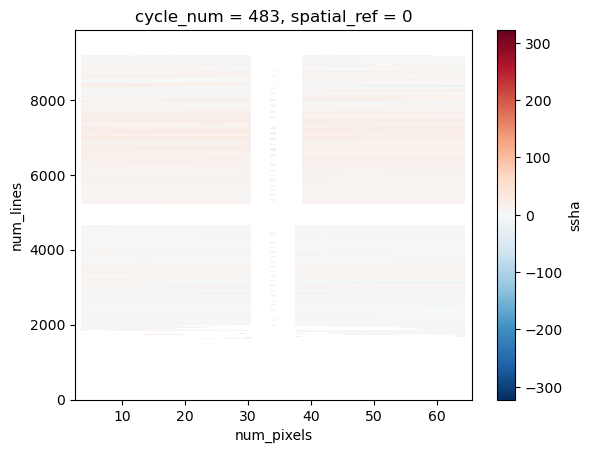

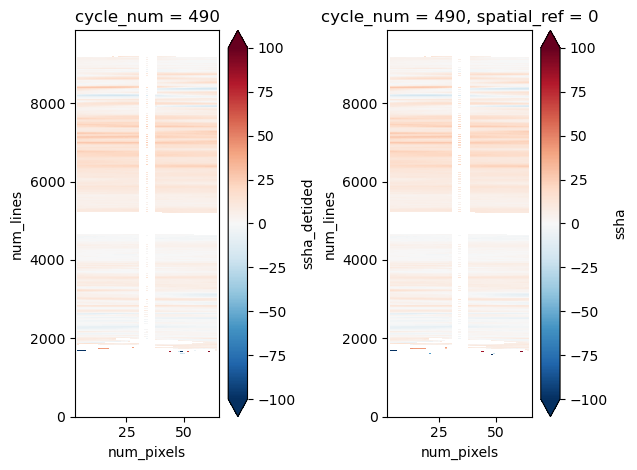

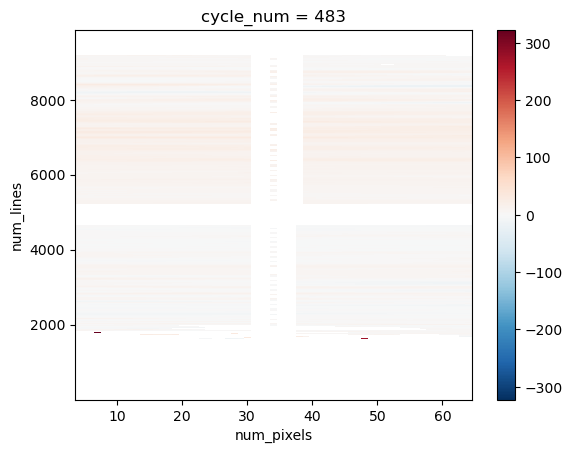

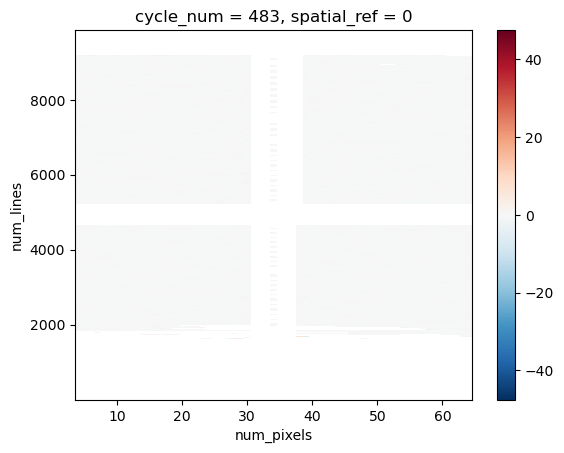

iiiiiiiiiiii
iiPass 026!!
!!!!!!!!!!!!


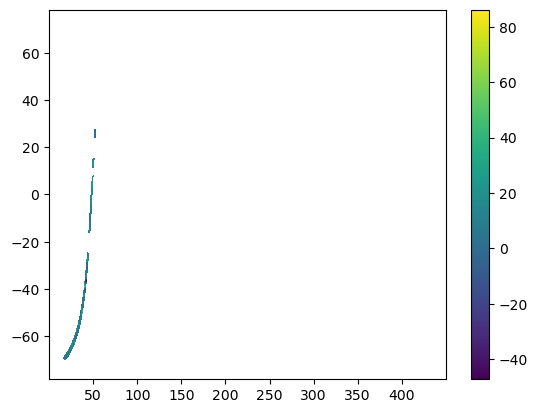

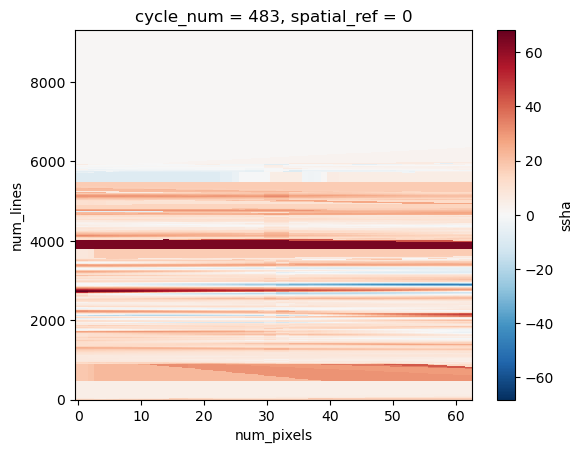

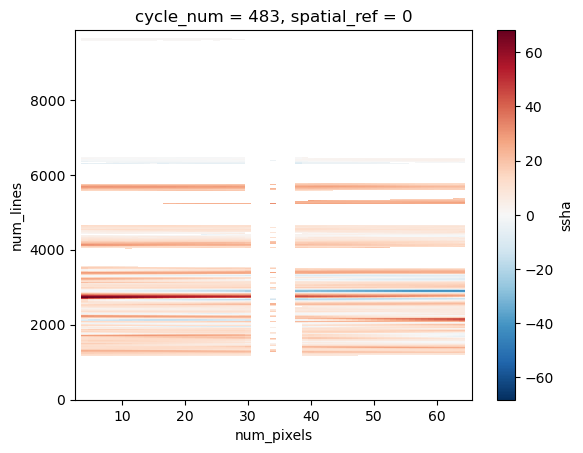

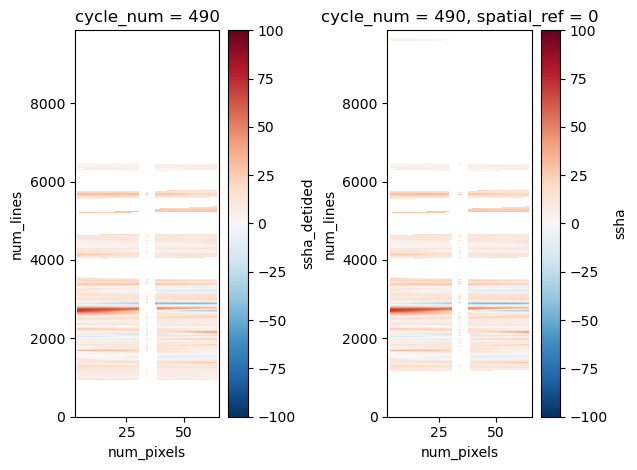

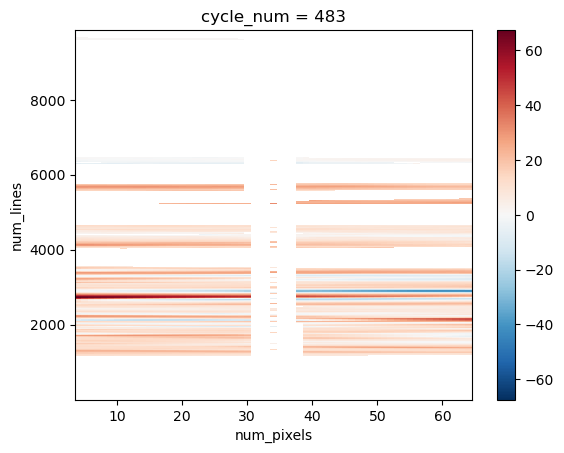

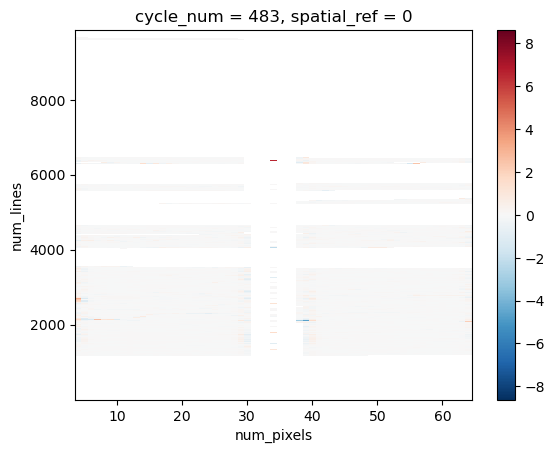

iiiiiiiiiiii
iiPass 027!!
!!!!!!!!!!!!


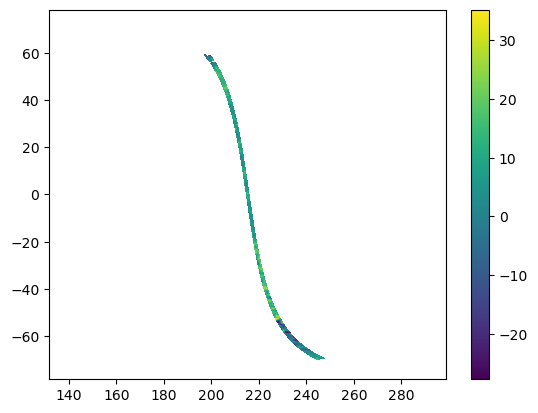

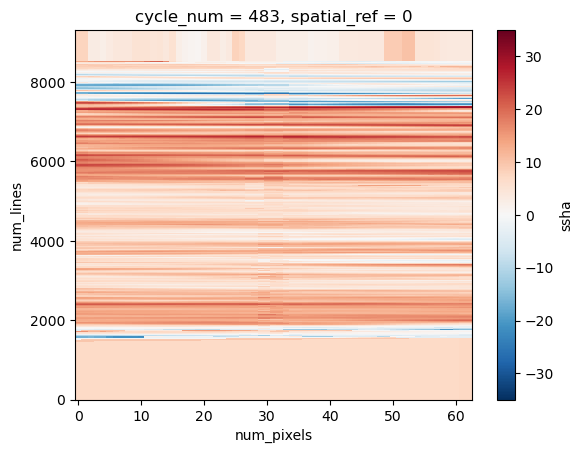

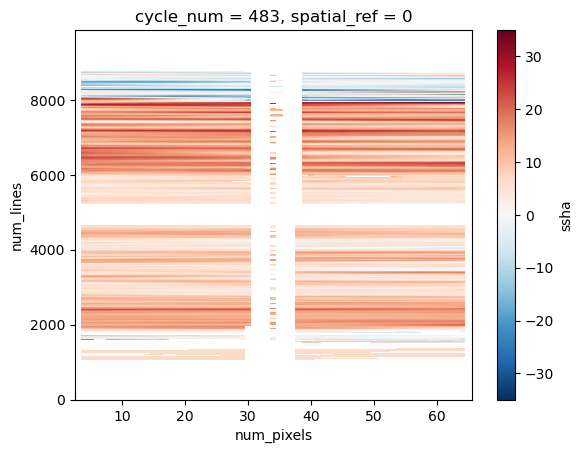

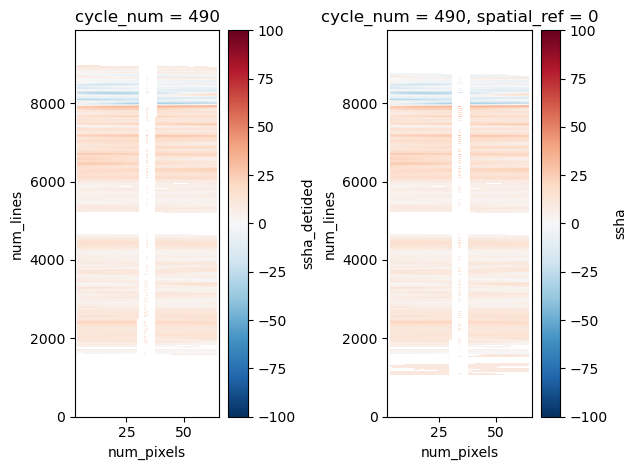

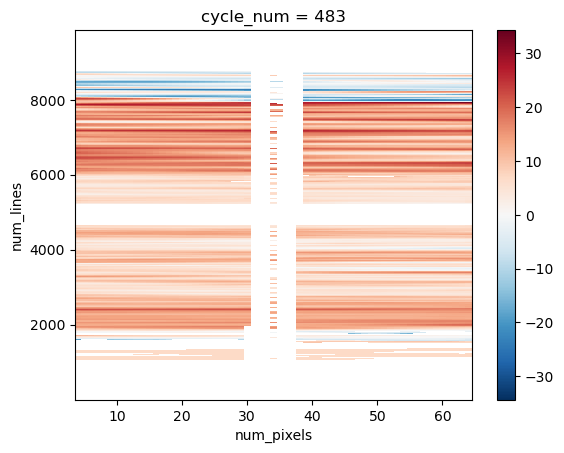

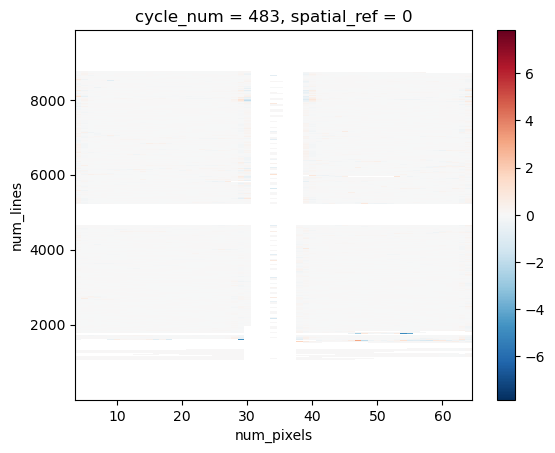

iiiiiiiiiiii
iiPass 028!!
!!!!!!!!!!!!


In [12]:
for ipass in range(1,29):
    ds = xr.open_zarr(op.join(ddir,
                              "SWOT_no_IT/10D_rolling/CalVal_pass%03d_v2.0.1.zarr"
                              % ipass))
    ds.coords["num_lines"] = ("num_lines",range(len(ds.num_lines)))
    ds.coords["num_pixels"] = ("num_pixels",range(len(ds.num_pixels)))

    fig, ax = plt.subplots()
    im = ax.pcolor(ds.longitude, ds.latitude,
              ds.ssha_detided.isel(cycle_num=1), 
              rasterized=True
             )
    fig.colorbar(im)
    plt.show()

    inp = 3
    maskn = xr.DataArray(ds.latitude.where(ds.latitude>5.).to_masked_array().mask,
                         dims=ds.latitude.dims,
                         coords=ds.latitude.coords
                        )
    masks = xr.DataArray(ds.latitude.where(ds.latitude<-5.).to_masked_array().mask,
                         dims=ds.latitude.dims,
                         coords=ds.latitude.coords
                        )
    dsns = ds.where(~maskn,drop=True)
    dsns = xr.concat([dsns, ds.where(~masks,drop=True)
                     ], "num_lines"
                    ).sortby("num_lines")

    maskns = xr.DataArray(dsns.ssha_detided.to_masked_array().mask.mean(axis=0), 
                          dims=dsns.ssha_detided.isel(cycle_num=0).dims, 
                          coords=dsns.ssha_detided.isel(cycle_num=0).coords
                         )
    mm = xr.DataArray(maskns.where(maskns<.5
                                  ).to_masked_array().mask,
                      dims=dsns.ssha_detided.isel(cycle_num=0).dims, 
                      coords=dsns.ssha_detided.isel(cycle_num=0).coords
                     ).isel(num_pixels=slice(inp,-inp))

    r_ref = (~mm).sum() / np.prod(mm.shape)

    ic = 0
    for cc in dsns.cycle_num:
        
        ssha = dsns.ssha_detided.sel(cycle_num=cc
                                    ).isel(num_pixels=slice(inp,-inp))
        
        array = ssha.to_masked_array()
        mask = ~array.mask
        ratio = mask.sum() / np.prod(mask.shape)
        if ic == 0:
            R = xr.DataArray(np.array([ratio]), 
                             dims='cycle_num', 
                             coords={'cycle_num':np.array([cc.values,])}
                            )
        else:
            R = xr.concat([R, xr.DataArray(np.array([ratio]), 
                                   dims='cycle_num', 
                                   coords={'cycle_num':np.array([cc.values,])}
                                          )
                          ], 'cycle_num')
        if ratio > .7*r_ref:
            if ic == 0:
                H = ssha
            else:
                if "H" in locals():
                    H = xr.concat([H, ssha], 'cycle_num')
                else:
                    print("Creating H.")
                    H = ssha
            ic += 1
        # else:
            # ssha.plot(rasterized=True)
            # plt.show()
        del ssha, mask, array
    
    H.coords["cycle_num"] = ("cycle_num",
                             R.where(R>0.7*r_ref, drop=True).cycle_num.data
                            )

    dsH = H.to_dataset(name="ssha").swap_dims({'num_pixels':'x', 
                                               'num_lines':'y'}
                                             ).reset_coords(drop=True)
    dsH.coords["y"] = ("y",range(len(dsH.y)))
    dsH.coords["x"] = ("x",range(len(dsH.x)))
    if not dsH.rio.crs:
        dsH = dsH.rio.write_crs("EPSG:4326")
    if dsH.ssha.rio.nodata is None:
        dsH["ssha"] = dsH.ssha.rio.write_nodata(np.nan)
    _H_exterp = dsH.rio.interpolate_na().swap_dims({'x':'num_pixels', 
                                                    'y':'num_lines'}
                                                  ).ssha
    _H_exterp.isel(cycle_num=0).plot(rasterized=True)
    plt.show()

    del H
    dsH.close()

    H_exterp = _H_exterp.where(mm!=1)
    H_exterp.isel(cycle_num=0).plot(rasterized=True)

    fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2)
    fig.set_tight_layout(True)
    dsns.ssha_detided.sel(cycle_num=490
                         ).isel(num_pixels=slice(inp,-inp)
                               ).plot(ax=ax1, rasterized=True, vmax=1e2)
    H_exterp.sel(cycle_num=490).plot(ax=ax2, rasterized=True, vmax=1e2)
    plt.show()

    wet_mask = xr.DataArray(mm.where(mm!=0).to_masked_array().mask.astype(np.float64),
                            dims=mm.dims, coords=mm.coords
                           ).reset_coords(drop=True)
    
    regular_filter = gcm_filters.Filter(
        filter_scale=fscale,
        dx_min=1,
        filter_shape=gcm_filters.FilterShape.GAUSSIAN,
        grid_type=gcm_filters.GridType.REGULAR_WITH_LAND,
        grid_vars={'wet_mask': wet_mask,
        }
    )
    
    _sshm = regular_filter.apply(_H_exterp.chunk({'num_lines':-1,'num_pixels':-1}), 
                             dims=['num_lines','num_pixels']
                            ).reset_coords(drop=True).where(mm!=1).chunk({"cycle_num":1,
                                                             "num_lines":-1,"num_pixels":-1}
                                                           ).isel(num_pixels=slice(1,-1),
                                                                  num_lines=slice(1,-1)
                                                                 )
    if ipass == 1:
        _sshm[dict(num_lines=range(7499,len(_sshm.num_lines)))] = np.nan
        
    _sshm.isel(cycle_num=0).plot()
    plt.show()
    (_H_exterp.isel(num_pixels=slice(1,-1),num_lines=slice(1,-1))
     - _sshm).isel(cycle_num=0).plot()
    plt.show()
    
    dsave = _sshm.to_dataset(name="ssha"
                            ).to_zarr(op.join(ddir,
                          'CalVal/10D_rolling/Pass%03d/ssha_rawgrid_%02dpoints.zarr' 
                          % (ipass,int(fscale))
                                             ), mode='w'
                                     )
    print("iiiiiiiiiiii")
    print("iiPass %03d!!" % ipass)
    print("!!!!!!!!!!!!")

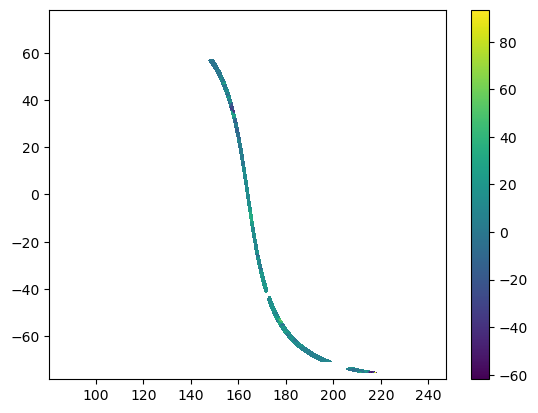

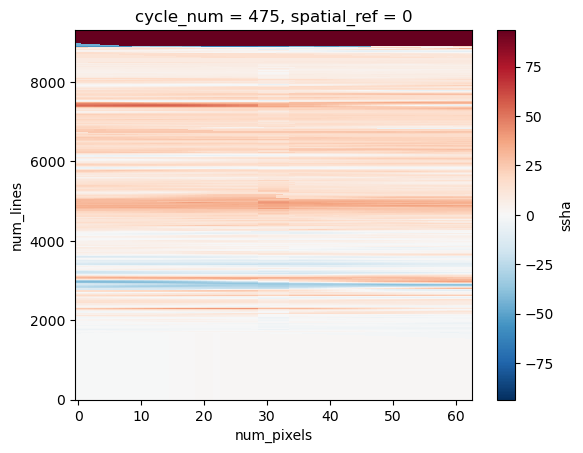

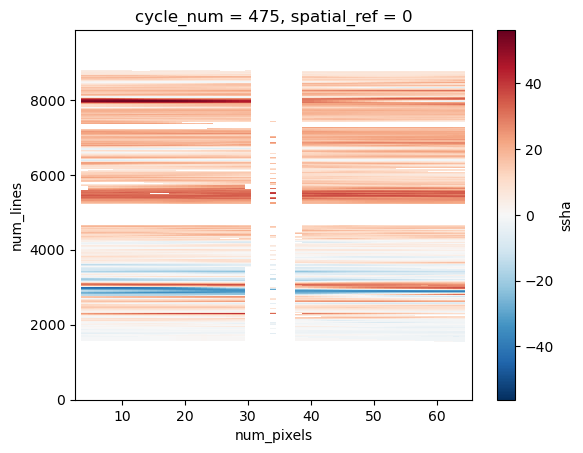

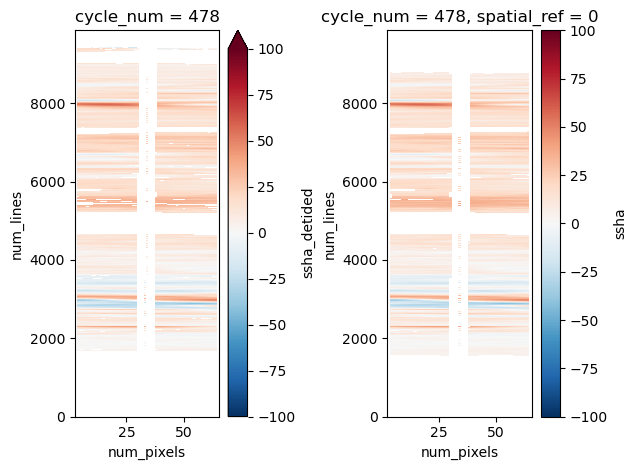

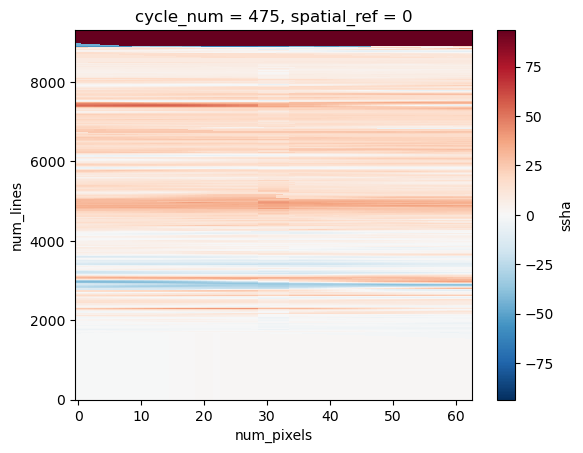

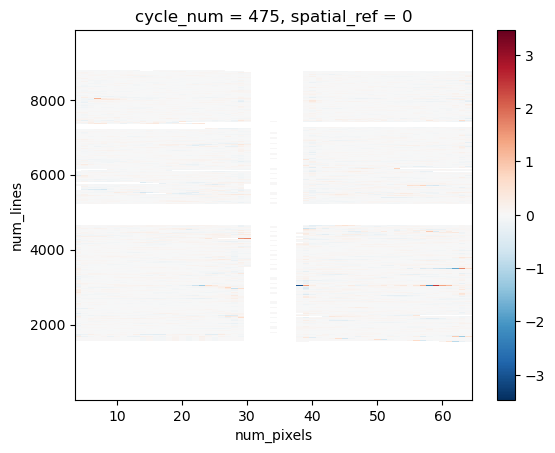

iiiiiiiiiiii
iiPass 004!!
!!!!!!!!!!!!


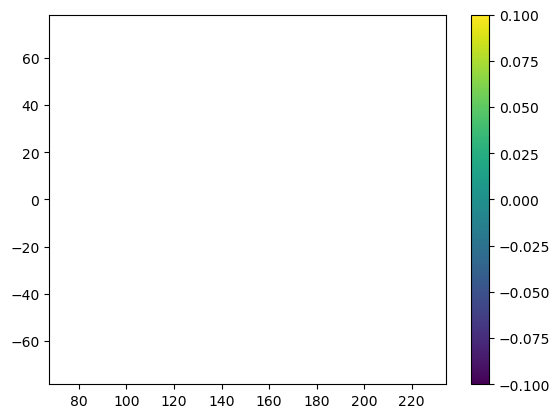

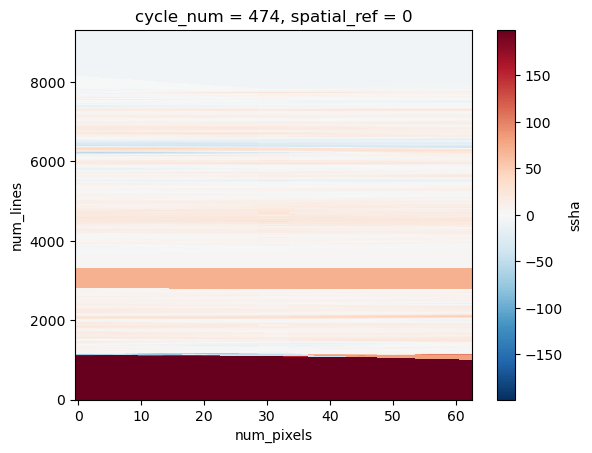

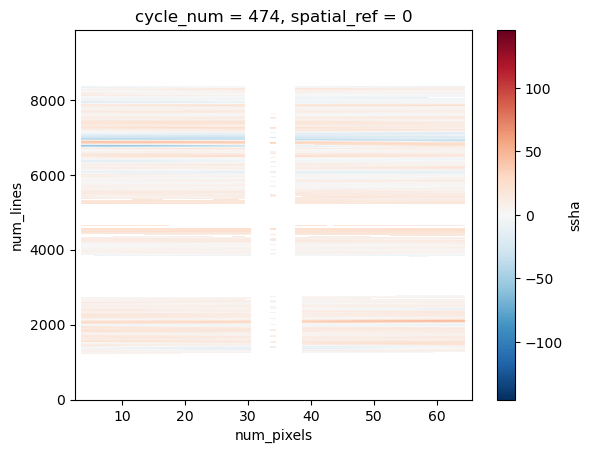

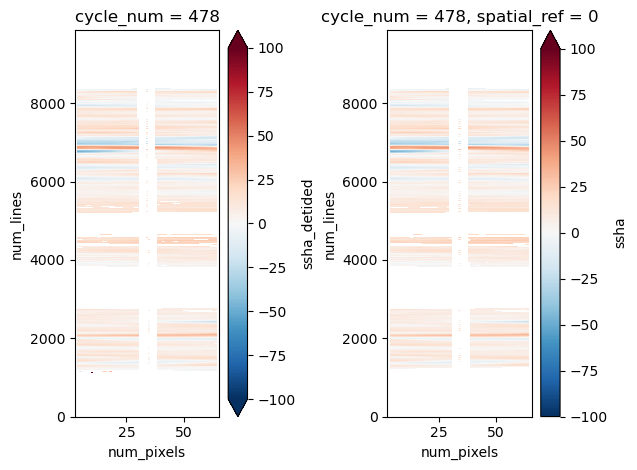

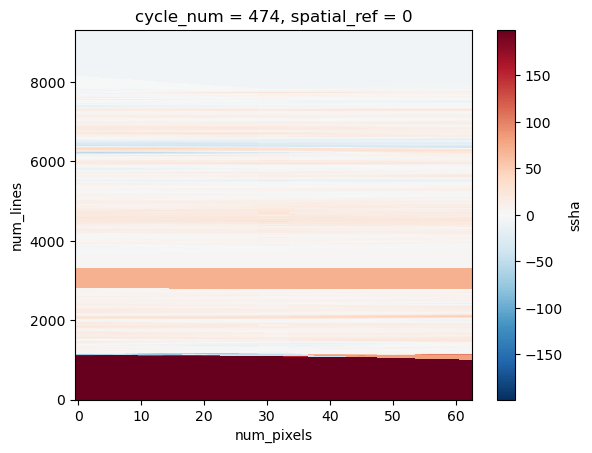

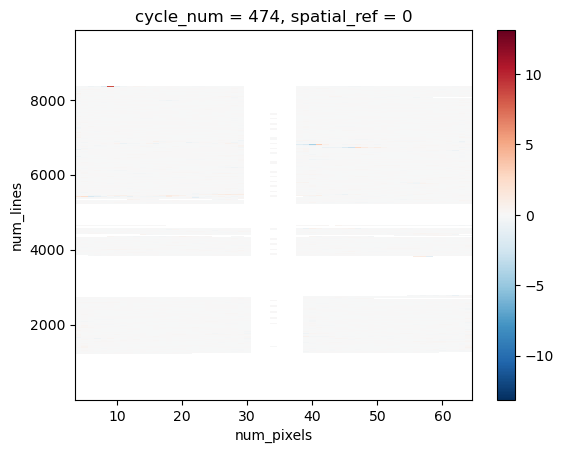

iiiiiiiiiiii
iiPass 019!!
!!!!!!!!!!!!


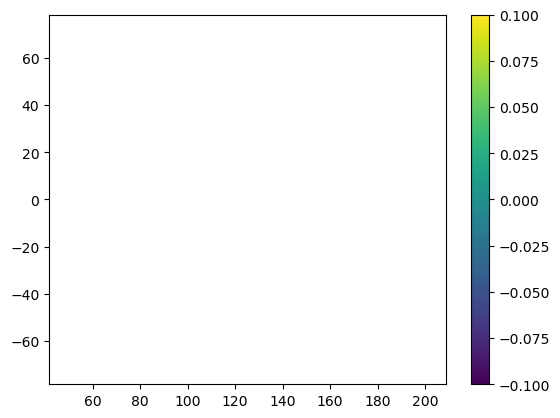

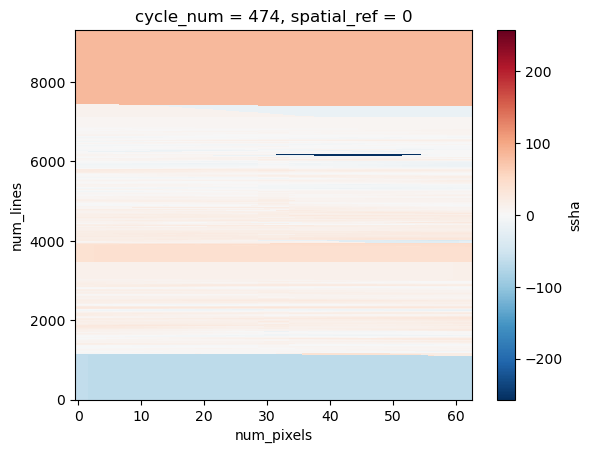

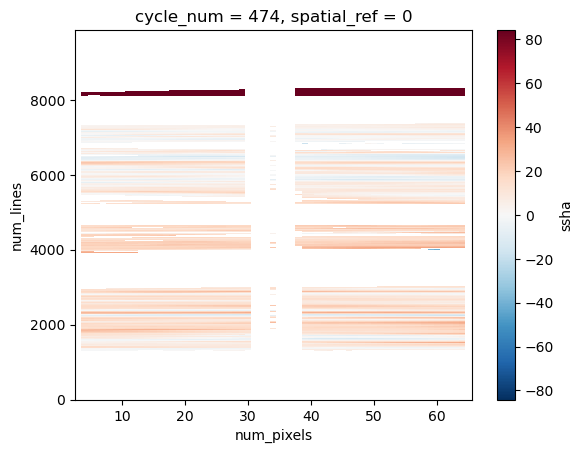

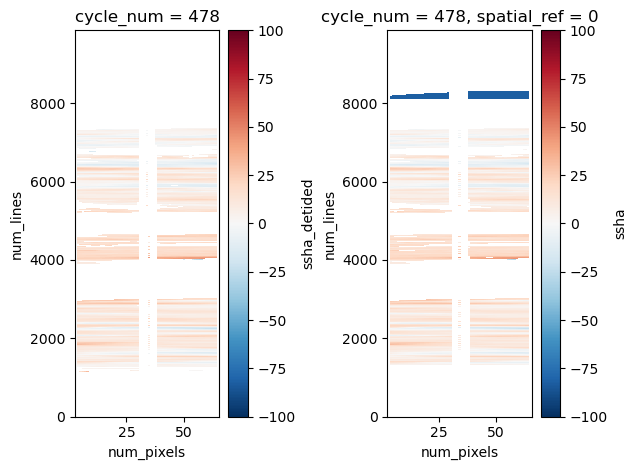

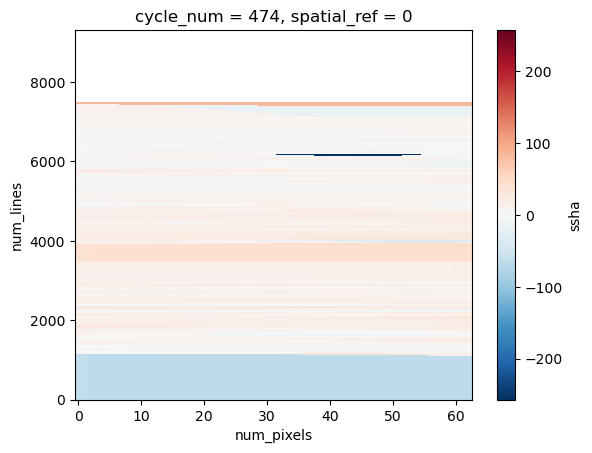

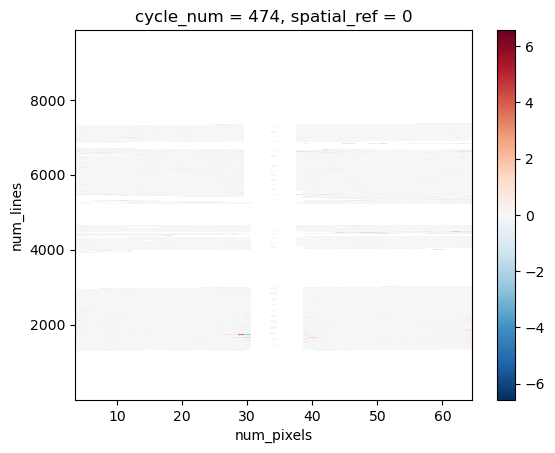

iiiiiiiiiiii
iiPass 021!!
!!!!!!!!!!!!


In [21]:
# for ipass in range(21,22):
for ipass in [4,19,21]:
    ds = xr.open_zarr(op.join(ddir,"SWOT_no_IT/HRET/CalVal_pass%03d_v2.0.1.zarr"
                              % ipass))
    ds.coords["num_lines"] = ("num_lines",range(len(ds.num_lines)))
    ds.coords["num_pixels"] = ("num_pixels",range(len(ds.num_pixels)))

    fig, ax = plt.subplots()
    im = ax.pcolor(ds.longitude, ds.latitude,
              ds.ssha_detided.isel(cycle_num=1), 
              rasterized=True
             )
    fig.colorbar(im)
    plt.show()

    inp = 3
    maskn = xr.DataArray(ds.latitude.where(ds.latitude>5.).to_masked_array().mask,
                         dims=ds.latitude.dims,
                         coords=ds.latitude.coords
                        )
    masks = xr.DataArray(ds.latitude.where(ds.latitude<-5.).to_masked_array().mask,
                         dims=ds.latitude.dims,
                         coords=ds.latitude.coords
                        )
    dsns = ds.where(~maskn,drop=True)
    dsns = xr.concat([dsns, ds.where(~masks,drop=True)
                     ], "num_lines"
                    ).sortby("num_lines")

    maskns = xr.DataArray(dsns.ssha_detided.to_masked_array().mask.mean(axis=0), 
                          dims=dsns.ssha_detided.isel(cycle_num=0).dims, 
                          coords=dsns.ssha_detided.isel(cycle_num=0).coords
                         )
    mm = xr.DataArray(maskns.where(maskns<.5
                                  ).to_masked_array().mask,
                      dims=dsns.ssha_detided.isel(cycle_num=0).dims, 
                      coords=dsns.ssha_detided.isel(cycle_num=0).coords
                     ).isel(num_pixels=slice(inp,-inp))

    r_ref = (~mm).sum() / np.prod(mm.shape)

    ic = 0
    for cc in dsns.cycle_num:
        
        ssha = dsns.ssha_detided.sel(cycle_num=cc
                                    ).isel(num_pixels=slice(inp,-inp))
        
        array = ssha.to_masked_array()
        mask = ~array.mask
        ratio = mask.sum() / np.prod(mask.shape)
        if ic == 0:
            R = xr.DataArray(np.array([ratio]), 
                             dims='cycle_num', 
                             coords={'cycle_num':np.array([cc.values,])}
                            )
        else:
            R = xr.concat([R, xr.DataArray(np.array([ratio]), 
                                   dims='cycle_num', 
                                   coords={'cycle_num':np.array([cc.values,])}
                                          )
                          ], 'cycle_num')
        if ratio > .7*r_ref:
            if ic == 0:
                H = ssha
            else:
                if "H" in locals():
                    H = xr.concat([H, ssha], 'cycle_num')
                else:
                    print("Creating H.")
                    H = ssha
            ic += 1
        # else:
            # ssha.plot(rasterized=True)
            # plt.show()
        del ssha, mask, array
    
    H.coords["cycle_num"] = ("cycle_num",
                             R.where(R>0.7*r_ref, drop=True).cycle_num.data
                            )

    dsH = H.to_dataset(name="ssha").swap_dims({'num_pixels':'x', 
                                               'num_lines':'y'}
                                             ).reset_coords(drop=True)
    dsH.coords["y"] = ("y",range(len(dsH.y)))
    dsH.coords["x"] = ("x",range(len(dsH.x)))
    if not dsH.rio.crs:
        dsH = dsH.rio.write_crs("EPSG:4326")
    if dsH.ssha.rio.nodata is None:
        dsH["ssha"] = dsH.ssha.rio.write_nodata(np.nan)
    _H_exterp = dsH.rio.interpolate_na().swap_dims({'x':'num_pixels', 
                                                    'y':'num_lines'}
                                                  ).ssha
    _H_exterp.isel(cycle_num=0).plot(rasterized=True)
    plt.show()

    del H
    dsH.close()

    H_exterp = _H_exterp.where(mm!=1)
    H_exterp.isel(cycle_num=0).plot(rasterized=True)

    fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2)
    fig.set_tight_layout(True)
    dsns.ssha_detided.sel(cycle_num=478
                         ).isel(num_pixels=slice(inp,-inp)
                               ).plot(ax=ax1, rasterized=True, vmax=1e2)
    H_exterp.sel(cycle_num=478).plot(ax=ax2, rasterized=True, vmax=1e2)
    plt.show()

    wet_mask = xr.DataArray(mm.where(mm!=0).to_masked_array().mask.astype(np.float64),
                            dims=mm.dims, coords=mm.coords
                           ).reset_coords(drop=True)
    
    regular_filter = gcm_filters.Filter(
        filter_scale=fscale,
        dx_min=1,
        filter_shape=gcm_filters.FilterShape.GAUSSIAN,
        grid_type=gcm_filters.GridType.REGULAR_WITH_LAND,
        grid_vars={'wet_mask': wet_mask,
        }
    )
    
    _sshm = regular_filter.apply(_H_exterp.chunk({'num_lines':-1,'num_pixels':-1}), 
                             dims=['num_lines','num_pixels']
                            ).reset_coords(drop=True).where(mm!=1).chunk({"cycle_num":1,
                                                             "num_lines":-1,"num_pixels":-1}
                                                           ).isel(num_pixels=slice(1,-1),
                                                                  num_lines=slice(1,-1)
                                                                 )
    if ipass == 21:
        _sshm[dict(num_lines=range(7499,len(_sshm.num_lines)))] = np.nan
        _H_exterp[dict(num_lines=range(7499,len(_H_exterp.num_lines)))] = np.nan
        
    _H_exterp.isel(cycle_num=0).plot()
    plt.show()
    (_H_exterp.isel(num_pixels=slice(1,-1),num_lines=slice(1,-1))
     - _sshm).isel(cycle_num=0).plot()
    plt.show()
    
    dsave = _sshm.to_dataset(name="ssha"
                            ).to_zarr(op.join(ddir,
                          'CalVal/Pass%03d/ssha_rawgrid_HRET_%02dpoints.zarr' 
                          % (ipass,int(fscale))
                                             ), mode='w'
                                     )
    print("iiiiiiiiiiii")
    print("iiPass %03d!!" % ipass)
    print("!!!!!!!!!!!!")

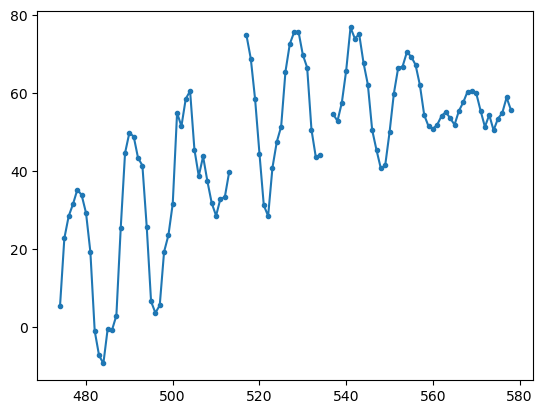

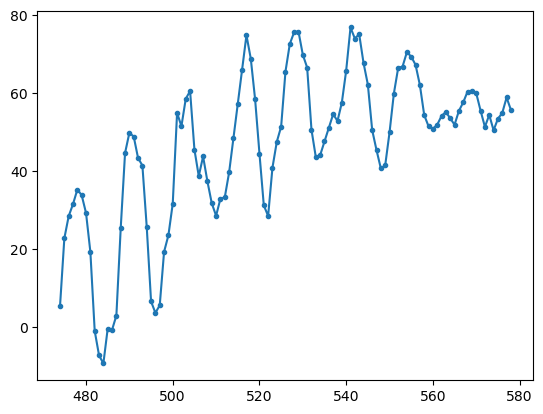

iiiiiiiiiiiii
iiPass 004!!
!!!!!!!!!!!!!


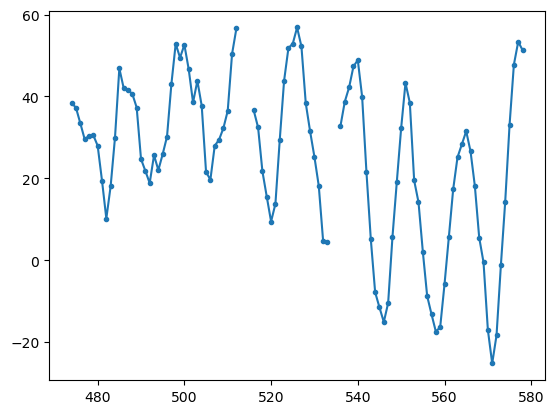

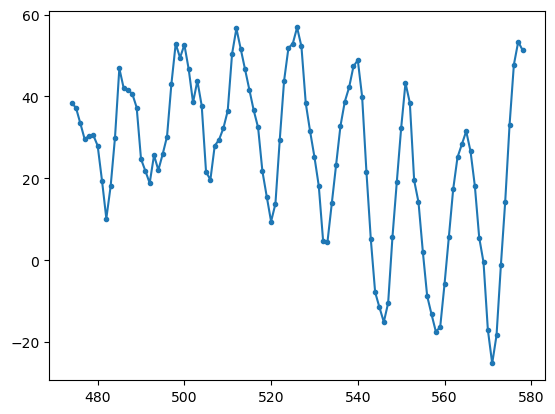

iiiiiiiiiiiii
iiPass 019!!
!!!!!!!!!!!!!


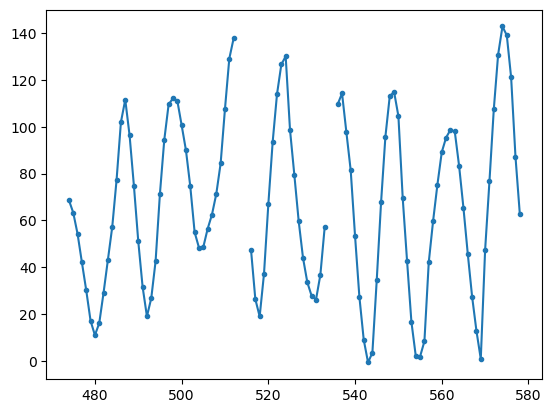

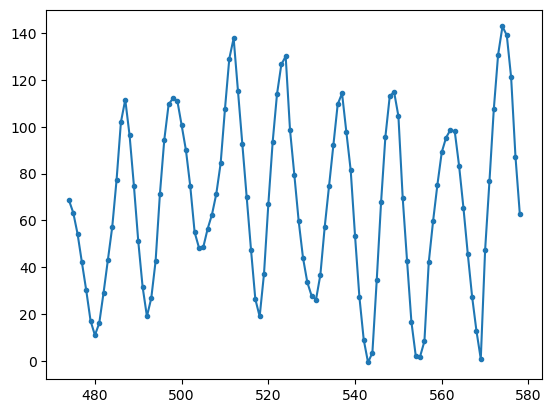

iiiiiiiiiiiii
iiPass 021!!
!!!!!!!!!!!!!


In [13]:
# for ipass in range(21,22):
for ipass in [4,19,21]:
    ds = xr.open_zarr(op.join(ddir,
                              "SWOT_no_IT/HYCOM/CalVal_pass%03d_v2.0.1.zarr"
                              % ipass)
                     )
    dsh = xr.open_dataset(op.join(ddir,
                              "tssh_swot1day/030_archs.tssh_swot1day_%03d.nc"
                              % ipass)
                         ).isel(pass_num=0)

    dsH = xr.open_dataset(op.join(ddir,
                "HYCOM-tidal-correction/no_swot_mask/hycom_ssh_pass%02d_swot1day_no_swot_mask_v2.0.1.nc"
                                  % ipass)
                         ).isel(num_pass=0)
    ssh = xr.concat([dsh.tssh.isel(cycle_num=slice(None,-9)),
                     dsh.tssh.isel(cycle_num=slice(-9,None))*1e2/9.81
                    ], "cycle_num")
    ssh = ssh - dsH.hycom_total.fillna(0.).data
    ssh.coords["latitude"] = (("num_lines","num_pixels"), ds.latitude.data)
    ssh.coords["longitude"] = (("num_lines","num_pixels"), ds.longitude.data)

    # fig, ax = plt.subplots()
    # im = ax.pcolor(dsh.longitude, dsh.latitude,
    #                dsh.total_ssh.isel(cycle_num=1), 
    #                rasterized=True
    #               )
    # fig.colorbar(im)
    # plt.show()

    inp = 3
    if ipass == 21:
        reg = "PS"
        maskn = xr.DataArray(ssh.latitude.where(ssh.latitude<40.).to_masked_array().mask,
                             dims=ssh.latitude.dims,
                             coords=ssh.latitude.coords
                            )
        sshns = ssh.where(~maskn,drop=True)
        masks = xr.DataArray(sshns.latitude.where(sshns.latitude>10.).to_masked_array().mask,
                             dims=sshns.latitude.dims,
                             coords=sshns.latitude.coords
                            )
        
        sshns = sshns.where(~masks,drop=True)
    elif ipass == 4 or ipass == 19:
        reg = "Kx"
        maskn = xr.DataArray(ssh.latitude.where(ssh.latitude<50.).to_masked_array().mask,
                             dims=ssh.latitude.dims,
                             coords=ssh.latitude.coords
                            )
        sshns = ssh.where(~maskn,drop=True)
        masks = xr.DataArray(sshns.latitude.where(sshns.latitude>20.).to_masked_array().mask,
                             dims=sshns.latitude.dims,
                             coords=sshns.latitude.coords
                            )
        sshns = sshns.where(~masks,drop=True)
    else:
        maskn = xr.DataArray(ssh.latitude.where(ssh.latitude>5.).to_masked_array().mask,
                             dims=ssh.latitude.dims,
                             coords=ssh.latitude.coords
                            )
        masks = xr.DataArray(ssh.latitude.where(ssh.latitude<-5.).to_masked_array().mask,
                             dims=ssh.latitude.dims,
                             coords=ssh.latitude.coords
                            )
        sshns = ssh.where(~maskn,drop=True)
        sshns = xr.concat([sshns, ssh.where(~masks,drop=True)
                         ], "num_lines"
                        ).sortby("num_lines").dropna("num_lines",how="all")
    plt.plot(sshns.cycle_num, sshns.mean(["num_lines","num_pixels"]),
             ".-")
    # (dsh.tssh
    #  - _sshm).isel(cycle_num=10).plot()
    plt.show()
    sshns = sshns.interpolate_na("cycle_num", method="slinear")
    # dsHns = dsH.where(~maskn,drop=True)
    # dsHns = xr.concat([dsHns, dsH.where(~masks,drop=True)
    #                  ], "num_lines"
    #                 ).sortby("num_lines")

    # maskns = xr.DataArray(dsHns.hycom_total.to_masked_array().mask.mean(axis=0), 
    #                       dims=dsHns.hycom_total.isel(num_cycle=0).dims, 
    #                       coords=dsHns.hycom_total.isel(num_cycle=0).coords
    #                      )
    # mm = xr.DataArray(maskns.where(maskns<.5
    #                               ).to_masked_array().mask,
    #                   dims=dsHns.hycom_total.isel(num_cycle=0).dims, 
    #                   coords=dsHns.hycom_total.isel(num_cycle=0).coords
    #                  ).isel(num_pixels=slice(inp,-inp))
    # mm.plot(rasterized=True)
    # plt.show()

    # _H_exterp = sshns.where(mm!=1.,drop=True)

    # del H
    # dsH.close()

    plt.plot(sshns.cycle_num, sshns.mean(["num_lines","num_pixels"]),
             ".-")
    # sshns.isel(cycle_num=0).plot()
    plt.show()
    # (dsh.tssh
    #  - _sshm).isel(cycle_num=10).plot()
    # plt.show()
    
    dsave = sshns.to_dataset(name="ssha")
    if ipass == 4 or ipass == 19 or ipass == 21:
        dsave.to_zarr(op.join(ddir,
                              'tssh_swot1day/Pass%03d/'% (ipass)
                             ) + reg
                               +'/ssh-detided_rawgrid.zarr', 
                      mode='w'
                     )
    else:
        dsave.to_zarr(op.join(ddir,
                              'tssh_swot1day/Pass%03d/ssh-detided_rawgrid.zarr' 
                              % (ipass)
                                                 ), mode='w'
                                         )
    del sshns
    print("iiiiiiiiiiiii")
    print("iiPass %03d!!" % ipass)
    print("!!!!!!!!!!!!!")

<xarray.DataArray 'tssh' (cycle_num: 105, num_lines: 1720, num_pixels: 69)> Size: 100MB
dask.array<where, shape=(105, 1720, 69), dtype=float64, chunksize=(96, 970, 69), chunktype=numpy.ndarray>
Coordinates:
  * cycle_num   (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
  * num_lines   (num_lines) int64 14kB 2097 2098 2099 2100 ... 3814 3815 3816
  * num_pixels  (num_pixels) int64 552B 0 1 2 3 4 5 6 7 ... 62 63 64 65 66 67 68
    pass_num    int64 8B 4
    latitude    (num_lines, num_pixels) float64 949kB dask.array<chunksize=(1720, 69), meta=np.ndarray>
    longitude   (num_lines, num_pixels) float64 949kB dask.array<chunksize=(1720, 69), meta=np.ndarray>


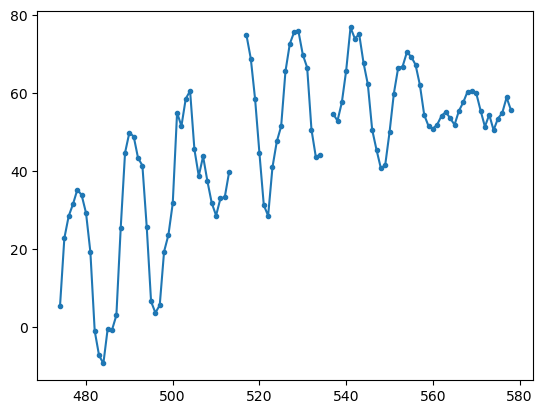

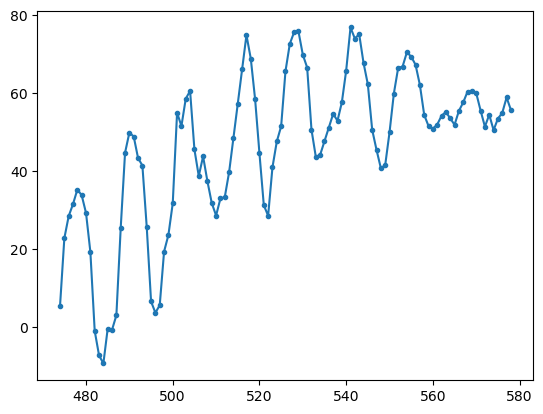

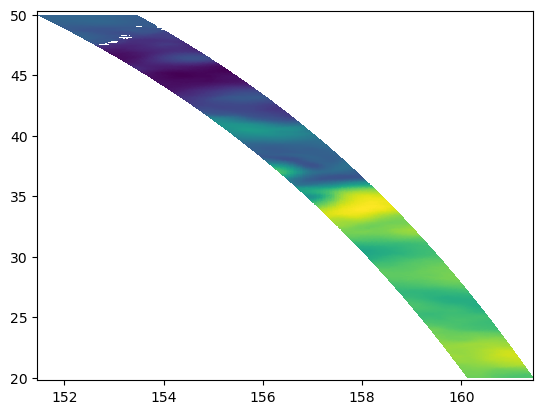

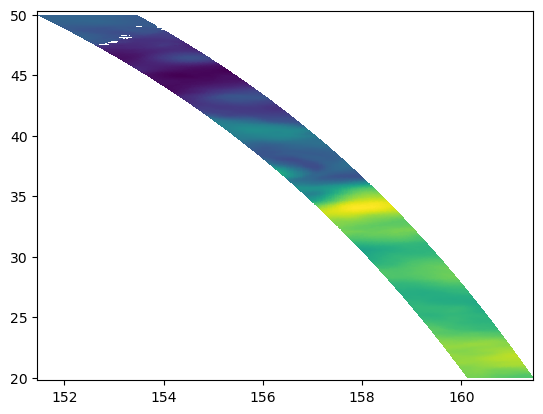

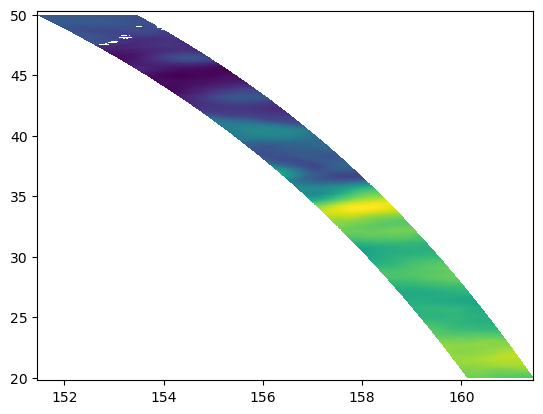

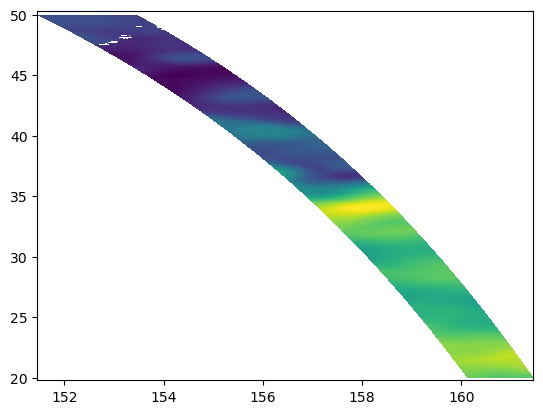

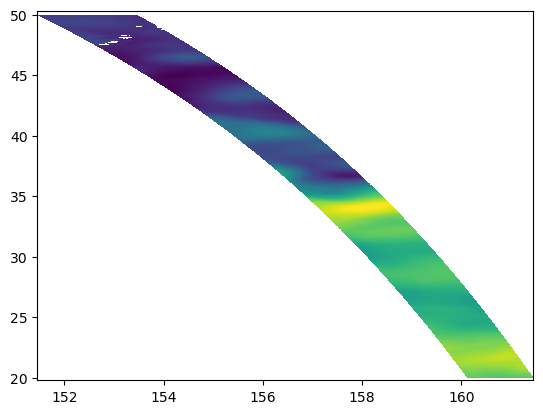

iiiiiiiiiiiii
iiPass 004!!
!!!!!!!!!!!!!
<xarray.DataArray 'tssh' (cycle_num: 105, num_lines: 1720, num_pixels: 69)> Size: 100MB
dask.array<where, shape=(105, 1720, 69), dtype=float64, chunksize=(96, 970, 69), chunktype=numpy.ndarray>
Coordinates:
  * cycle_num   (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
  * num_lines   (num_lines) int64 14kB 6045 6046 6047 6048 ... 7762 7763 7764
  * num_pixels  (num_pixels) int64 552B 0 1 2 3 4 5 6 7 ... 62 63 64 65 66 67 68
    pass_num    int64 8B 19
    latitude    (num_lines, num_pixels) float64 949kB dask.array<chunksize=(1720, 69), meta=np.ndarray>
    longitude   (num_lines, num_pixels) float64 949kB dask.array<chunksize=(1720, 69), meta=np.ndarray>


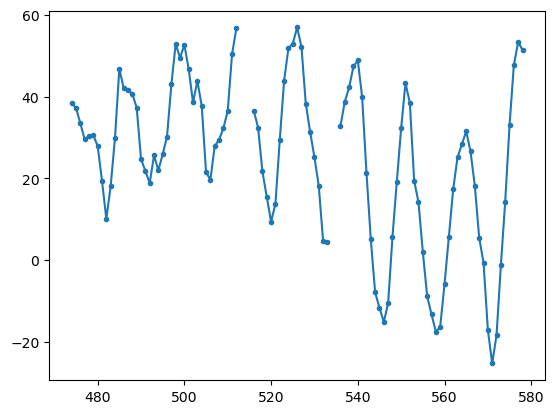

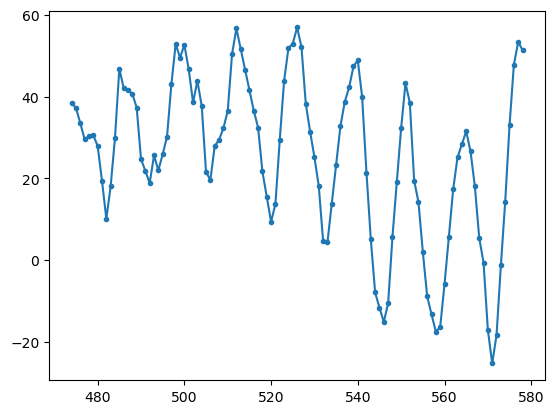

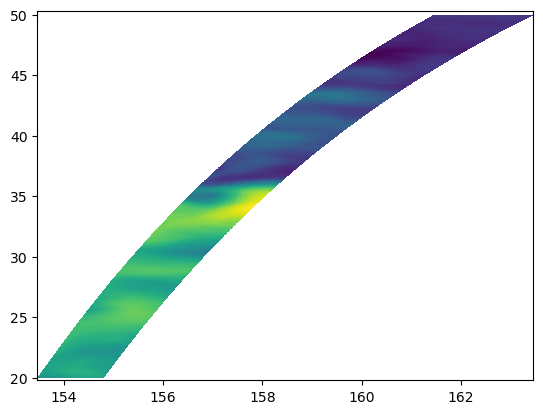

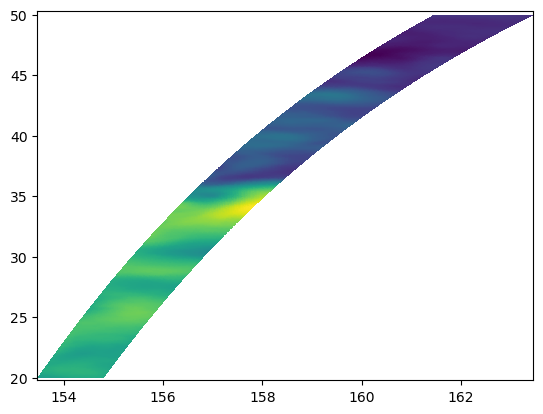

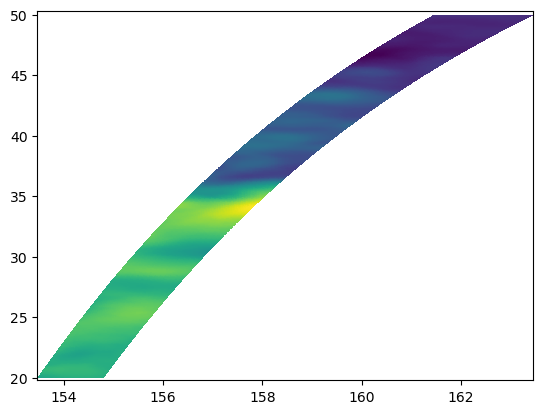

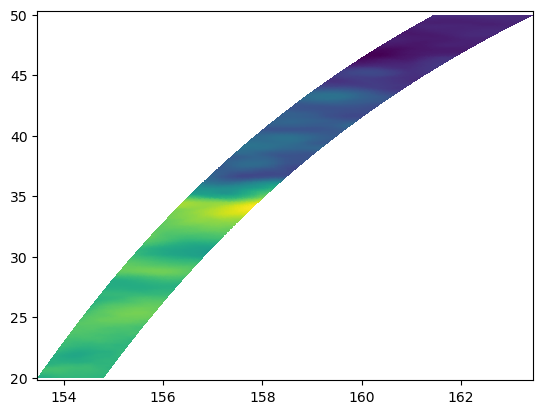

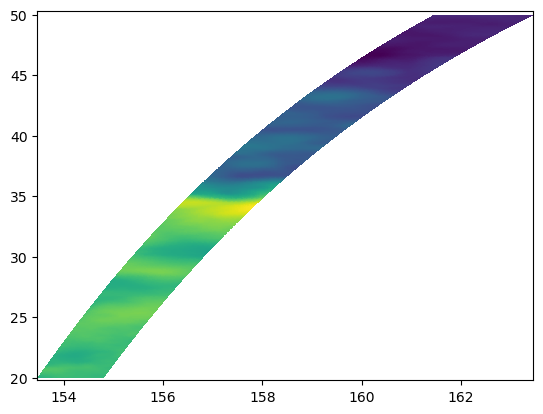

iiiiiiiiiiiii
iiPass 019!!
!!!!!!!!!!!!!
<xarray.DataArray 'tssh' (cycle_num: 105, num_lines: 1703, num_pixels: 69)> Size: 99MB
dask.array<where, shape=(105, 1703, 69), dtype=float64, chunksize=(96, 898, 69), chunktype=numpy.ndarray>
Coordinates:
  * cycle_num   (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
  * num_lines   (num_lines) int64 14kB 5485 5486 5487 5488 ... 7185 7186 7187
  * num_pixels  (num_pixels) int64 552B 0 1 2 3 4 5 6 7 ... 62 63 64 65 66 67 68
    pass_num    int64 8B 21
    latitude    (num_lines, num_pixels) float64 940kB dask.array<chunksize=(1703, 69), meta=np.ndarray>
    longitude   (num_lines, num_pixels) float64 940kB dask.array<chunksize=(1703, 69), meta=np.ndarray>


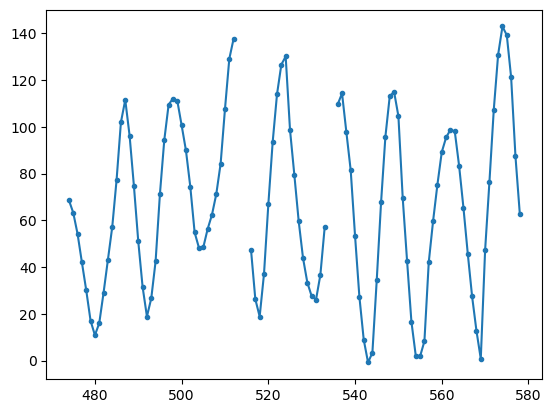

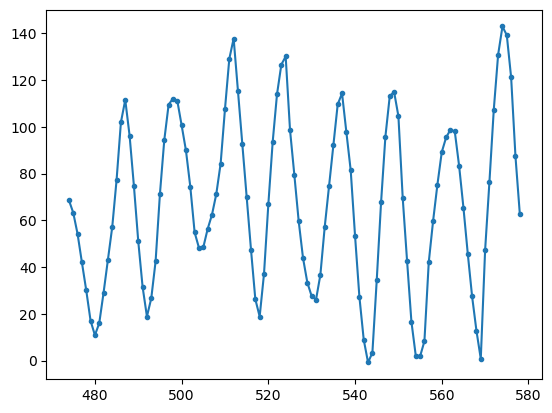

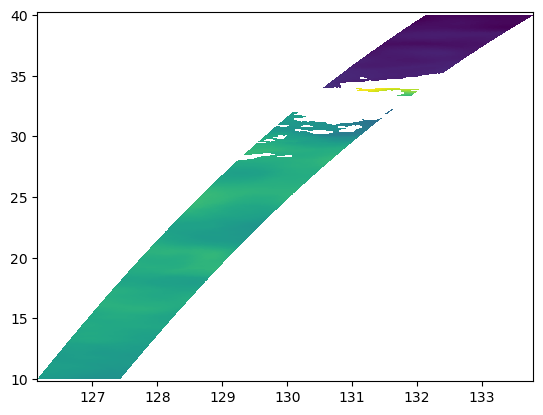

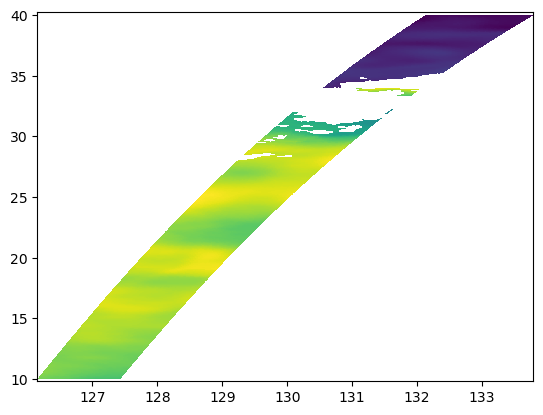

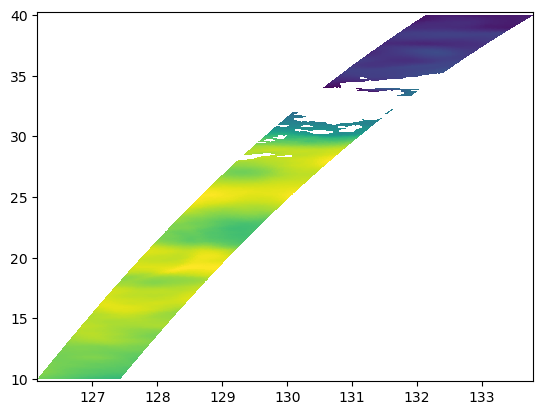

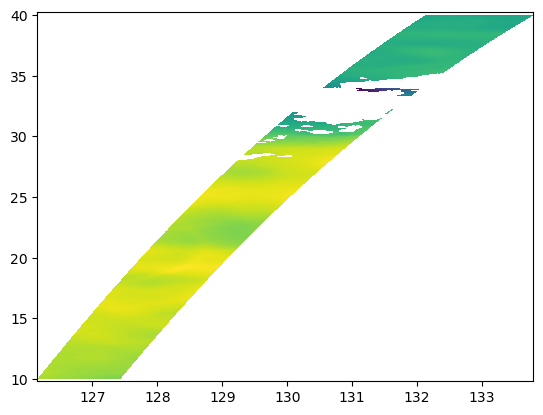

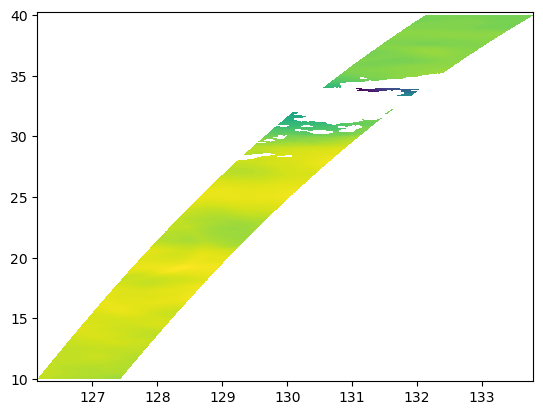

iiiiiiiiiiiii
iiPass 021!!
!!!!!!!!!!!!!


In [12]:
# for ipass in range(21,22):
for ipass in [4,19,21]:
    ds = xr.open_zarr(op.join(ddir,
                              "SWOT_no_IT/HYCOM/CalVal_pass%03d_v2.0.1.zarr"
                              % ipass)
                     )
    ds.coords["num_lines"] = ("num_lines",range(len(ds.num_lines)))
    ds.coords["num_pixels"] = ("num_pixels",range(len(ds.num_pixels)))
    dsh = xr.open_dataset(op.join(ddir,
                              "tssh_swot1day/030_archs.tssh_swot1day_%03d.nc"
                              % ipass)
                         ).isel(pass_num=0).chunk({"num_lines":1000})
    dsh.coords["latitude"] = (("num_lines","num_pixels"),ds.latitude.data)
    dsh.coords["longitude"] = (("num_lines","num_pixels"),ds.longitude.data)

    # dsH = xr.open_dataset(op.join(ddir,
    #                               "HYCOM-tidal-correction/hycom_ssh_pass%02d_swot1day_v2.0.1.nc"
    #                               % ipass)
    #                      ).isel(num_pass=0)
    # if ipass == 4:
    #     ssh = dsh.tssh.sel(cycle_num=slice(None,514))
    #     ssh = xr.concat([ssh, 
    #                      dsh.tssh.sel(cycle_num=slice(517,535))
    #                     ], "cycle_num")
    #     ssh = xr.concat([ssh, 
    #                      dsh.tssh.sel(cycle_num=slice(537,None))
    #                     ], "cycle_num")
    # else:
    #     ssh = dsh.tssh.sel(cycle_num=slice(None,513))
    #     ssh = xr.concat([ssh, 
    #                      dsh.tssh.sel(cycle_num=slice(516,534))
    #                     ], "cycle_num")
    #     ssh = xr.concat([ssh, 
    #                      dsh.tssh.sel(cycle_num=slice(536,None))
    #                     ], "cycle_num")
    ssh = xr.concat([dsh.tssh.isel(cycle_num=slice(None,-9)),
                     dsh.tssh.isel(cycle_num=slice(-9,None))*1e2/9.81
                    ], "cycle_num")

    # fig, ax = plt.subplots()
    # im = ax.pcolor(dsh.longitude, dsh.latitude,
    #                dsh.total_ssh.isel(cycle_num=1), 
    #                rasterized=True
    #               )
    # fig.colorbar(im)
    # plt.show()

    inp = 3
    if ipass == 21:
        reg = "PS"
        maskn = xr.DataArray(ssh.latitude.where(ssh.latitude<40.).to_masked_array().mask,
                             dims=ssh.latitude.dims,
                             coords=ssh.latitude.coords
                            )
        sshns = ssh.where(~maskn,drop=True)
        masks = xr.DataArray(sshns.latitude.where(sshns.latitude>10.).to_masked_array().mask,
                             dims=sshns.latitude.dims,
                             coords=sshns.latitude.coords
                            )
        
        sshns = sshns.where(~masks,drop=True)
    elif ipass == 4 or ipass == 19:
        reg = "Kx"
        maskn = xr.DataArray(ssh.latitude.where(ssh.latitude<50.).to_masked_array().mask,
                             dims=ssh.latitude.dims,
                             coords=ssh.latitude.coords
                            )
        sshns = ssh.where(~maskn,drop=True)
        masks = xr.DataArray(sshns.latitude.where(sshns.latitude>20.).to_masked_array().mask,
                             dims=sshns.latitude.dims,
                             coords=sshns.latitude.coords
                            )
        sshns = sshns.where(~masks,drop=True)
    else:
        maskn = xr.DataArray(ssh.latitude.where(ssh.latitude>5.).to_masked_array().mask,
                             dims=ssh.latitude.dims,
                             coords=ssh.latitude.coords
                            )
        masks = xr.DataArray(ssh.latitude.where(ssh.latitude<-5.).to_masked_array().mask,
                             dims=ssh.latitude.dims,
                             coords=ssh.latitude.coords
                            )
        sshns = ssh.where(~maskn,drop=True)
        sshns = xr.concat([sshns, ssh.where(~masks,drop=True)
                         ], "num_lines"
                        ).sortby("num_lines").dropna("num_lines",how="all")
    print(sshns)
    plt.plot(sshns.cycle_num, sshns.mean(["num_lines","num_pixels"]),
             ".-")
    # (dsh.tssh
    #  - _sshm).isel(cycle_num=10).plot()
    plt.show()
    sshns = sshns.chunk({"cycle_num":-1}).interpolate_na("cycle_num", method="slinear")
    # maskh = sshns.mean("cycle_num").to_masked_array().mask
    # sshns = sshns.fillna(0.).interp(cycle_num=np.arange(ds.cycle_num[0].values,
    #                                          ds.cycle_num[-1].values+1), 
    #                      method="makima"
    #                                ).where(~maskh)
    # sshns = sshns.fillna(0.).interp(cycle_num=np.arange(ds.cycle_num[0].values,
    #                                          ds.cycle_num[-1].values+1), 
    #                      num_pixels=range(len(ds.num_pixels)),
    #                      method="slinear").where(~maskh)
    # dsns = ds.where(~maskn,drop=True)
    # dsns = xr.concat([dsns, ds.where(~masks,drop=True)
    #                  ], "num_lines"
    #                 ).sortby("num_lines")

    # maskns = xr.DataArray(dsns.ssha_detided.to_masked_array().mask.mean(axis=0), 
    #                       dims=dsns.ssha_detided.isel(cycle_num=0).dims, 
    #                       coords=dsns.ssha_detided.isel(cycle_num=0).coords
    #                      )
    # mm = xr.DataArray(maskns.where(maskns<.5
    #                               ).to_masked_array().mask,
    #                   dims=dsns.ssha_detided.isel(cycle_num=0).dims, 
    #                   coords=dsns.ssha_detided.isel(cycle_num=0).coords
    #                  ).isel(num_pixels=slice(inp,-inp))
    # mm.plot(rasterized=True)
    # plt.show()

    # _H_exterp = sshns.where(mm.drop("cycle_num")!=1.,drop=True)
    
    plt.plot(sshns.cycle_num, sshns.mean(["num_lines","num_pixels"]),
             ".-")
    # (dsh.tssh
    #  - _sshm).isel(cycle_num=10).plot()
    plt.show()

    for cc in range(512,517):
        plt.pcolormesh(sshns.longitude, sshns.latitude,
                       sshns.sel(cycle_num=cc),
                       rasterized=True)
        plt.show()
    
    dsave = sshns.chunk({"cycle_num":1,"num_lines":-1}
                       ).to_dataset(name="ssha")
    if ipass == 4 or ipass == 19 or ipass ==21:
        dsave.to_zarr(op.join(ddir,
                              'tssh_swot1day/Pass%03d/' % (ipass)
                             ) + reg +'/ssh-total_rawgrid.zarr', 
                      mode='w'
                     )
    else:
        dsave.to_zarr(op.join(ddir,
                              'tssh_swot1day/Pass%03d/ssh-total_rawgrid.zarr' 
                              % (ipass)
                                                 ), mode='w'
                                         )
    del sshns
    print("iiiiiiiiiiiii")
    print("iiPass %03d!!" % ipass)
    print("!!!!!!!!!!!!!")

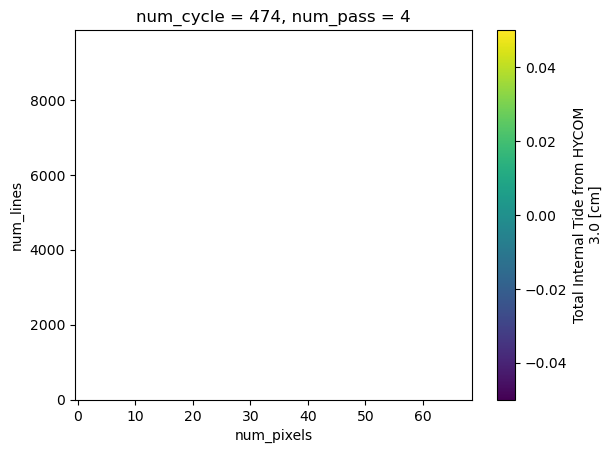

In [15]:
dsH.hycom_total.isel(num_cycle=0).plot(rasterized=True)

In [18]:
xr.open_zarr(op.join(ddir,
                     'tssh_swot1day/Pass%03d/ssh-detided_rawgrid.zarr' 
                     % (4))
            )

<xarray.Dataset> Size: 312MB
Dimensions:     (cycle_num: 105, num_lines: 6621, num_pixels: 55)
Coordinates:
  * cycle_num   (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
  * num_lines   (num_lines) int64 53kB 1545 1548 1549 1550 ... 8795 8796 8797
  * num_pixels  (num_pixels) int64 440B 4 5 6 7 8 9 10 ... 58 59 60 61 62 63 64
    latitude    (num_lines, num_pixels) float64 3MB dask.array<chunksize=(4656, 55), meta=np.ndarray>
    longitude   (num_lines, num_pixels) float64 3MB dask.array<chunksize=(4656, 55), meta=np.ndarray>
    num_cycle   int64 8B ...
    num_pass    int64 8B ...
    pass_num    int64 8B ...
Data variables:
    ssha        (cycle_num, num_lines, num_pixels) float64 306MB dask.array<chunksize=(14, 828, 14), meta=np.ndarray>

In [5]:
dst = xr.open_dataset(op.join(ddir,
                          'tssh_swot1day/Pass%03d/ssh_rawgrid.zarr' 
                          % (4)
                         )
                     )
# dst.coords["num_lines"] = ("num_lines",range(len(dst.num_lines)))
# dst.coords["num_pixels"] = ("num_pixels",range(len(dst.num_pixels)))
dst

<xarray.Dataset> Size: 466MB
Dimensions:     (cycle_num: 105, num_lines: 7886, num_pixels: 69)
Coordinates:
  * cycle_num   (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
  * num_lines   (num_lines) int64 63kB 0 1 2 3 4 5 ... 9476 9477 9478 9479 9480
  * num_pixels  (num_pixels) int64 552B 0 1 2 3 4 5 6 7 ... 62 63 64 65 66 67 68
    latitude    (num_lines, num_pixels) float64 4MB ...
    longitude   (num_lines, num_pixels) float64 4MB ...
    pass_num    int64 8B ...
Data variables:
    ssha        (cycle_num, num_lines, num_pixels) float64 457MB ...

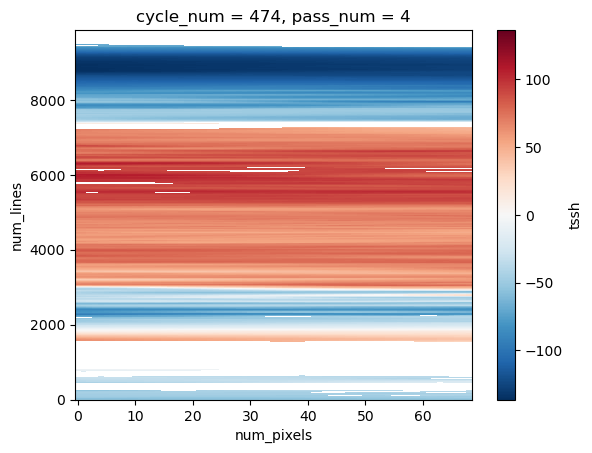

In [10]:
dst.tssh.isel(cycle_num=0).plot(rasterized=True)

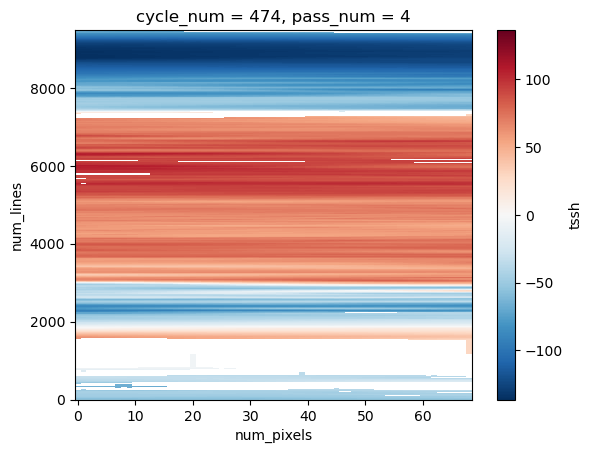

In [18]:
dst.tssh.isel(cycle_num=0).dropna("num_lines",how="all").plot(rasterized=True)

In [6]:
ds = xr.open_zarr(op.join(ddir,
                              'tssh_swot1day/Pass%03d/' % (21)
                             ) + "PS" +'/ssh_rawgrid.zarr'
                 )
ds

<xarray.Dataset> Size: 101MB
Dimensions:     (cycle_num: 105, num_lines: 1703, num_pixels: 69)
Coordinates:
  * cycle_num   (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
  * num_lines   (num_lines) int64 14kB 5485 5486 5487 5488 ... 7185 7186 7187
  * num_pixels  (num_pixels) int64 552B 0 1 2 3 4 5 6 7 ... 62 63 64 65 66 67 68
    latitude    (num_lines, num_pixels) float64 940kB dask.array<chunksize=(1703, 69), meta=np.ndarray>
    longitude   (num_lines, num_pixels) float64 940kB dask.array<chunksize=(1703, 69), meta=np.ndarray>
    pass_num    int64 8B ...
Data variables:
    ssha        (cycle_num, num_lines, num_pixels) float64 99MB dask.array<chunksize=(1, 1703, 69), meta=np.ndarray>

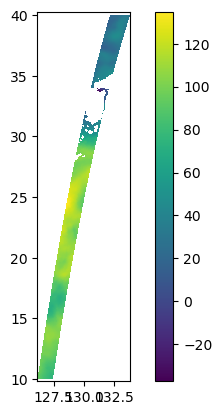

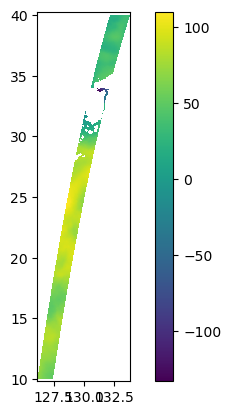

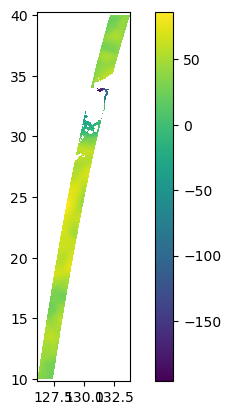

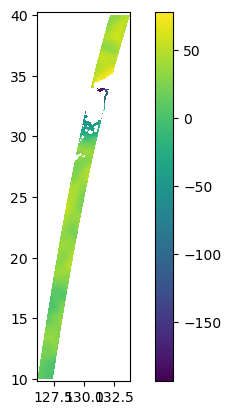

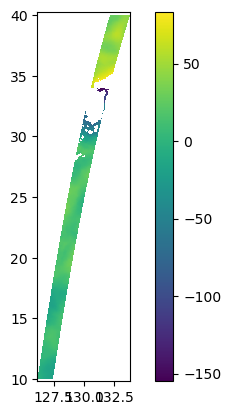

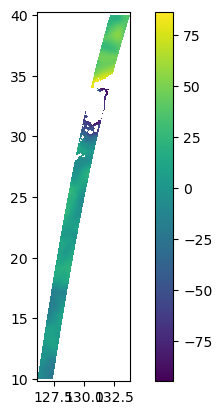

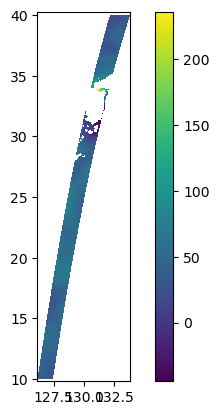

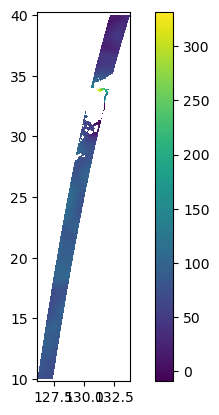

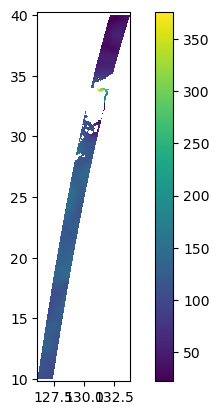

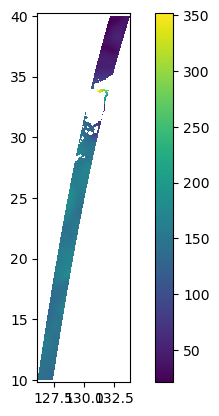

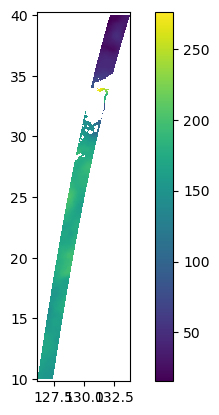

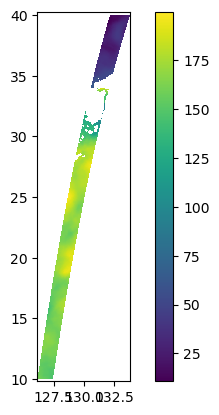

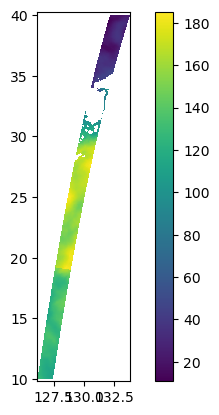

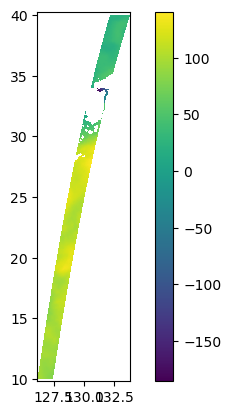

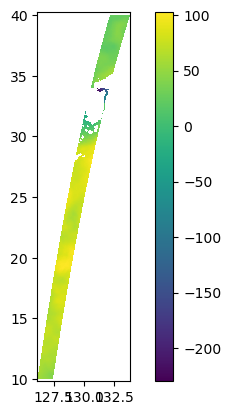

In [10]:
for cc in range(-15,0):
    fig, ax = plt.subplots()
    if cc < -10:
        im = ax.pcolormesh(ds.ssha.dropna("num_lines",how="all").longitude, 
                      ds.ssha.dropna("num_lines",how="all").latitude,
                      ds.ssha.dropna("num_lines",how="all").isel(cycle_num=cc),
                      rasterized=True)
        ax.set_aspect("equal")
        fig.colorbar(im)
    else:
        im = ax.pcolormesh(ds.ssha.dropna("num_lines",how="all").longitude, 
                      ds.ssha.dropna("num_lines",how="all").latitude,
                      ds.ssha.dropna("num_lines",how="all"
                                    ).isel(cycle_num=cc)*1e2/9.81,
                      rasterized=True)
        ax.set_aspect("equal")
        fig.colorbar(im)
    plt.show()